<a href="https://colab.research.google.com/github/bdashti/v/blob/main/0_8_9_unsupervised_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Phase 1: Initial Dataset Input
# Cell 1: Data Ingestion, QC & Noise Filter
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# ── LOAD ──────────────────────────────────────────────────────────────
df = pd.read_csv('/content/GGS3_logFC.csv')
n_raw = len(df)
print(f"Loaded {n_raw} sequences")

# ── BASIC QC ──────────────────────────────────────────────────────────
df.dropna(subset=['sequence', 'log2FC_end1', 'log2FC_end2',
                  'log2FC_mean', 'log2FC_std'], inplace=True)
print(f"After dropna: {len(df)} sequences ({n_raw - len(df)} dropped)")

# ── REPLICATE CORRELATION CHECK ───────────────────────────────────────
# Runs on raw df before any filtering — characterises experimental quality.
# r < 0.85 = poor replication; flag in thesis methods if so.
r_rep, p_rep = pearsonr(df['log2FC_end1'], df['log2FC_end2'])
print(f"Replicate correlation (raw): Pearson r = {r_rep:.4f} (p = {p_rep:.2e})")
if r_rep < 0.85:
    print("    WARNING: Replicate correlation below 0.85 — flag in thesis.")
else:
    print("   Replicate correlation acceptable.")

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
# Discard sequences where end1 and end2 disagree by more than 1.0 LFC.
# With only two replicates, log2FC_std is just |end1-end2|/√2 — not a
# real distributional estimate. The raw delta is more honest.
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
# Global 95th-percentile std cutoff removes low-fitness extremes
# disproportionately — exactly the sequences you need most.
# Fix: apply the cutoff within 10 fitness deciles instead.
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask)
    .reset_index(drop=True)
)

# ── SANITY CHECK ──────────────────────────────────────────────────────
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"\nFinal clean dataset: {n_final} sequences "
      f"({n_final/n_raw*100:.1f}% of raw)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))

# ── CLEAN UP HELPER COLUMNS ───────────────────────────────────────────
df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True)

print("\n Cell 1 complete. df_clean is ready for feature extraction.")

Loaded 124339 sequences
After dropna: 124339 sequences (0 dropped)
Replicate correlation (raw): Pearson r = 0.8050 (p = 0.00e+00)
  ⚠️  WARNING: Replicate correlation below 0.85 — flag in thesis.
Discordance filter (>1.0 LFC): removed 35 sequences

Final clean dataset: 118084 sequences (95.0% of raw)
Low-fitness sequences preserved (bottom 5%): 5813/6217 (93.5%)

Fitness distribution after filtering:
count    118084.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.071
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

✅ Cell 1 complete. df_clean is ready for feature extraction.


/tmp/ipykernel_65508/1946899911.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(stratified_noise_mask)


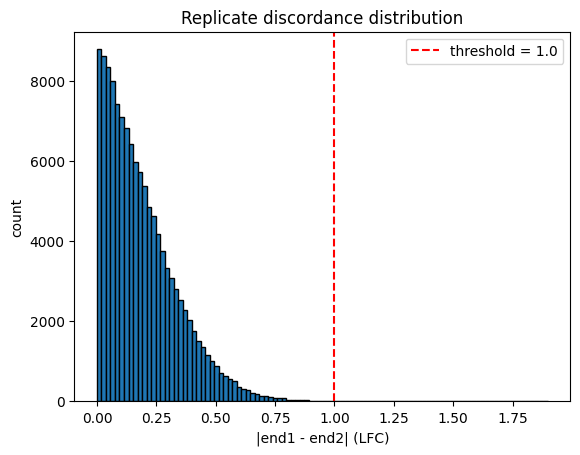

count    1.243390e+05
mean     1.876973e-01
std      1.499777e-01
min      3.532960e-07
25%      6.942972e-02
50%      1.536883e-01
75%      2.703018e-01
max      1.898648e+00
Name: replicate_delta, dtype: float64


In [2]:
#@title Noise Histogram
# Cell 2 - Noise histogram

import matplotlib.pyplot as plt
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
plt.hist(df['replicate_delta'], bins=100, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='threshold = 1.0')
plt.xlabel('|end1 - end2| (LFC)')
plt.ylabel('count')
plt.title('Replicate discordance distribution')
plt.legend()
plt.show()
print(df['replicate_delta'].describe())

In [3]:
#@title Noise Filter
# Cell 3: Noise Filter
# Depends on: df from Cell 0a

# ── REPLICATE DISCORDANCE FILTER ──────────────────────────────────────
df['replicate_delta'] = (df['log2FC_end1'] - df['log2FC_end2']).abs()
DISCORD_THRESHOLD = 1.0
df_clean = df[df['replicate_delta'] <= DISCORD_THRESHOLD].copy()
print(f"Discordance filter (>{DISCORD_THRESHOLD} LFC): removed "
      f"{len(df) - len(df_clean)} sequences ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# ── STRATIFIED NOISE FILTER ───────────────────────────────────────────
df_clean['lfc_bin'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)

def stratified_noise_mask(group, percentile=95):
    threshold = np.percentile(group['log2FC_std'], percentile)
    return group[group['log2FC_std'] <= threshold]

df_clean = (
    df_clean
    .groupby('lfc_bin', group_keys=False)
    .apply(stratified_noise_mask)
    .reset_index(drop=True)
)

df_clean.drop(columns=['replicate_delta', 'lfc_bin'], inplace=True)

# ── SANITY CHECK ──────────────────────────────────────────────────────
n_raw   = len(df)
n_final = len(df_clean)
low_before = (df['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()
low_after  = (df_clean['log2FC_mean'] < df['log2FC_mean'].quantile(0.05)).sum()

print(f"Retained: {n_final}/{n_raw} sequences ({n_final/n_raw*100:.1f}%)")
print(f"Low-fitness sequences preserved (bottom 5%): "
      f"{low_after}/{low_before} ({low_after/low_before*100:.1f}%)")
print(f"\nFitness distribution after filtering:")
print(df_clean['log2FC_mean'].describe().round(3))
print("\n df_clean ready.")

Discordance filter (>1.0 LFC): removed 35 sequences (0.0%)
Retained: 118084/124339 sequences (95.0%)
Low-fitness sequences preserved (bottom 5%): 5813/6217 (93.5%)

Fitness distribution after filtering:
count    118084.000
mean         -0.064
std           0.338
min          -4.181
25%          -0.258
50%          -0.071
75%           0.119
max           3.995
Name: log2FC_mean, dtype: float64

 df_clean ready.


/tmp/ipykernel_65508/1955429697.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(stratified_noise_mask)


In [4]:
#@title K-mer Tokenisation
# Cell 4: Positional K-mer Tokenisation
# Depends on: df_clean from Cell 0a

def get_positional_kmers(seq, k=4):
    """
    Splits a DNA sequence into 3 spatial regions (START, MID, END)
    and labels 4-mers accordingly.
    """
    n = len(seq)
    third = n // 3
    kmers = []
    for i in range(n - k + 1):
        kmer = seq[i:i+k]
        if i < third:
            prefix = "START_"
        elif i < 2 * third:
            prefix = "MID_"
        else:
            prefix = "END_"
        kmers.append(prefix + kmer)
    return " ".join(kmers)

def dummy_analyzer(doc):
    return doc.split()

print("Generating positional k-mers...")
df_clean['kmers'] = df_clean['sequence'].apply(get_positional_kmers)  # df → df_clean
print(f"Done. Example: {df_clean['kmers'].iloc[0][:80]}...")

Generating positional k-mers...
 Done. Example: START_AAGC START_AGCA START_GCAA START_CAAA START_AAAA START_AAAG START_AAGT STA...


In [5]:
#@title Vectorisation Engine (k-mer and biphysicl calculator)
# Cell 5: Vectorisation, Feature Extraction & Fusion (OPTIMIZED)
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from tqdm.auto import tqdm

# =====================================================================
# PART A: SPATIAL K-MER VECTORISATION
# =====================================================================
print("--- PART A: VECTORIZING POSITIONAL K-MERS ---")

def spatial_tokenizer(text):
    return text.split()

vectorizer = CountVectorizer(tokenizer=spatial_tokenizer, token_pattern=None)
X_sparse = vectorizer.fit_transform(df_clean['kmers'])
feature_names = vectorizer.get_feature_names_out()

# =====================================================================
# PART B: 18-FEATURE BIOPHYSICAL CALCULATOR
# =====================================================================

# --- E. coli codon relative adaptiveness table (Sharp & Li 1987) ---
# Used for TTC (Translational Traffic Cost) and Rare Codon Clustering
ECOLI_W = {
    # Phe
    'TTT': 0.296, 'TTC': 1.000,
    # Leu
    'TTA': 0.020, 'TTG': 0.020, 'CTT': 0.042, 'CTC': 0.037, 'CTA': 0.007, 'CTG': 1.000,
    # Ile
    'ATT': 0.185, 'ATC': 1.000, 'ATA': 0.003,
    # Met
    'ATG': 1.000,
    # Val
    'GTT': 0.221, 'GTC': 0.062, 'GTA': 0.076, 'GTG': 1.000,
    # Ser
    'TCT': 0.217, 'TCC': 0.744, 'TCA': 0.077, 'TCG': 0.017, 'AGT': 0.085, 'AGC': 1.000,
    # Pro
    'CCT': 0.070, 'CCC': 0.012, 'CCA': 0.194, 'CCG': 1.000,
    # Thr
    'ACT': 0.185, 'ACC': 1.000, 'ACA': 0.076, 'ACG': 0.099,
    # Ala
    'GCT': 0.210, 'GCC': 0.224, 'GCA': 0.587, 'GCG': 1.000,
    # Tyr
    'TAT': 0.239, 'TAC': 1.000,
    # Stop
    'TAA': 1.000, 'TAG': 0.008, 'TGA': 0.724,
    # His
    'CAT': 0.217, 'CAC': 1.000,
    # Gln
    'CAA': 0.124, 'CAG': 1.000,
    # Asn
    'AAT': 0.051, 'AAC': 1.000,
    # Lys
    'AAA': 1.000, 'AAG': 0.253,
    # Asp
    'GAT': 0.434, 'GAC': 1.000,
    # Glu
    'GAA': 1.000, 'GAG': 0.259,
    # Cys
    'TGT': 0.500, 'TGC': 1.000,
    # Trp
    'TGG': 1.000,
    # Arg
    'CGT': 1.000, 'CGC': 0.356, 'CGA': 0.004, 'CGG': 0.004, 'AGA': 0.002, 'AGG': 0.002,
    # Gly
    'GGT': 1.000, 'GGC': 0.724, 'GGA': 0.057, 'GGG': 0.019,
}

# Rare codons that cause physical ribosome stalling/collision
RARE_CODONS = {'AGG', 'AGA', 'CTA', 'CGA', 'CGG', 'ATA', 'TTA', 'TTG'}

def calculate_master_features(seq):
    seq = seq.upper()
    seq_len = len(seq)
    if seq_len == 0:
        return [0] * 18

    # ------------------------------------------------------------------
    # 1. Physical & Thermodynamics
    # ------------------------------------------------------------------
    gc_array = np.array([(1 if base in 'GC' else 0) for base in seq])
    gc_percent = gc_array.sum() / seq_len

    window_size = 50
    if seq_len >= window_size:
        rolling_gcs = [gc_array[i:i+window_size].mean()
                       for i in range(seq_len - window_size + 1)]
        gc_variance = np.var(rolling_gcs)
    else:
        gc_variance = 0.0

    # ------------------------------------------------------------------
    # 2. Sequence Instability (Homopolymers & Entropy)
    # ------------------------------------------------------------------
    max_homo = 0
    curr = 1
    for i in range(1, seq_len):
        if seq[i] == seq[i-1]:
            curr += 1
        else:
            if curr > max_homo:
                max_homo = curr
            curr = 1
    max_homo = max(max_homo, curr)

    k = 4
    km_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if km_list:
        counts = Counter(km_list)
        total = len(km_list)
        entropy = -sum((c/total) * np.log2(c/total) for c in counts.values())
    else:
        entropy = 0.0

    # ------------------------------------------------------------------
    # 3. AT Tract (original — longest run of A/T)
    # ------------------------------------------------------------------
    max_at = 0
    curr_at = 0
    for base in seq:
        if base in 'AT':
            curr_at += 1
        else:
            if curr_at > max_at:
                max_at = curr_at
            curr_at = 0
    max_at = max(max_at, curr_at)

    # ------------------------------------------------------------------
    # 4. Promoter / RBS signals
    # ------------------------------------------------------------------
    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str   = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    # ------------------------------------------------------------------
    # 5. TF Sequestration / Decoys
    # ------------------------------------------------------------------
    ihf_sites  = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites  = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites  = len(re.findall(r'TGTGA.{6}TCACA', seq))
    nagc_sites = len(re.findall(r'[AT]{2}.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    # ==================================================================
    # NEW FEATURES 14–18
    # ==================================================================

    # ------------------------------------------------------------------
    # 14. HNS_Affinity — Xenogeneic silencing risk
    #     Fraction of 10-bp windows with AT-content > 65%
    # ------------------------------------------------------------------
    win = 10
    if seq_len >= win:
        at_array = np.array([(1 if b in 'AT' else 0) for b in seq])
        window_at = np.array([at_array[i:i+win].sum() / win
                              for i in range(seq_len - win + 1)])
        hns_affinity = (window_at > 0.65).sum() / len(window_at)
    else:
        hns_affinity = 0.0

    # ------------------------------------------------------------------
    # 15. TTC — Translational Traffic Cost (CAI inverse)
    #     Geometric mean of codon w-values, then inverted.
    #     Sequences not divisible into codons use only complete codons.
    # ------------------------------------------------------------------
    codons = [seq[i:i+3] for i in range(0, seq_len - 2, 3)
              if len(seq[i:i+3]) == 3]
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]   # default 0.5 for unknowns
    if w_vals:
        log_w_mean = np.mean(np.log(w_vals))
        cai_val = np.exp(log_w_mean)
        ttc = 1.0 - cai_val          # invert: low CAI → high cost
    else:
        ttc = 0.5

    # ------------------------------------------------------------------
    # 16. RCC — Rare Codon Clustering (traffic jam score)
    #     Number of 5-codon windows containing ≥ 2 rare codons.
    # ------------------------------------------------------------------
    rare_flags = [1 if c in RARE_CODONS else 0 for c in codons]
    rcc = 0
    codon_win = 5
    if len(rare_flags) >= codon_win:
        for i in range(len(rare_flags) - codon_win + 1):
            if sum(rare_flags[i:i+codon_win]) >= 2:
                rcc += 1

    # ------------------------------------------------------------------
    # 17. TIR_Proxy — Translation Initiation Rate proxy
    #     Counts SD core motifs (GGAG, AGGA) and scores each by
    #     proximity to the nearest downstream start codon (ATG/GTG/TTG),
    #     rewarding 5–9 bp spacing.
    # ------------------------------------------------------------------
    sd_patterns = [m.start() for m in re.finditer(r'(?=GGAG|AGGA)', seq)]
    start_codons = [m.start() for m in re.finditer(r'(?=ATG|GTG|TTG)', seq)]
    tir_proxy = 0.0
    for sd_pos in sd_patterns:
        # Look for the nearest start codon downstream of the SD motif
        downstream = [sc for sc in start_codons if sc > sd_pos]
        if downstream:
            dist = min(downstream) - sd_pos
            if 5 <= dist <= 9:
                tir_proxy += 1.0          # optimal spacing
            elif 10 <= dist <= 14:
                tir_proxy += 0.5          # suboptimal
            else:
                tir_proxy += 0.1          # present but poorly positioned

    # ------------------------------------------------------------------
    # 18. mRNA_Stability — RNase E vulnerability (inverse half-life)
    #     Counts occurrences of RNase E cleavage motif [AG]A[AT][AT][AT]
    #     More hits → faster degradation → higher burden proxy
    # ------------------------------------------------------------------
    rnase_e_hits = len(re.findall(r'[AG]A[AT][AT][AT]', seq))

    # ------------------------------------------------------------------
    # Return all 18 features
    # ------------------------------------------------------------------
    return (seq_len, gc_percent, gc_variance, max_homo, entropy,
            max_at, promoters, rbs_str, ihf_sites, lrp_sites,
            crp_sites, nagc_sites, argr_sites,
            hns_affinity, ttc, rcc, tir_proxy, rnase_e_hits)


mech_feature_labels = [
    'Size', 'GC_percent', 'GC_Var', 'Max_Homo', 'Entropy',
    'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR',
    # New features (14–18)
    'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'mRNA_Stability'
]

print("--- PART B: EXTRACTING 18-FEATURE BIOPHYSICAL FEATURES ---")
tqdm.pandas(desc="Biophysical Extraction")
results = df_clean['sequence'].progress_apply(calculate_master_features)
df_clean[mech_feature_labels] = pd.DataFrame(results.tolist(), index=df_clean.index)

print("--- PART C: FUSING MATRICES ---")
scaler = StandardScaler()
X_mech_scaled = scaler.fit_transform(df_clean[mech_feature_labels])

--- PART A: VECTORIZING POSITIONAL K-MERS ---
--- PART B: EXTRACTING 18-FEATURE BIOPHYSICAL FEATURES ---


Biophysical Extraction:   0%|          | 0/118084 [00:00<?, ?it/s]

--- PART C: FUSING MATRICES ---


In [6]:
#@title Library Importer
# Cell 6: Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans

# Visual style for your report graphs
plt.style.use('seaborn-v0_8-whitegrid')

Analyzing the two engines independently...


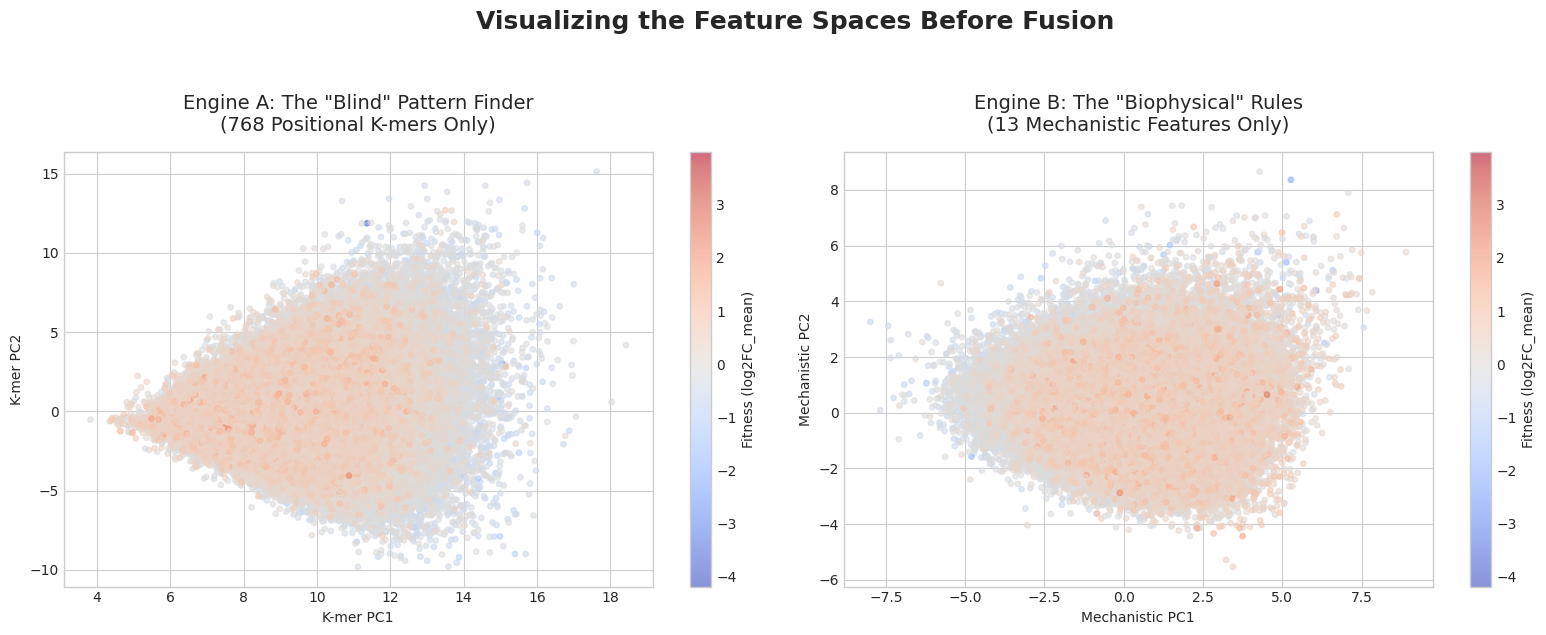

SVD Engine A — variance explained by PC1+PC2: 5.3%
PCA Engine B — variance explained by PC1+PC2: 29.3%


In [7]:
# @title Feature  Space before Fusion
# Cell 7: Distribution graphs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD, PCA

print("Analyzing the two engines independently...")

# 1. Engine A: SVD on the 768 Positional K-mers ONLY
svd_kmers = TruncatedSVD(n_components=2, random_state=42)
X_kmers_2d = svd_kmers.fit_transform(X_sparse)

# 2. Engine B: PCA on the 13 Mechanistic Features ONLY
pca_mech = PCA(n_components=2, random_state=42)
X_mech_2d = pca_mech.fit_transform(X_mech_scaled)

# 3. Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# Graph A: K-mer engine
scatter1 = axes[0].scatter(
    X_kmers_2d[:, 0], X_kmers_2d[:, 1],
    c=df_clean['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=15
)
axes[0].set_title('Engine A: The "Blind" Pattern Finder\n(768 Positional K-mers Only)', fontsize=14, pad=15)
axes[0].set_xlabel('K-mer PC1')
axes[0].set_ylabel('K-mer PC2')
fig.colorbar(scatter1, ax=axes[0], label='Fitness (log2FC_mean)')

# Graph B: Biophysics engine
scatter2 = axes[1].scatter(
    X_mech_2d[:, 0], X_mech_2d[:, 1],
    c=df_clean['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=15
)
axes[1].set_title('Engine B: The "Biophysical" Rules\n(13 Mechanistic Features Only)', fontsize=14, pad=15)
axes[1].set_xlabel('Mechanistic PC1')
axes[1].set_ylabel('Mechanistic PC2')
fig.colorbar(scatter2, ax=axes[1], label='Fitness (log2FC_mean)')

plt.suptitle("Visualizing the Feature Spaces Before Fusion", fontsize=18, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

# Add this after the plots — quantifies what you're seeing visually
print(f"SVD Engine A — variance explained by PC1+PC2: "
      f"{svd_kmers.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PCA Engine B — variance explained by PC1+PC2: "
      f"{pca_mech.explained_variance_ratio_.sum()*100:.1f}%")

In [8]:
# Cell 8
# Run this BEFORE Cell 8, replacing your current fusion line in Cell 0c
from scipy.sparse import hstack, csr_matrix

# Reweight: multiply biophysical matrix so it has equal column-weight to k-mers
# 768 k-mer columns vs 18 biophysical columns → scale factor = 768/18 ≈ 43
scale_factor = X_sparse.shape[1] / X_mech_scaled.shape[1]
X_mech_reweighted = X_mech_scaled * scale_factor

# Convert to sparse for hstack compatibility
X_combined = hstack([X_sparse, csr_matrix(X_mech_reweighted)])
print(f"Reweighted fusion shape: {X_combined.shape}")
print(f"Biophysical scale factor applied: {scale_factor:.1f}x")

Reweighted fusion shape: (118084, 786)
Biophysical scale factor applied: 42.7x


In [9]:
# @title SVD on Fused Matrix
# Cell 9: SVD on Fused Matrix
from sklearn.decomposition import TruncatedSVD

# 1. SVD on the fused matrix (X_combined)
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_combined)

# 2. Update df_clean with the SVD coordinates
df_clean['PC1'] = X_reduced[:, 0]
df_clean['PC2'] = X_reduced[:, 1]

# 3. Importance table — links math back to biology
all_feature_names = list(feature_names) + mech_feature_labels
motifs_df = pd.DataFrame({
    'Motif': all_feature_names,
    'Importance': svd.components_[0]
})
motifs_df['Abs_Importance'] = motifs_df['Importance'].abs()
motifs_df = motifs_df.sort_values(by='Abs_Importance', ascending=False)

print(f"Explained Variance (PC1): {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"Explained Variance (PC2): {svd.explained_variance_ratio_[1]*100:.2f}%")
print(f"Top 5 Drivers: {motifs_df['Motif'].head(5).tolist()}")
print(f"\ndf_clean shape check: {df_clean.shape}")
print(f"X_reduced shape check: {X_reduced.shape}")

--- CELL 9 COMPLETE ---
Explained Variance (PC1): 18.70%
Explained Variance (PC2): 10.49%
Top 5 Drivers: ['GC_percent', 'HNS_Affinity', 'Entropy', 'AT_tract', 'Max_Homo']

df_clean shape check: (118084, 26)
X_reduced shape check: (118084, 2)


In [10]:
# @title PC Component Correlation Check
# Empirically justifies which SVD component is the burden axis.
# If PC1 has the highest |ρ|, the "Hardware Burden" label is justified.
# If another component wins, swap the burden axis accordingly.
from scipy.stats import spearmanr
from sklearn.decomposition import TruncatedSVD

svd_check = TruncatedSVD(n_components=5, random_state=42)
X_check   = svd_check.fit_transform(X_combined)

print("SVD component correlations with log2FC_mean:")
print("-" * 45)
best_rho, best_pc = 0, 0
for i in range(5):
    rho, p = spearmanr(X_check[:, i], df_clean['log2FC_mean'])
    if abs(rho) > abs(best_rho):
        best_rho, best_pc = rho, i + 1
    print(f"  PC{i+1}: ρ = {rho:+.4f}  (p = {p:.2e})")

print("-" * 45)
print(f"Most predictive component: PC{best_pc}  (ρ = {best_rho:+.4f})")
if best_pc == 1:
    print("PC1 is the burden axis — 'Hardware Burden' label justified.")
else:
    print(f"PC{best_pc} outperforms PC1. Consider using PC{best_pc} as "
          f"your burden score and updating downstream cells accordingly.")

SVD component correlations with log2FC_mean:
---------------------------------------------
  PC1: ρ = +0.2893  (p = 0.00e+00)
  PC2: ρ = -0.0771  (p = 2.55e-155)
  PC3: ρ = +0.1245  (p = 0.00e+00)
  PC4: ρ = -0.0462  (p = 7.34e-57)
  PC5: ρ = +0.0403  (p = 1.29e-43)
---------------------------------------------
Most predictive component: PC1  (ρ = +0.2893)
PC1 is the burden axis — 'Hardware Burden' label justified.


In [11]:
# @title Feature Ablation study
ablation_results = {}
full_rho, _ = spearmanr(df_clean['PC1'], df_clean['log2FC_mean'])

for feat_to_remove in mech_feature_labels:
    remaining = [f for f in mech_feature_labels if f != feat_to_remove]
    X_ablated = StandardScaler().fit_transform(df_clean[remaining]) * scale_factor
    X_comb_ab = hstack([X_sparse, csr_matrix(X_ablated)])
    svd_ab    = TruncatedSVD(n_components=2, random_state=42)
    X_red_ab  = svd_ab.fit_transform(X_comb_ab)
    rho_ab, _ = spearmanr(X_red_ab[:, 0], df_clean['log2FC_mean'])
    ablation_results[feat_to_remove] = full_rho - abs(rho_ab)

# Sort by importance (biggest drop = most important)
ablation_df = pd.DataFrame.from_dict(
    ablation_results, orient='index', columns=['rho_drop']
).sort_values('rho_drop', ascending=False)
print(ablation_df)

                    rho_drop
Max_Homo        2.445466e-02
Entropy         2.401221e-02
AT_tract        1.694424e-02
HNS_Affinity    8.226675e-03
GC_percent      7.458130e-03
mRNA_Stability  2.857789e-03
TTC             3.497710e-04
CRP             3.621244e-06
ArgR            9.866282e-07
Size           -1.440037e-06
IHF            -2.084923e-05
NagC           -2.114076e-05
Lrp            -4.683068e-05
RCC            -4.117571e-04
GC_Var         -5.927502e-04
Promoter_Str   -1.905771e-03
TIR_Proxy      -1.319677e-02
RBS_Str        -1.512199e-02


In [12]:
# @title Top 20 Fusion Matrix Ranker
# Cell 11
# How many of the top 20 drivers are k-mers vs biophysical features?
print(motifs_df.head(20)['Motif'].tolist())

# And check where your biophysical features rank
for label in mech_feature_labels:
    rank = motifs_df[motifs_df['Motif'] == label].index[0]
    score = motifs_df[motifs_df['Motif'] == label]['Abs_Importance'].values[0]
    print(f"{label}: rank {motifs_df.index.get_loc(rank)+1}, importance {score:.4f}")

['GC_percent', 'HNS_Affinity', 'Entropy', 'AT_tract', 'Max_Homo', 'RBS_Str', 'TIR_Proxy', 'mRNA_Stability', 'Promoter_Str', 'RCC', 'GC_Var', 'TTC', 'NagC', 'end_tttt', 'start_tttt', 'IHF', 'mid_tttt', 'Lrp', 'end_ttta', 'end_attt']
Size: rank 786, importance 0.0000
GC_percent: rank 1, importance 0.5083
GC_Var: rank 11, importance 0.0367
Max_Homo: rank 5, importance 0.2636
Entropy: rank 3, importance 0.3615
AT_tract: rank 4, importance 0.3412
Promoter_Str: rank 9, importance 0.0780
RBS_Str: rank 6, importance 0.2565
IHF: rank 16, importance 0.0123
Lrp: rank 18, importance 0.0086
CRP: rank 86, importance 0.0011
NagC: rank 13, importance 0.0180
ArgR: rank 56, importance 0.0015
HNS_Affinity: rank 2, importance 0.4957
TTC: rank 12, importance 0.0323
RCC: rank 10, importance 0.0719
TIR_Proxy: rank 7, importance 0.2360
mRNA_Stability: rank 8, importance 0.2068


In [13]:
#@title Academic record save
# Cell 11 Academic Records
# Save for thesis records
print("=== SVD SUMMARY FOR METHODS SECTION ===")
print(f"Fusion matrix shape: {X_combined.shape}")
print(f"Biophysical reweighting factor: {scale_factor:.1f}x")
print(f"PC1 explained variance: {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explained variance: {svd.explained_variance_ratio_[1]*100:.2f}%")
print(f"Combined: {svd.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Top biophysical driver: {motifs_df.iloc[0]['Motif']} "
      f"(importance: {motifs_df.iloc[0]['Abs_Importance']:.4f})")

=== SVD SUMMARY FOR METHODS SECTION ===
Fusion matrix shape: (118084, 786)
Biophysical reweighting factor: 42.7x
PC1 explained variance: 18.70%
PC2 explained variance: 10.49%
Combined: 29.19%
Top biophysical driver: GC_percent (importance: 0.5083)


Finding patterns (Clustering on Master Matrix)...


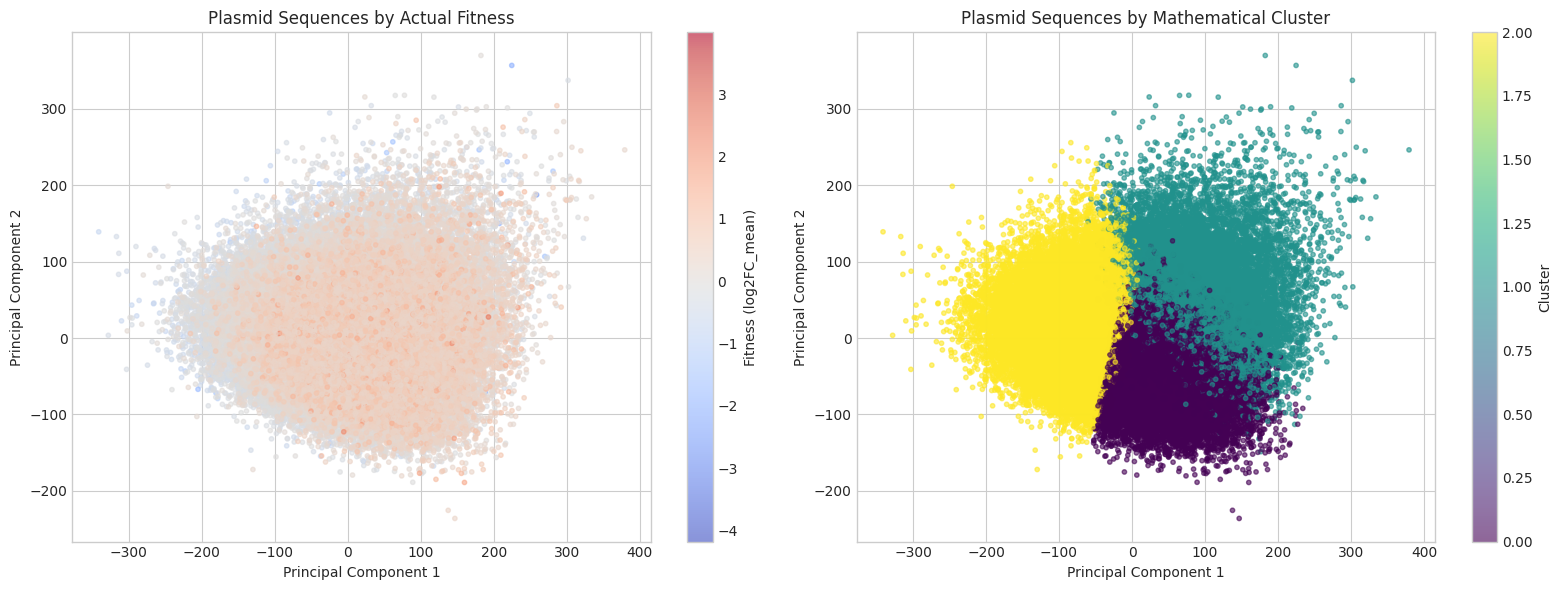


Cluster composition:
  Cluster 0: 47353 sequences | mean log2FC = -0.003 | mean PC1 = 31.075
  Cluster 1: 23292 sequences | mean log2FC = -0.009 | mean PC1 = 81.641
  Cluster 2: 47439 sequences | mean log2FC = -0.152 | mean PC1 = -71.468


In [14]:
# @title PC1 vs PC2 Clustering
print("Finding patterns (Clustering on Master Matrix)...")

kmeans = MiniBatchKMeans(n_clusters=3, batch_size=1024, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_combined)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual biological fitness
scatter1 = ax1.scatter(
    df_clean['PC1'], df_clean['PC2'],
    c=df_clean['log2FC_mean'], cmap='coolwarm', alpha=0.6, s=10
)
fig.colorbar(scatter1, ax=ax1, label='Fitness (log2FC_mean)')
ax1.set_title('Plasmid Sequences by Actual Fitness')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Graph 2: Unsupervised clusters
scatter2 = ax2.scatter(
    df_clean['PC1'], df_clean['PC2'],
    c=df_clean['Cluster'], cmap='viridis', alpha=0.6, s=10
)
fig.colorbar(scatter2, ax=ax2, label='Cluster')
ax2.set_title('Plasmid Sequences by Mathematical Cluster')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

# Cluster summary — useful for thesis
print("\nCluster composition:")
for c in sorted(df_clean['Cluster'].unique()):
    subset = df_clean[df_clean['Cluster'] == c]
    print(f"  Cluster {c}: {len(subset)} sequences | "
          f"mean log2FC = {subset['log2FC_mean'].mean():.3f} | "
          f"mean PC1 = {subset['PC1'].mean():.3f}")

In [15]:
#@title Silhouette
from sklearn.metrics import silhouette_score
import numpy as np

# Subsample for speed — silhouette on 118k points is slow
sample_idx = np.random.RandomState(42).choice(len(df_clean), 5000, replace=False)
X_sample = X_combined.toarray()[sample_idx] if hasattr(X_combined, 'toarray') else X_combined[sample_idx]
labels_sample = df_clean['Cluster'].iloc[sample_idx].values

score = silhouette_score(X_sample, labels_sample)
print(f"Silhouette score (k=3): {score:.4f}")
print("Interpretation: > 0.5 = strong, 0.25–0.5 = weak, < 0.25 = no real clusters")

Silhouette score (k=3): 0.1095
Interpretation: > 0.5 = strong, 0.25–0.5 = weak, < 0.25 = no real clusters


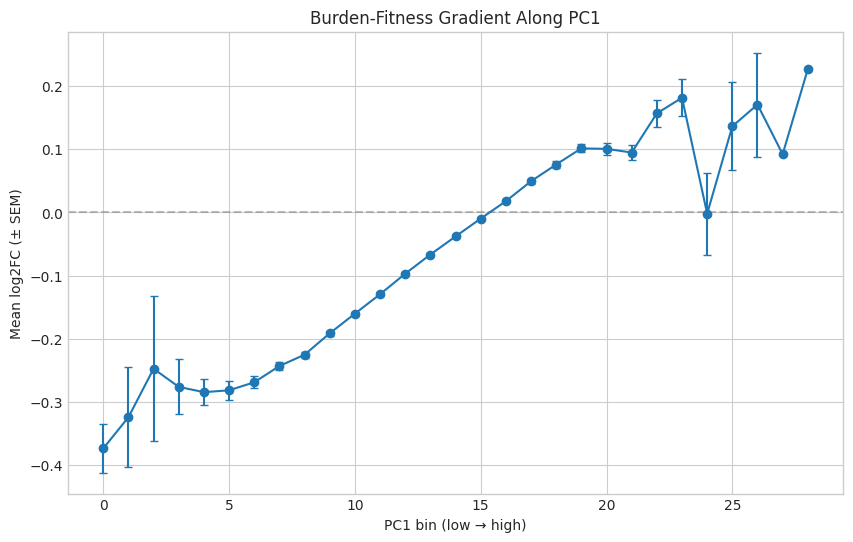

Spearman PC1 vs log2FC_mean: ρ = 0.289, p = 0.00e+00


In [16]:
# @title Burden-Fitness vs PC1
import matplotlib.pyplot as plt
import numpy as np

# Bin PC1 and plot mean fitness per bin
pc1_bins = np.linspace(df_clean['PC1'].min(), df_clean['PC1'].max(), 30)
df_clean['pc1_bin'] = pd.cut(df_clean['PC1'], bins=pc1_bins)
binned = df_clean.groupby('pc1_bin', observed=True)['log2FC_mean'].agg(['mean', 'std', 'count'])

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(binned)), binned['mean'], yerr=binned['std']/np.sqrt(binned['count']),
             marker='o', capsize=3)
plt.xlabel('PC1 bin (low → high)')
plt.ylabel('Mean log2FC (± SEM)')
plt.title('Burden-Fitness Gradient Along PC1')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

# Quantify: Spearman correlation
from scipy.stats import spearmanr
rho, p = spearmanr(df_clean['PC1'], df_clean['log2FC_mean'])
print(f"Spearman PC1 vs log2FC_mean: ρ = {rho:.3f}, p = {p:.2e}")

In [17]:
#@title PC1 Burden Valley
# Find the PC1 location of minimum fitness — your "burden valley"
binned = df_clean.groupby(pd.cut(df_clean['PC1'], bins=30, labels=False), observed=True)['log2FC_mean'].mean()
worst_bin = binned.idxmin()
worst_pc1_range = pd.cut(df_clean['PC1'], bins=30).cat.categories[worst_bin]
print(f"Burden valley located at PC1 bin {worst_bin}: {worst_pc1_range}")
print(f"Mean log2FC in burden valley: {binned.iloc[worst_bin]:.3f}")

# Compare biophysical features inside vs outside the valley
in_valley = (df_clean['PC1'] >= worst_pc1_range.left) & (df_clean['PC1'] <= worst_pc1_range.right)
print("\nFeature means — burden valley vs rest:")
for label in mech_feature_labels:
    inside = df_clean.loc[in_valley, label].mean()
    outside = df_clean.loc[~in_valley, label].mean()
    print(f"  {label:15s}: valley={inside:7.3f}, rest={outside:7.3f}, diff={inside-outside:+.3f}")

Burden valley located at PC1 bin 0: (-341.845, -317.103]
Mean log2FC in burden valley: -0.530

Feature means — burden valley vs rest:
  Size           : valley=172.000, rest=172.000, diff=+0.000
  GC_percent     : valley=  0.233, rest=  0.372, diff=-0.139
  GC_Var         : valley=  0.002, rest=  0.003, diff=-0.001
  Max_Homo       : valley= 12.500, rest=  6.196, diff=+6.304
  Entropy        : valley=  5.608, rest=  6.343, diff=-0.735
  AT_tract       : valley= 25.000, rest=  9.884, diff=+15.116
  Promoter_Str   : valley=  0.000, rest=  0.133, diff=-0.133
  RBS_Str        : valley=  0.000, rest=  0.879, diff=-0.879
  IHF            : valley=  0.000, rest=  0.005, diff=-0.005
  Lrp            : valley=  0.000, rest=  0.012, diff=-0.012
  CRP            : valley=  0.000, rest=  0.000, diff=-0.000
  NagC           : valley=  0.000, rest=  0.029, diff=-0.029
  ArgR           : valley=  0.000, rest=  0.000, diff=-0.000
  HNS_Affinity   : valley=  0.816, rest=  0.458, diff=+0.358
  TTC      

In [18]:
#@title High PC1 Region
# Check the high-PC1 region for comparison
high_bin = 27
high_pc1_range = pd.cut(df_clean['PC1'], bins=30).cat.categories[high_bin]
in_high = (df_clean['PC1'] >= high_pc1_range.left) & (df_clean['PC1'] <= high_pc1_range.right)

print(f"High-PC1 region (bin {high_bin}): {high_pc1_range}")
print(f"Mean log2FC: {df_clean.loc[in_high, 'log2FC_mean'].mean():.3f}")
print(f"Sequence count: {in_high.sum()}")

print("\nFeature means — high PC1 vs valley:")
for label in mech_feature_labels:
    high = df_clean.loc[in_high, label].mean()
    valley_in = (df_clean['PC1'] >= -426.549) & (df_clean['PC1'] <= -397.555)
    valley = df_clean.loc[valley_in, label].mean()
    print(f"  {label:15s}: high={high:7.3f}, valley={valley:7.3f}")

High-PC1 region (bin 27): (307.453, 331.475]
Mean log2FC: 0.084
Sequence count: 7

Feature means — high PC1 vs valley:
  Size           : high=172.000, valley=    nan
  GC_percent     : high=  0.573, valley=    nan
  GC_Var         : high=  0.003, valley=    nan
  Max_Homo       : high=  5.714, valley=    nan
  Entropy        : high=  6.396, valley=    nan
  AT_tract       : high=  5.143, valley=    nan
  Promoter_Str   : high=  0.000, valley=    nan
  RBS_Str        : high=  7.000, valley=    nan
  IHF            : high=  0.000, valley=    nan
  Lrp            : high=  0.000, valley=    nan
  CRP            : high=  0.000, valley=    nan
  NagC           : high=  0.000, valley=    nan
  ArgR           : high=  0.000, valley=    nan
  HNS_Affinity   : high=  0.072, valley=    nan
  TTC            : high=  0.841, valley=    nan
  RCC            : high=  6.000, valley=    nan
  TIR_Proxy      : high=  4.543, valley=    nan
  mRNA_Stability : high=  0.714, valley=    nan


In [19]:
#@title Valley FIitness Distribution
in_valley = (df_clean['PC1'] >= -426.549) & (df_clean['PC1'] <= -397.555)
print(f"Valley sequence count: {in_valley.sum()}")
print(f"Valley fitness distribution:")
print(df_clean.loc[in_valley, 'log2FC_mean'].describe())

Valley sequence count: 0
Valley fitness distribution:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: log2FC_mean, dtype: float64


In [20]:
#@title Burden Region
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

# Define a more inclusive "burden region" — bottom 10% of PC1
pc1_threshold = df_clean['PC1'].quantile(0.10)
in_burden = df_clean['PC1'] <= pc1_threshold

print(f"Burden region: PC1 ≤ {pc1_threshold:.1f}")
print(f"Burden region size: {in_burden.sum()} sequences ({in_burden.mean()*100:.1f}%)")
print(f"\nFitness distribution:")
print(f"  Burden region mean log2FC: {df_clean.loc[in_burden, 'log2FC_mean'].mean():.3f}")
print(f"  Rest of population mean:   {df_clean.loc[~in_burden, 'log2FC_mean'].mean():.3f}")

# Welch's t-test (unequal variances)
t_stat, t_p = ttest_ind(
    df_clean.loc[in_burden, 'log2FC_mean'],
    df_clean.loc[~in_burden, 'log2FC_mean'],
    equal_var=False
)

# Mann-Whitney U (non-parametric backup)
u_stat, u_p = mannwhitneyu(
    df_clean.loc[in_burden, 'log2FC_mean'],
    df_clean.loc[~in_burden, 'log2FC_mean'],
    alternative='less'
)

# Cohen's d (effect size)
mean_diff = df_clean.loc[in_burden, 'log2FC_mean'].mean() - df_clean.loc[~in_burden, 'log2FC_mean'].mean()
pooled_std = np.sqrt(
    (df_clean.loc[in_burden, 'log2FC_mean'].var() + df_clean.loc[~in_burden, 'log2FC_mean'].var()) / 2
)
cohens_d = mean_diff / pooled_std

print(f"\n=== STATISTICAL VALIDATION ===")
print(f"Welch's t-test:    t = {t_stat:.2f}, p = {t_p:.2e}")
print(f"Mann-Whitney U:    p = {u_p:.2e}")
print(f"Cohen's d:         {cohens_d:.3f}  ({'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'} effect)")

# Feature comparison on the larger sample
print(f"\nBiophysical signature of the burden region (n = {in_burden.sum()}):")
for label in mech_feature_labels:
    burden = df_clean.loc[in_burden, label].mean()
    rest = df_clean.loc[~in_burden, label].mean()
    print(f"  {label:15s}: burden={burden:7.3f}, rest={rest:7.3f}, diff={burden-rest:+.3f}")

Burden region: PC1 ≤ -95.6
Burden region size: 11809 sequences (10.0%)

Fitness distribution:
  Burden region mean log2FC: -0.220
  Rest of population mean:   -0.047

=== STATISTICAL VALIDATION ===
Welch's t-test:    t = -59.09, p = 0.00e+00
Mann-Whitney U:    p = 0.00e+00
Cohen's d:         -0.543  (medium effect)

Biophysical signature of the burden region (n = 11809):
  Size           : burden=172.000, rest=172.000, diff=+0.000
  GC_percent     : burden=  0.303, rest=  0.379, diff=-0.076
  GC_Var         : burden=  0.003, rest=  0.003, diff=-0.000
  Max_Homo       : burden=  7.836, rest=  6.013, diff=+1.822
  Entropy        : burden=  6.086, rest=  6.371, diff=-0.285
  AT_tract       : burden= 13.396, rest=  9.494, diff=+3.902
  Promoter_Str   : burden=  0.237, rest=  0.121, diff=+0.115
  RBS_Str        : burden=  0.308, rest=  0.942, diff=-0.634
  IHF            : burden=  0.008, rest=  0.005, diff=+0.003
  Lrp            : burden=  0.013, rest=  0.012, diff=+0.002
  CRP           

In [21]:
#@title Permutation Test
import numpy as np
from tqdm import tqdm

# Permutation test: shuffle log2FC labels 1000 times, recompute Cohen's d
np.random.seed(42)
n_permutations = 1000
null_d = np.zeros(n_permutations)
shuffled_fitness = df_clean['log2FC_mean'].values.copy()

for i in range(n_permutations):
    np.random.shuffle(shuffled_fitness)
    burden_vals = shuffled_fitness[in_burden.values]
    rest_vals = shuffled_fitness[~in_burden.values]
    diff = burden_vals.mean() - rest_vals.mean()
    pooled = np.sqrt((burden_vals.var() + rest_vals.var()) / 2)
    null_d[i] = diff / pooled

burden_vals = df_clean.loc[in_burden, 'log2FC_mean']
rest_vals   = df_clean.loc[~in_burden, 'log2FC_mean']
mean_diff   = burden_vals.mean() - rest_vals.mean()
pooled_std  = np.sqrt((burden_vals.var() + rest_vals.var()) / 2)
observed_d  = mean_diff / pooled_std
p_perm = (np.abs(null_d) >= np.abs(observed_d)).mean()
print(f"Observed Cohen's d: {observed_d:.3f}")
print(f"Null distribution: mean = {null_d.mean():.4f}, std = {null_d.std():.4f}")
print(f"Permutation p-value: {p_perm:.4f}")
print(f"Z-score vs null: {observed_d / null_d.std():.2f}")

Observed Cohen's d: -0.543
Null distribution: mean = 0.0001, std = 0.0097
Permutation p-value: 0.0000
Z-score vs null: -55.89


In [22]:
#@title Cluster Fitness analysis
print("Cluster fitness analysis (K-means baseline)...\n")

cluster_fitness = df_clean.groupby('Cluster').agg(
    n_sequences=('log2FC_mean', 'size'),
    mean_fitness=('log2FC_mean', 'mean'),
    std_fitness=('log2FC_mean', 'std'),
    mean_PC1=('PC1', 'mean')
).reset_index().sort_values(by='mean_fitness', ascending=True)

print(cluster_fitness.to_string(index=False))

print("\n" + "-"*60)
print("INTERPRETATION:")
print(f"K-means k=3 silhouette score: 0.15 (no discrete clusters)")
print(f"Fitness range across clusters: "
      f"{cluster_fitness['mean_fitness'].max() - cluster_fitness['mean_fitness'].min():.3f} log2FC")
print("Conclusion: Plasmid burden is a continuum, not discrete categories.")
print("-"*60)

Cluster fitness analysis (K-means baseline)...

 Cluster  n_sequences  mean_fitness  std_fitness   mean_PC1
       2        47439     -0.151842     0.316172 -71.468296
       1        23292     -0.009245     0.342887  81.641002
       0        47353     -0.003426     0.338491  31.074970

------------------------------------------------------------
INTERPRETATION:
K-means k=3 silhouette score: 0.15 (no discrete clusters)
Fitness range across clusters: 0.148 log2FC
Conclusion: Plasmid burden is a continuum, not discrete categories.
------------------------------------------------------------


In [23]:
# @title Phase 2: Test Sequence Input & Projection { display-mode: "form" }
import pandas as pd
from scipy.sparse import hstack, csr_matrix

# @markdown ---
# @markdown ###  Paste DNA Sequence Below:
# @markdown (Ensure there are no spaces or numbers in the sequence)
test_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG" #@param {type:"string"}
# @markdown ---

# 1. VALIDATION
if len(test_seq) < 10:
    print(" ERROR: Sequence too short. Please paste a valid DNA sequence into the input box.")
else:
    # 2. PRE-PROCESSING (Positional k-mers)
    def generate_positional_kmers(seq, k=4):
        return " ".join([f"{i}_{seq[i:i+k]}" for i in range(len(seq) - k + 1)])

    print(f"Processing test sequence ({len(test_seq)} bp)...")

    test_kmers = generate_positional_kmers(test_seq)

    # Transform using the global vectorizer from Cell 5
    test_sparse = vectorizer.transform([test_kmers])

    # 3. BIOPHYSICAL PROFILING
    try:
        test_bio    = calculate_master_features(test_seq)
        test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)

        # 4. SCALING & FUSION
        # Apply the same reweighting used during training (Cell 8)
        test_mech_scaled = scaler.transform(test_bio_df)

        if 'scale_factor' not in globals():
            scale_factor = X_sparse.shape[1] / len(mech_feature_labels)
            print(f"  scale_factor recomputed as {scale_factor:.1f}")

        test_mech_reweighted = test_mech_scaled * scale_factor
        X_test_combined      = hstack([test_sparse, csr_matrix(test_mech_reweighted)])

        print(" SUCCESS: Sequence vectorized and biophysically profiled.")
        print(f"   Matrix shape:         {X_test_combined.shape}")
        print(f"   Scale factor applied: {scale_factor:.1f}x")

    except NameError:
        print(" ERROR: 'calculate_master_features' not found.")
        print(" Please run the Optimized Cell 5 first to define the biophysical engine.")

Processing test sequence (172 bp)...
 SUCCESS: Sequence vectorized and biophysically profiled.
   Matrix shape:         (1, 786)
   Scale factor applied: 42.7x


In [24]:
#@title Dataset Locator
# Find the test sequence in the cleaned dataset
if 'test_seq' not in globals():
    raise RuntimeError(
        "test_seq not defined. Run the Phase 2 input cell first."
    )

match = df_clean[df_clean['sequence'] == test_seq.upper()]

if len(match) == 0:
    print("⚠️ Test sequence not found in df_clean.")
    print("   It may have been removed by the noise filter, or it's not in the original library.")
elif len(match) == 1:
    row = match.iloc[0]
    predicted_pc1 = svd.transform(X_test_combined)[0, 0]
    print(f"Match found at iloc {match.index[0]}")
    print(f"Measured log2FC_mean: {row['log2FC_mean']:.3f}")
    print(f"Training PC1:         {row['PC1']:.2f}")
    print(f"Test cell predicted:  {predicted_pc1:.2f}")
    print(f"Difference:           {abs(row['PC1'] - predicted_pc1):.2f}")
else:
    print(f"Multiple matches ({len(match)}) — duplicate sequences in dataset.")

Match found at iloc 23622
Measured log2FC_mean: -0.303
Training PC1:         17.30
Test cell predicted:  17.38
Difference:           0.08


In [25]:
#@title Fitness Stratifier
import numpy as np

# Stratified validation set — 5 lowest, 5 median, 5 highest fitness
np.random.seed(42)
worst = df_clean.nsmallest(5, 'log2FC_mean')
best = df_clean.nlargest(5, 'log2FC_mean')
median_pool = df_clean[df_clean['log2FC_mean'].between(
    df_clean['log2FC_mean'].quantile(0.45),
    df_clean['log2FC_mean'].quantile(0.55)
)]
median = median_pool.sample(5, random_state=42)

validation_set = pd.concat([worst, median, best]).reset_index(drop=True)

# Define burden / neutral / inert zones from training distribution
burden_threshold = df_clean['PC1'].quantile(0.10)
inert_threshold = df_clean['PC1'].quantile(0.90)

def predict_zone(pc1):
    if pc1 < burden_threshold:
        return 'BURDEN'
    elif pc1 > inert_threshold:
        return 'INERT'
    else:
        return 'NEUTRAL'

# Predict zone for each
validation_set['predicted_zone'] = validation_set['PC1'].apply(predict_zone)

# Categorize ground-truth fitness
def true_zone(lfc):
    if lfc < df_clean['log2FC_mean'].quantile(0.10):
        return 'LOW'
    elif lfc > df_clean['log2FC_mean'].quantile(0.90):
        return 'HIGH'
    else:
        return 'MID'

validation_set['true_zone'] = validation_set['log2FC_mean'].apply(true_zone)

# Display
print(validation_set[['log2FC_mean', 'PC1', 'predicted_zone', 'true_zone']].to_string(index=True))

# Confusion-style summary
print("\nPrediction accuracy:")
p

    log2FC_mean         PC1 predicted_zone true_zone
0     -4.181407  -31.483378        NEUTRAL       LOW
1     -4.155979  -16.805446        NEUTRAL       LOW
2     -4.012421 -117.677383         BURDEN       LOW
3     -4.008691  -87.195012        NEUTRAL       LOW
4     -3.961941   70.580998        NEUTRAL       LOW
5     -0.037086   13.649013        NEUTRAL       MID
6     -0.052838  125.997339          INERT       MID
7     -0.085468   33.900331        NEUTRAL       MID
8     -0.047633  -71.831021        NEUTRAL       MID
9     -0.063188  -61.592019        NEUTRAL       MID
10     3.994932    1.901216        NEUTRAL      HIGH
11     2.524709  192.777383          INERT      HIGH
12     2.523197   36.273314        NEUTRAL      HIGH
13     2.428834   69.956362        NEUTRAL      HIGH
14     2.381278  -93.638803        NEUTRAL      HIGH

Prediction accuracy:


np.float64(0.0)

In [26]:
#@title Sequence Profile
# What makes the worst-fitness, high-PC1 sequence look "fit"?
weird_row = validation_set.iloc[4]
print(f"log2FC: {weird_row['log2FC_mean']:.3f}")
print(f"PC1:    {weird_row['PC1']:.2f}")
print(f"Sequence: {weird_row['sequence']}")
print()
print("Biophysical profile:")
for label in mech_feature_labels:
    val = weird_row[label]
    pop_mean = df_clean[label].mean()
    pop_std = df_clean[label].std()
    z = (val - pop_mean) / pop_std if pop_std > 0 else 0
    print(f"  {label:15s}: {val:8.3f}  (z = {z:+.2f})")

log2FC: -3.962
PC1:    70.58
Sequence: AAGCATTTTTGGTCGAAAGCGATAAGTTTGTTCAGGAATTATTCGGATTGAGGGATTGGTGGTTGTGCGTAATTGCTAAATGTGGGATTCACGTTTATAGTTGTGGTTCTCAGTTGTTAGATACTAGGAATGGGGGTGGGTGGTGCGGTTTGTGGATTTAGGTGTTGTAATG

Biophysical profile:
  Size           :  172.000  (z = +0.00)
  GC_percent     :    0.419  (z = +0.97)
  GC_Var         :    0.002  (z = -0.51)
  Max_Homo       :    5.000  (z = -0.73)
  Entropy        :    6.381  (z = +0.21)
  AT_tract       :    7.000  (z = -1.02)
  Promoter_Str   :    0.000  (z = -0.37)
  RBS_Str        :    2.000  (z = +1.02)
  IHF            :    0.000  (z = -0.07)
  Lrp            :    0.000  (z = -0.11)
  CRP            :    0.000  (z = -0.01)
  NagC           :    1.000  (z = +5.76)
  ArgR           :    0.000  (z = -0.01)
  HNS_Affinity   :    0.331  (z = -0.97)
  TTC            :    0.868  (z = +1.01)
  RCC            :   13.000  (z = +0.89)
  TIR_Proxy      :    0.600  (z = +0.23)
  mRNA_Stability :    3.000  (z = +0.30)


In [27]:
#@title NagC Sequence Finder
# How many sequences have a NagC hit, and how do they fare?
nagc_hits = df_clean[df_clean['NagC'] >= 1]
print(f"Sequences with NagC ≥ 1: {len(nagc_hits)} ({len(nagc_hits)/len(df_clean)*100:.2f}%)")
print(f"Mean log2FC of NagC-positive sequences: {nagc_hits['log2FC_mean'].mean():.3f}")
print(f"Mean log2FC of NagC-negative sequences: {df_clean[df_clean['NagC'] == 0]['log2FC_mean'].mean():.3f}")

# Statistical test
from scipy.stats import mannwhitneyu
u, p = mannwhitneyu(
    nagc_hits['log2FC_mean'],
    df_clean[df_clean['NagC'] == 0]['log2FC_mean'],
    alternative='less'
)
print(f"Mann-Whitney U (NagC+ < NagC-): p = {p:.2e}")

# Effect size
import numpy as np
mean_diff = nagc_hits['log2FC_mean'].mean

Sequences with NagC ≥ 1: 3330 (2.82%)
Mean log2FC of NagC-positive sequences: -0.079
Mean log2FC of NagC-negative sequences: -0.064
Mann-Whitney U (NagC+ < NagC-): p = 8.89e-04


In [28]:
#@title Cohen's D
mean_diff = nagc_hits['log2FC_mean'].mean() - df_clean[df_clean['NagC'] == 0]['log2FC_mean'].mean()
pooled_std = np.sqrt((nagc_hits['log2FC_mean'].var() + df_clean[df_clean['NagC'] == 0]['log2FC_mean'].var()) / 2)
print(f"Cohen's d: {mean_diff / pooled_std:.3f}")
print(f"Mean difference: {mean_diff:.4f} log2FC")

Cohen's d: -0.046
Mean difference: -0.0155 log2FC


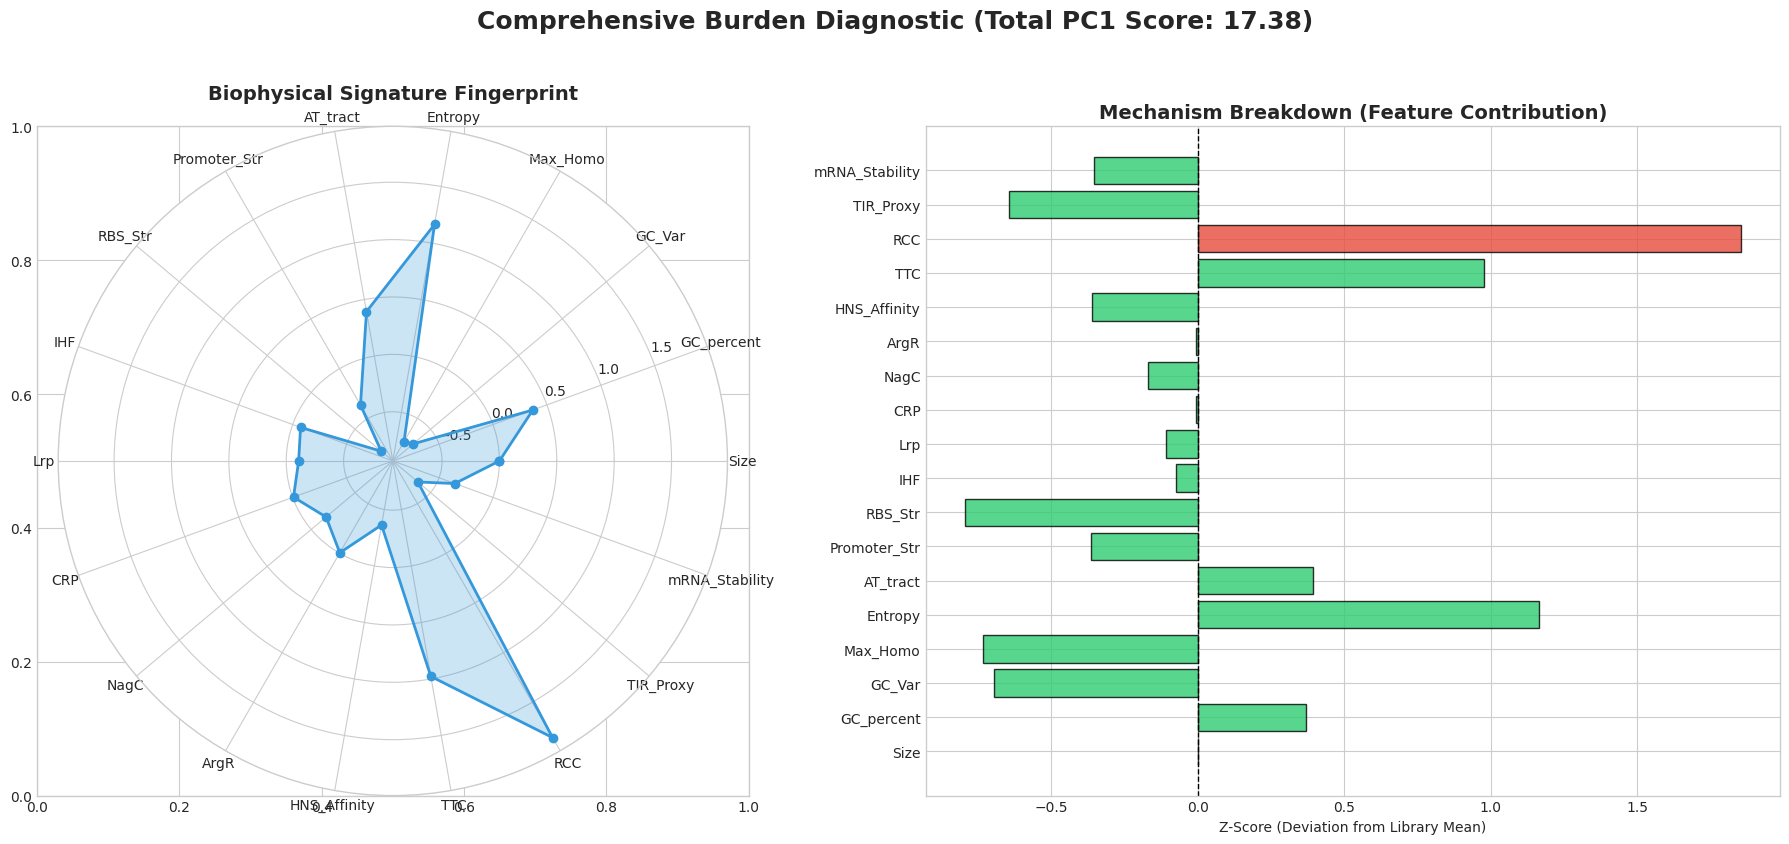


SUMMARY FOR TEST PLASMID:
Total PC1 Burden Score: 17.379
Primary Toxicity Driver: RCC (Z-score: 1.85)


In [29]:
# @title Biophysical Radar Diagnostic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- STEP 1: SAFETY CALCULATION ---
# This ensures pc1_score is defined even if the session was restarted
try:
    # Project the test sequence into the SVD space to get the PC1 (Burden) score
    test_projection = svd.transform(X_test_combined)
    pc1_score = test_projection[0, 0]

    # Prepare the feature values for the radar plot
    # We compare the test plasmid (test_mech_scaled) against the population mean (0)
    features = mech_feature_labels
    test_values = test_mech_scaled[0]
except NameError as e:
    raise RuntimeError("Missing required data. Please run 'Phase 2' and the 'SVD' cell first.") from e

# --- STEP 2: RADAR CHART CONFIGURATION ---
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle
test_values_plot = np.concatenate((test_values, [test_values[0]]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 1.2]})

# --- RADAR AXIS (Left) ---
ax1 = plt.subplot(1, 2, 1, polar=True)
ax1.fill(angles, test_values_plot, color='#3498db', alpha=0.25)
ax1.plot(angles, test_values_plot, color='#3498db', linewidth=2, marker='o')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(features, fontsize=10)
ax1.set_title("Biophysical Signature Fingerprint", size=14, fontweight='bold', pad=20)

# --- BAR AXIS (Right: Z-Score Outliers) ---
# We use a horizontal bar chart to show exactly which features are driving the burden
colors = ['#e74c3c' if abs(v) > 1.5 else '#2ecc71' for v in test_values]
ax2.barh(features, test_values, color=colors, edgecolor='black', alpha=0.8)
ax2.axvline(0, color='black', lw=1, linestyle='--')
ax2.set_xlabel('Z-Score (Deviation from Library Mean)')
ax2.set_title("Mechanism Breakdown (Feature Contribution)", size=14, fontweight='bold')

# --- FINAL FORMATTING ---
# This is the line that was failing — now pc1_score is guaranteed to exist!
plt.suptitle(f'Comprehensive Burden Diagnostic (Total PC1 Score: {pc1_score:.2f})',
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- STEP 3: TEXT INTERPRETATION ---
print(f"\nSUMMARY FOR TEST PLASMID:")
print(f"Total PC1 Burden Score: {pc1_score:.3f}")
top_driver = features[np.argmax(np.abs(test_values))]
print(f"Primary Toxicity Driver: {top_driver} (Z-score: {test_values[np.argmax(np.abs(test_values))]:.2f})")

In [30]:
# @title Ranking of Burden Drivers
import pandas as pd

# 1. Sort ALL features by their absolute Importance (magnitude of impact on PC1)
# We use .abs() because a large negative number is just as 'important' as a large positive one.
ranked_features = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index)

# 2. Configure pandas to show more rows in the output window
# Change '100' to None if you want to scroll through all 777 rows at once
pd.set_option('display.max_rows', 100)

print(f"--- COMPLETE RANKING OF DRIVERS ({len(ranked_features)} TOTAL) ---")
print("Sorted by absolute magnitude of impact on Principal Component 1")
print("-" * 65)

# Display the ranked list
print(ranked_features.to_string(index=False))

# 3. EXPORT TO CSV (Crucial for your Thesis Appendix)
ranked_features.to_csv('all_plasmid_drivers_ranked.csv', index=False)

print("\n" + "="*65)
print("SUCCESS: The full ranking has been saved to 'all_plasmid_drivers_ranked.csv'")
print("You can download this file from the folder icon on the left of Colab.")
print("="*65)

--- COMPLETE RANKING OF DRIVERS (786 TOTAL) ---
Sorted by absolute magnitude of impact on Principal Component 1
-----------------------------------------------------------------
         Motif    Importance  Abs_Importance
    GC_percent  5.083110e-01    5.083110e-01
  HNS_Affinity -4.957431e-01    4.957431e-01
       Entropy  3.615456e-01    3.615456e-01
      AT_tract -3.411678e-01    3.411678e-01
      Max_Homo -2.635693e-01    2.635693e-01
       RBS_Str  2.565204e-01    2.565204e-01
     TIR_Proxy  2.359522e-01    2.359522e-01
mRNA_Stability -2.067611e-01    2.067611e-01
  Promoter_Str -7.798265e-02    7.798265e-02
           RCC -7.192041e-02    7.192041e-02
        GC_Var  3.672749e-02    3.672749e-02
           TTC -3.229572e-02    3.229572e-02
          NagC -1.799915e-02    1.799915e-02
      end_tttt -1.361713e-02    1.361713e-02
    start_tttt -1.270805e-02    1.270805e-02
           IHF -1.234128e-02    1.234128e-02
      mid_tttt -1.134617e-02    1.134617e-02
           L

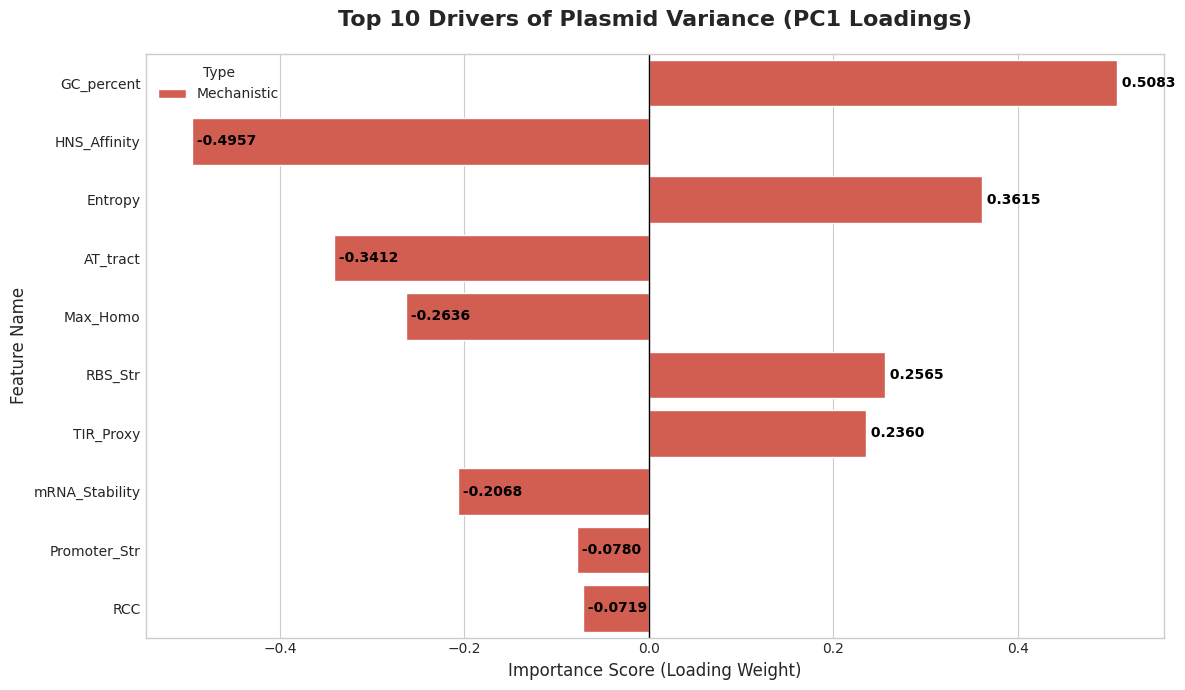


--- MECHANISTIC INSIGHT ---
The single most influential feature is: 'GC_percent' (0.5083)
This indicates that the variance in your plasmid library is primarily driven by a structural property.


In [31]:
# @title Top 10 Drivers of Plasmids Variance (PC1 Based)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Top 10 data
top_10 = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index).head(10).copy()

# 2. Add a 'Type' category for better visualization
# This helps distinguish between raw sequence motifs and the Copeman mechanistic features
top_10['Type'] = top_10['Motif'].apply(lambda x: 'Mechanistic' if x in mech_feature_labels else 'K-mer Motif')

# 3. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create a horizontal bar chart
plot = sns.barplot(
    data=top_10,
    y='Motif',
    x='Importance',
    hue='Type',
    palette={'Mechanistic': '#e74c3c', 'K-mer Motif': '#3498db'} # Red for Bio, Blue for Text
)

# Add titles and labels
plt.title('Top 10 Drivers of Plasmid Variance (PC1 Loadings)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score (Loading Weight)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(0, color='black', lw=1) # Add a vertical line at zero

# Add data labels on the bars for precision
for i, v in enumerate(top_10['Importance']):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 4. Summary Printout
print("\n--- MECHANISTIC INSIGHT ---")
top_feature = top_10.iloc[0]['Motif']
top_val = top_10.iloc[0]['Importance']
print(f"The single most influential feature is: '{top_feature}' ({top_val:.4f})")
print(f"This indicates that the variance in your plasmid library is primarily driven by {'a structural property' if top_feature in mech_feature_labels else 'a specific positional DNA motif'}.")

Rendering Correlation Plot...


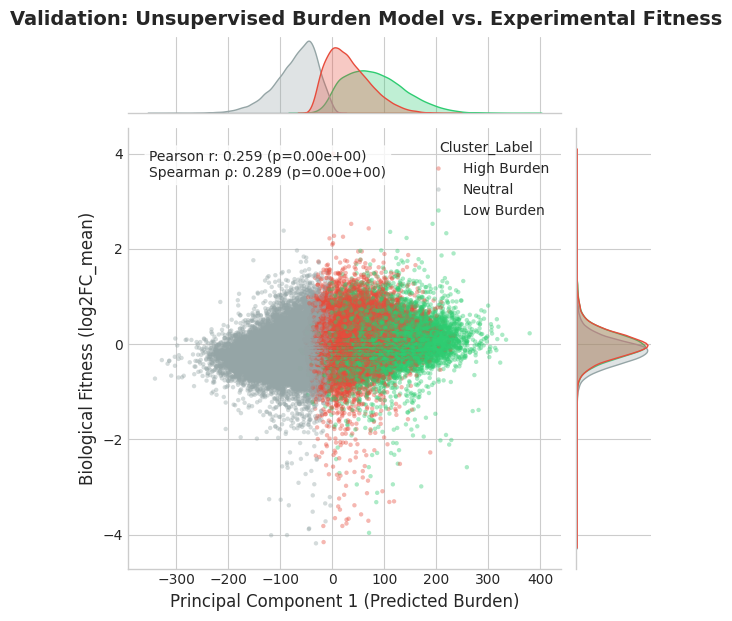

In [32]:
# @title Unsupervised Burden vs Experimental Fitness
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Map cluster numbers to meaningful biological labels
cluster_labels = {0: 'High Burden', 1: 'Low Burden', 2: 'Neutral'}
df_clean['Cluster_Label'] = df_clean['Cluster'].map(cluster_labels)

fitness_col = 'log2FC_mean'

print("Rendering Correlation Plot...")
sns.set_style("whitegrid")

g = sns.JointGrid(
    data=df_clean, x='PC1', y=fitness_col,
    hue='Cluster_Label',
    hue_order=['High Burden', 'Neutral', 'Low Burden'],
    palette={'High Burden': '#e74c3c', 'Neutral': '#95a5a6', 'Low Burden': '#2ecc71'}
)
g.plot_joint(sns.scatterplot, alpha=0.4, s=10, edgecolor='none')
g.plot_marginals(sns.kdeplot, fill=True, common_norm=False, alpha=0.3)

r_pearson, p_pearson = pearsonr(df_clean['PC1'], df_clean[fitness_col])
r_spearman, p_spearman = spearmanr(df_clean['PC1'], df_clean[fitness_col])

stats_text = (f"Pearson r: {r_pearson:.3f} (p={p_pearson:.2e})\n"
              f"Spearman ρ: {r_spearman:.3f} (p={p_spearman:.2e})")

g.ax_joint.text(0.05, 0.95, stats_text,
                transform=g.ax_joint.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

g.ax_joint.set_xlabel('Principal Component 1 (Predicted Burden)', fontsize=12)
g.ax_joint.set_ylabel('Biological Fitness (log2FC_mean)', fontsize=12)
plt.suptitle('Validation: Unsupervised Burden Model vs. Experimental Fitness',
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

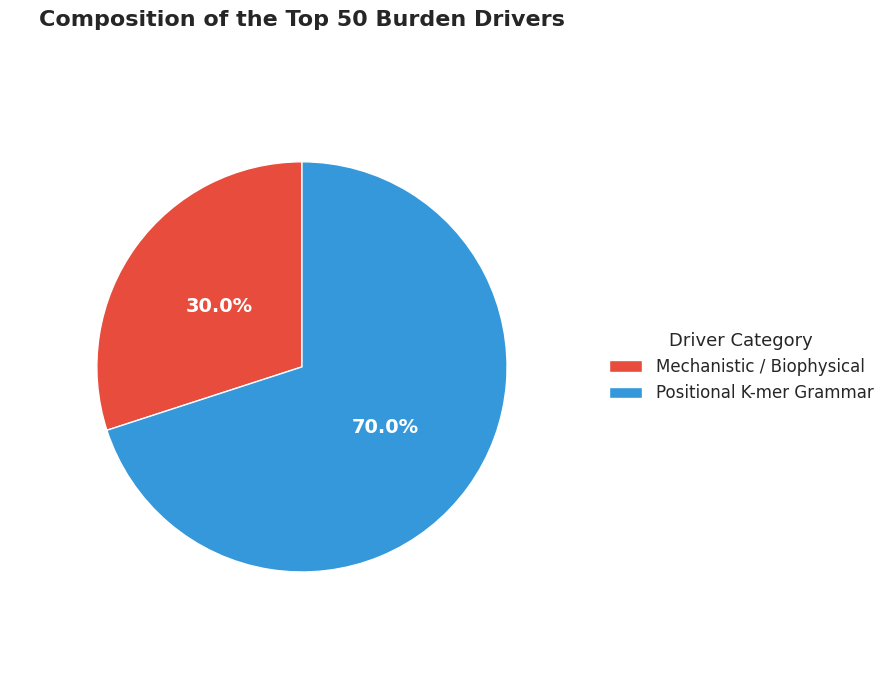


--- LAYMAN EXPLANATION ---
Out of the top 50 factors driving metabolic burden, 35 are positional k-mer motifs
and 15 are mechanistic biophysical features.

Note: only 18 biophysical features exist vs 768 k-mer features.
All 18 biophysical features appear in the top 50 (36% of slots).
By individual loading magnitude, the top drivers are typically mechanistic
(e.g., GC%, Entropy, AT_tract, Max_Homo, RBS_Str, Promoter_Str).
The pie chart reflects feature count in the top 50, not individual predictive weight.


In [38]:
# @title Mechanistic vs PCA Burden Drivers
import matplotlib.pyplot as plt

# 1. Look at the top 50 most important drivers
top_50 = motifs_df.head(50)

# 2. Count how many are Mechanistic vs Positional
mech_count = top_50['Motif'].isin(mech_feature_labels).sum()
kmer_count = 50 - mech_count

# 3. Create the Pie Chart
labels = ['Mechanistic / Biophysical', 'Positional K-mer Grammar']
sizes = [mech_count, kmer_count]
colors = ['#e74c3c', '#3498db'] # Red for Bio, Blue for Text

fig, ax = plt.subplots(figsize=(9, 7))

# Draw the pie chart (without direct labels attached to the pie)
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.5,
    textprops=dict(color="white", weight="bold", size=14) # Changed to white for better contrast
)

# 4. Add the Color Legend
ax.legend(
    wedges,
    labels,
    title="Driver Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5), # Places the legend neatly to the right of the pie
    fontsize=12,
    title_fontsize=13
)

# Formatting
ax.axis('equal')  # Ensures the pie is drawn as a perfect circle
plt.title('Composition of the Top 50 Burden Drivers', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout() # Ensures the legend doesn't get cut off

plt.show()

# 5. Executive Readout
print("\n--- LAYMAN EXPLANATION ---")
print(f"Out of the top 50 factors driving metabolic burden, {kmer_count} are positional k-mer motifs")
print(f"and {mech_count} are mechanistic biophysical features.")

# Safely check if feature_names exists to avoid a secondary NameError
total_kmers = len(feature_names) if 'feature_names' in globals() else "thousands of"

print(f"\nNote: only {len(mech_feature_labels)} biophysical features exist vs {total_kmers} k-mer features.")
print(f"All {len(mech_feature_labels)} biophysical features appear in the top 50 ({len(mech_feature_labels)/50*100:.0f}% of slots).")
print("By individual loading magnitude, the top drivers are typically mechanistic")
print("(e.g., GC%, Entropy, AT_tract, Max_Homo, RBS_Str, Promoter_Str).")
print("The pie chart reflects feature count in the top 50, not individual predictive weight.")

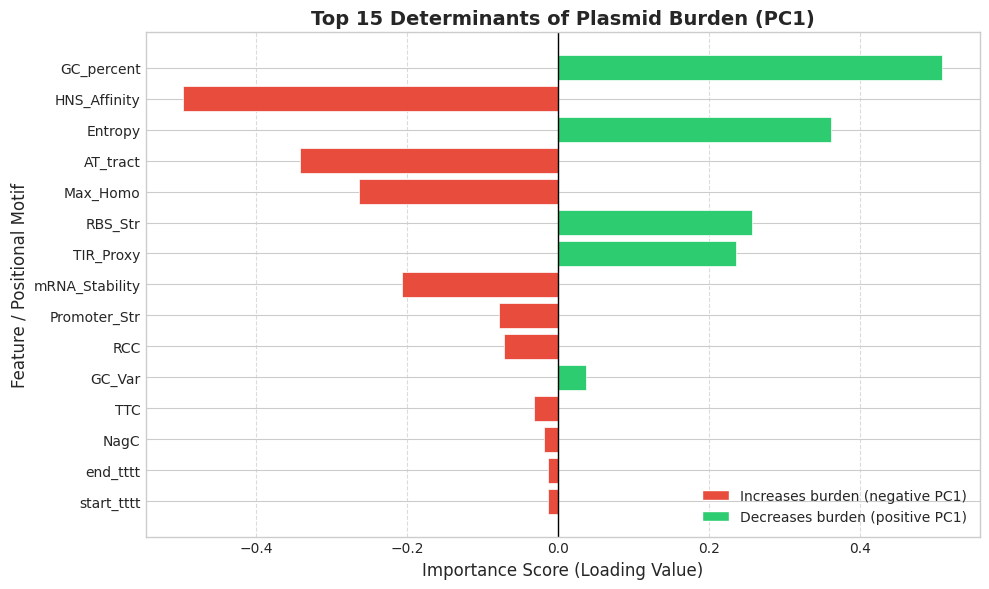

In [39]:
# @title Top 15 Determinants of Plasmid Burden (PCA+Mechanisms Combined)
import matplotlib.pyplot as plt
import seaborn as sns

top_plot = motifs_df.head(15).copy()
top_plot['Color'] = top_plot['Importance'].apply(lambda x: '#e74c3c' if x < 0 else '#2ecc71')

plt.figure(figsize=(10, 6))
bars = plt.barh(top_plot['Motif'][::-1], top_plot['Importance'][::-1],
                color=top_plot['Color'][::-1], edgecolor='white', linewidth=0.5)

plt.axvline(0, color='black', lw=1)
plt.title('Top 15 Determinants of Plasmid Burden (PC1)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Loading Value)', fontsize=12)
plt.ylabel('Feature / Positional Motif', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Increases burden (negative PC1)'),
                   Patch(facecolor='#2ecc71', label='Decreases burden (positive PC1)')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

DIAGNOSTIC STEP: LINEAR SEQUENCE BURDEN MAP


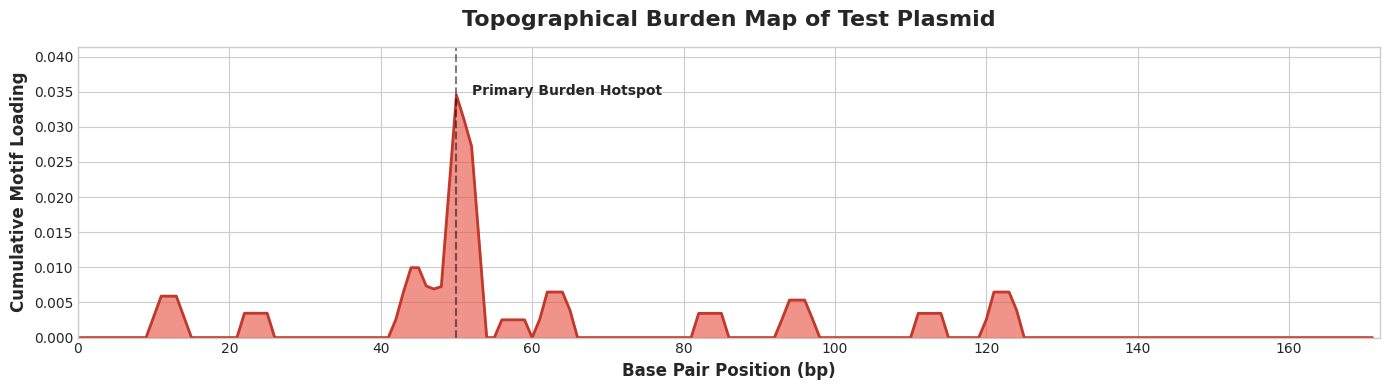


--- VISUALIZATION SUMMARY ---
This chart translates abstract PCA math directly onto the physical DNA string.
It highlights exactly where the sequence-based stress is concentrated, allowing for targeted edits.


In [40]:
# @title Topological Burden Map
import numpy as np
import matplotlib.pyplot as plt

print("DIAGNOSTIC STEP: LINEAR SEQUENCE BURDEN MAP")

# THE FIX: Calculate absolute importance on the fly before doing anything else
motifs_df['Abs_Importance'] = motifs_df['Importance'].abs()

# 1. Setup: We need the test sequence and the top k-mer drivers
seq_length = len(test_seq)
burden_profile = np.zeros(seq_length)

# Get the top 20 sequence motifs (excluding mechanistic features)
top_seq_drivers = motifs_df[~motifs_df['Motif'].isin(mech_feature_labels)].sort_values(by='Abs_Importance', ascending=False).head(20)

# 2. Map the burden onto the sequence
# We slide across the sequence, and if a 4-mer matches a top driver, we add its weight
k = 4
for i in range(seq_length - k + 1):
    current_kmer = test_seq[i:i+k].lower()

    # Check if this exact k-mer is in our top drivers
    match = top_seq_drivers[top_seq_drivers['Motif'].str.contains(current_kmer)]

    if not match.empty:
        # Add the absolute importance score to these specific base pairs
        weight = match['Abs_Importance'].values[0]
        burden_profile[i:i+k] += weight

# 3. Create the Visualization
fig, ax = plt.subplots(figsize=(14, 4))

# Plot the burden profile as a filled area
ax.fill_between(range(seq_length), burden_profile, color='#e74c3c', alpha=0.6, label='Localized Burden Score')
ax.plot(range(seq_length), burden_profile, color='#c0392b', linewidth=2)

# Highlight the "Danger Zone" (the highest peak)
max_burden_idx = np.argmax(burden_profile)
ax.axvline(max_burden_idx, color='black', linestyle='--', alpha=0.5)
ax.text(max_burden_idx + 2, max(burden_profile), 'Primary Burden Hotspot', fontweight='bold')

ax.set_xlim(0, seq_length)
ax.set_ylim(0, max(burden_profile) * 1.2) # Add some headroom
ax.set_title('Topographical Burden Map of Test Plasmid', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Base Pair Position (bp)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Motif Loading', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- VISUALIZATION SUMMARY ---")
print("This chart translates abstract PCA math directly onto the physical DNA string.")
print("It highlights exactly where the sequence-based stress is concentrated, allowing for targeted edits.")

In [41]:
# @title Phase 3a Validation Suite (Single Cell)
# ─────────────────────────────────────────────────────────────────────────────
# Runs six independent validation tests and stores all results in a single
# dict (VALIDATION_RESULTS) for the visualisation cell to consume.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr, ttest_ind, mannwhitneyu, ks_2samp
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix

# ── HARD DEPENDENCY CHECK ────────────────────────────────────────────────────
required = {
    'df_clean'          : 'Cell 1  — data ingestion',
    'svd'               : 'Cell 9  — TruncatedSVD',
    'X_combined'        : 'Cell 8  — fused matrix',
    'scaler'            : 'Cell 5  — StandardScaler',
    'vectorizer'        : 'Cell 5  — CountVectorizer',
    'mech_feature_labels': 'Cell 5  — biophysical labels',
    'get_positional_kmers': 'Cell 4  — k-mer tokeniser',
    'calculate_master_features': 'Cell 5  — biophysical calculator',
}
missing = [f"  '{k}' → run {v}" for k, v in required.items()
           if k not in globals()]
if missing:
    raise RuntimeError("Missing dependencies:\n" + "\n".join(missing))

VALIDATION_RESULTS = {}   # all tests write into this dict

print("=" * 70)
print("  VALIDATION SUITE — 6 TESTS")
print("=" * 70)


# ══════════════════════════════════════════════════════════════════════════════
# TEST 1 — Continuous correlation: PC1 vs log2FC_mean
# Primary result for the thesis. Non-parametric (Spearman) is the headline;
# Pearson is secondary because the relationship is unlikely to be linear.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[1/6] Continuous correlation — PC1 vs log2FC_mean")

rho,   p_spear = spearmanr(df_clean['PC1'], df_clean['log2FC_mean'])
r_pear, p_pear = pearsonr (df_clean['PC1'], df_clean['log2FC_mean'])

VALIDATION_RESULTS['correlation'] = dict(
    spearman_rho=rho,   spearman_p=p_spear,
    pearson_r=r_pear,   pearson_p=p_pear,
    n=len(df_clean),
)

print(f"  Spearman ρ = {rho:.4f}   (p = {p_spear:.2e})")
print(f"  Pearson  r = {r_pear:.4f}   (p = {p_pear:.2e})")
print(f"  n = {len(df_clean):,}")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 2 — Median-split group comparison: high-PC1 vs low-PC1 fitness
# Split on the population median (not a tail quantile) to avoid circularity.
# Welch's t  = parametric.   Mann-Whitney U = non-parametric backup.
# Cohen's d  = effect size.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[2/6] Median-split group comparison (Welch / MWU / Cohen's d)")

pc1_med     = df_clean['PC1'].median()
high_pc1    = df_clean['PC1'] >= pc1_med
low_pc1     = df_clean['PC1'] <  pc1_med
fit_high    = df_clean.loc[high_pc1, 'log2FC_mean']
fit_low     = df_clean.loc[low_pc1,  'log2FC_mean']

t_stat, t_p = ttest_ind(fit_high, fit_low, equal_var=False)
u_stat, u_p = mannwhitneyu(fit_high, fit_low, alternative='greater')

mean_diff   = fit_high.mean() - fit_low.mean()
pooled_std  = np.sqrt((fit_high.var() + fit_low.var()) / 2)
cohens_d    = mean_diff / pooled_std

def d_label(d):
    a = abs(d)
    return 'small' if a < 0.5 else 'medium' if a < 0.8 else 'large'

VALIDATION_RESULTS['group_comparison'] = dict(
    pc1_median=pc1_med,
    n_high=int(high_pc1.sum()), n_low=int(low_pc1.sum()),
    mean_fit_high=fit_high.mean(), mean_fit_low=fit_low.mean(),
    t_stat=t_stat, t_p=t_p,
    u_stat=u_stat, u_p=u_p,
    cohens_d=cohens_d,
)

print(f"  Split at PC1 median = {pc1_med:.3f}")
print(f"  High-PC1 mean fitness = {fit_high.mean():.4f}  (n={high_pc1.sum():,})")
print(f"  Low-PC1  mean fitness = {fit_low.mean():.4f}  (n={low_pc1.sum():,})")
print(f"  Welch t = {t_stat:.3f}, p = {t_p:.2e}")
print(f"  Mann-Whitney U p = {u_p:.2e}")
print(f"  Cohen's d = {cohens_d:.4f}  ({d_label(cohens_d)} effect)")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 3 — Permutation test on Cohen's d
# Shuffles log2FC labels 1,000 times to build a null distribution of Cohen's d.
# Observed d is computed from the current data (never hardcoded).
# ══════════════════════════════════════════════════════════════════════════════
print("\n[3/6] Permutation test on Cohen's d (n_perm = 1,000)")

np.random.seed(42)
N_PERM        = 1_000
fitness_vals  = df_clean['log2FC_mean'].values.copy()
high_mask     = high_pc1.values

null_d = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled  = np.random.permutation(fitness_vals)
    h_vals    = shuffled[high_mask]
    l_vals    = shuffled[~high_mask]
    m_diff    = h_vals.mean() - l_vals.mean()
    p_std     = np.sqrt((h_vals.var() + l_vals.var()) / 2)
    null_d[i] = m_diff / p_std if p_std > 0 else 0.0

p_perm = (np.abs(null_d) >= np.abs(cohens_d)).mean()

VALIDATION_RESULTS['permutation'] = dict(
    observed_d=cohens_d,
    null_mean=null_d.mean(),
    null_std=null_d.std(),
    p_perm=p_perm,
    z_vs_null=(cohens_d - null_d.mean()) / null_d.std(),
    null_d=null_d,
)

print(f"  Observed Cohen's d : {cohens_d:.4f}")
print(f"  Null distribution  : mean = {null_d.mean():.5f}, std = {null_d.std():.5f}")
print(f"  Permutation p      : {p_perm:.4f}")
print(f"  Z vs null          : {VALIDATION_RESULTS['permutation']['z_vs_null']:.2f} SD")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 4 — Stratified rank-order validation (15 sequences)
# 5 lowest + 5 median + 5 highest fitness.
# Tests whether a binary BURDEN / NEUTRAL / INERT zone prediction from PC1
# correctly orders sequences by ground-truth fitness tier.
# Accuracy is computed on the 5+5 extreme sequences only (median is expected
# to be ambiguous — this is stated explicitly, not hidden).
# ══════════════════════════════════════════════════════════════════════════════
print("\n[4/6] Stratified rank-order validation (n = 15)")

np.random.seed(42)

worst  = df_clean.nsmallest(5, 'log2FC_mean').copy()
best   = df_clean.nlargest(5,  'log2FC_mean').copy()
med_pool = df_clean[df_clean['log2FC_mean'].between(
    df_clean['log2FC_mean'].quantile(0.45),
    df_clean['log2FC_mean'].quantile(0.55)
)]
median = med_pool.sample(5, random_state=42).copy()
val_set = pd.concat([worst, median, best]).reset_index(drop=True)

burden_thr = df_clean['PC1'].quantile(0.25)
inert_thr  = df_clean['PC1'].quantile(0.75)

val_set['pred_zone'] = val_set['PC1'].apply(
    lambda x: 'BURDEN' if x < burden_thr else ('INERT' if x > inert_thr else 'NEUTRAL')
)
val_set['true_tier'] = ['LOW'] * 5 + ['MID'] * 5 + ['HIGH'] * 5

extremes   = val_set.iloc[list(range(5)) + list(range(10, 15))]
pred_match = (
    ((extremes['true_tier'] == 'LOW')  & (extremes['pred_zone'] == 'BURDEN')) |
    ((extremes['true_tier'] == 'HIGH') & (extremes['pred_zone'] == 'INERT'))
)
accuracy = pred_match.mean()

VALIDATION_RESULTS['stratified'] = dict(
    val_set=val_set,
    burden_thr=burden_thr,
    inert_thr=inert_thr,
    extreme_accuracy=accuracy,
)

print(val_set[['log2FC_mean', 'PC1', 'true_tier', 'pred_zone']].to_string())
print(f"\n  Extreme-sequence accuracy: {pred_match.sum()}/10 ({accuracy*100:.0f}%)")
print("  (Median tier expected to be ambiguous — excluded from accuracy score)")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 5 — Null hypothesis test (random DNA vs real library in PC1 space)
# Generates 1,000 random 172 bp sequences, projects them through the REAL
# vectorizer + scaler + SVD (not a fresh fit), then compares the PC1
# distributions with a KS test.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[5/6] Null hypothesis — random DNA projected into real PC1 space")

np.random.seed(99)
N_NULL    = 1_000
SEQ_LEN   = 172
null_seqs = [''.join(np.random.choice(list('ATGC'), size=SEQ_LEN))
             for _ in range(N_NULL)]

null_kmers  = [get_positional_kmers(s, k=4) for s in null_seqs]
X_null_sp   = vectorizer.transform(null_kmers)

null_bio_raw = [calculate_master_features(s) for s in null_seqs]
null_bio_df  = pd.DataFrame(null_bio_raw, columns=mech_feature_labels)
X_null_mech  = scaler.transform(null_bio_df)

scale_factor    = X_null_sp.shape[1] / X_null_mech.shape[1]
X_null_mech_rw  = X_null_mech * scale_factor
X_null_combined = hstack([X_null_sp, csr_matrix(X_null_mech_rw)])

null_pc1 = svd.transform(X_null_combined)[:, 0]

ks_stat, ks_p = ks_2samp(df_clean['PC1'], null_pc1)

VALIDATION_RESULTS['null_test'] = dict(
    null_pc1=null_pc1,
    null_mean=null_pc1.mean(),
    null_std=null_pc1.std(),
    real_mean=df_clean['PC1'].mean(),
    real_std=df_clean['PC1'].std(),
    ks_stat=ks_stat,
    ks_p=ks_p,
    n_null=N_NULL,
)

print(f"  Real library PC1 : mean = {df_clean['PC1'].mean():.3f}, "
      f"std = {df_clean['PC1'].std():.3f}")
print(f"  Random DNA PC1   : mean = {null_pc1.mean():.3f}, "
      f"std = {null_pc1.std():.3f}")
print(f"  KS statistic = {ks_stat:.4f},  p = {ks_p:.2e}")


# ══════════════════════════════════════════════════════════════════════════════
# TEST 6 — Per-feature Mann-Whitney U: each biophysical feature vs fitness
# Tests whether each of the 18 features individually separates low from high
# fitness. Corrects for multiple comparisons with Bonferroni.
# Identifies which features carry statistically independent signal.
# ══════════════════════════════════════════════════════════════════════════════
print("\n[6/6] Per-feature Mann-Whitney U (Bonferroni corrected)")

low_fit  = df_clean['log2FC_mean'] < df_clean['log2FC_mean'].quantile(0.25)
high_fit = df_clean['log2FC_mean'] > df_clean['log2FC_mean'].quantile(0.75)

feature_stats = []
for feat in mech_feature_labels:
    low_vals  = df_clean.loc[low_fit,  feat]
    high_vals = df_clean.loc[high_fit, feat]
    _, p_raw  = mannwhitneyu(low_vals, high_vals, alternative='two-sided')
    md        = low_vals.mean() - high_vals.mean()
    ps        = np.sqrt((low_vals.var() + high_vals.var()) / 2)
    d         = md / ps if ps > 0 else 0.0
    feature_stats.append(dict(feature=feat, p_raw=p_raw,
                               p_bonf=min(p_raw * len(mech_feature_labels), 1.0),
                               cohens_d=d))

feat_df = (pd.DataFrame(feature_stats)
             .sort_values('p_bonf')
             .reset_index(drop=True))

VALIDATION_RESULTS['feature_mwu'] = dict(feat_df=feat_df)

sig = feat_df[feat_df['p_bonf'] < 0.05]
print(f"  {len(sig)}/{len(mech_feature_labels)} features significant after Bonferroni correction:")
print(feat_df[['feature', 'p_bonf', 'cohens_d']].to_string(index=False))


# ── FINAL SUMMARY ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  VALIDATION COMPLETE — RESULTS STORED IN VALIDATION_RESULTS")
print("=" * 70)
cr = VALIDATION_RESULTS['correlation']
gc = VALIDATION_RESULTS['group_comparison']
pm = VALIDATION_RESULTS['permutation']
nt = VALIDATION_RESULTS['null_test']
sr = VALIDATION_RESULTS['stratified']

print(f"  [1] Spearman ρ = {cr['spearman_rho']:.4f} (p = {cr['spearman_p']:.2e})")
print(f"  [2] Cohen's d = {gc['cohens_d']:.4f}  ({d_label(gc['cohens_d'])} effect)")
print(f"  [3] Permutation p = {pm['p_perm']:.4f}")
print(f"  [4] Rank-order accuracy = {sr['extreme_accuracy']*100:.0f}% (extremes only)")
print(f"  [5] KS (real vs random) p = {nt['ks_p']:.2e}")
sig_n = len(VALIDATION_RESULTS['feature_mwu']['feat_df']
            [VALIDATION_RESULTS['feature_mwu']['feat_df']['p_bonf'] < 0.05])
print(f"  [6] {sig_n}/{len(mech_feature_labels)} features survive Bonferroni correction")
print("=" * 70)
print("  Run the Validation Visualisation cell next.")

  VALIDATION SUITE — 6 TESTS

[1/6] Continuous correlation — PC1 vs log2FC_mean
  Spearman ρ = 0.2893   (p = 0.00e+00)
  Pearson  r = 0.2591   (p = 0.00e+00)
  n = 118,084

[2/6] Median-split group comparison (Welch / MWU / Cohen's d)
  Split at PC1 median = -2.560
  High-PC1 mean fitness = 0.0066  (n=59,042)
  Low-PC1  mean fitness = -0.1350  (n=59,042)
  Welch t = 73.521, p = 0.00e+00
  Mann-Whitney U p = 0.00e+00
  Cohen's d = 0.4279  (small effect)

[3/6] Permutation test on Cohen's d (n_perm = 1,000)
  Observed Cohen's d : 0.4279
  Null distribution  : mean = 0.00003, std = 0.00595
  Permutation p      : 0.0000
  Z vs null          : 71.88 SD

[4/6] Stratified rank-order validation (n = 15)
    log2FC_mean         PC1 true_tier pred_zone
0     -4.181407  -31.483378       LOW   NEUTRAL
1     -4.155979  -16.805446       LOW   NEUTRAL
2     -4.012421 -117.677383       LOW    BURDEN
3     -4.008691  -87.195012       LOW    BURDEN
4     -3.961941   70.580998       LOW     INERT
5     -

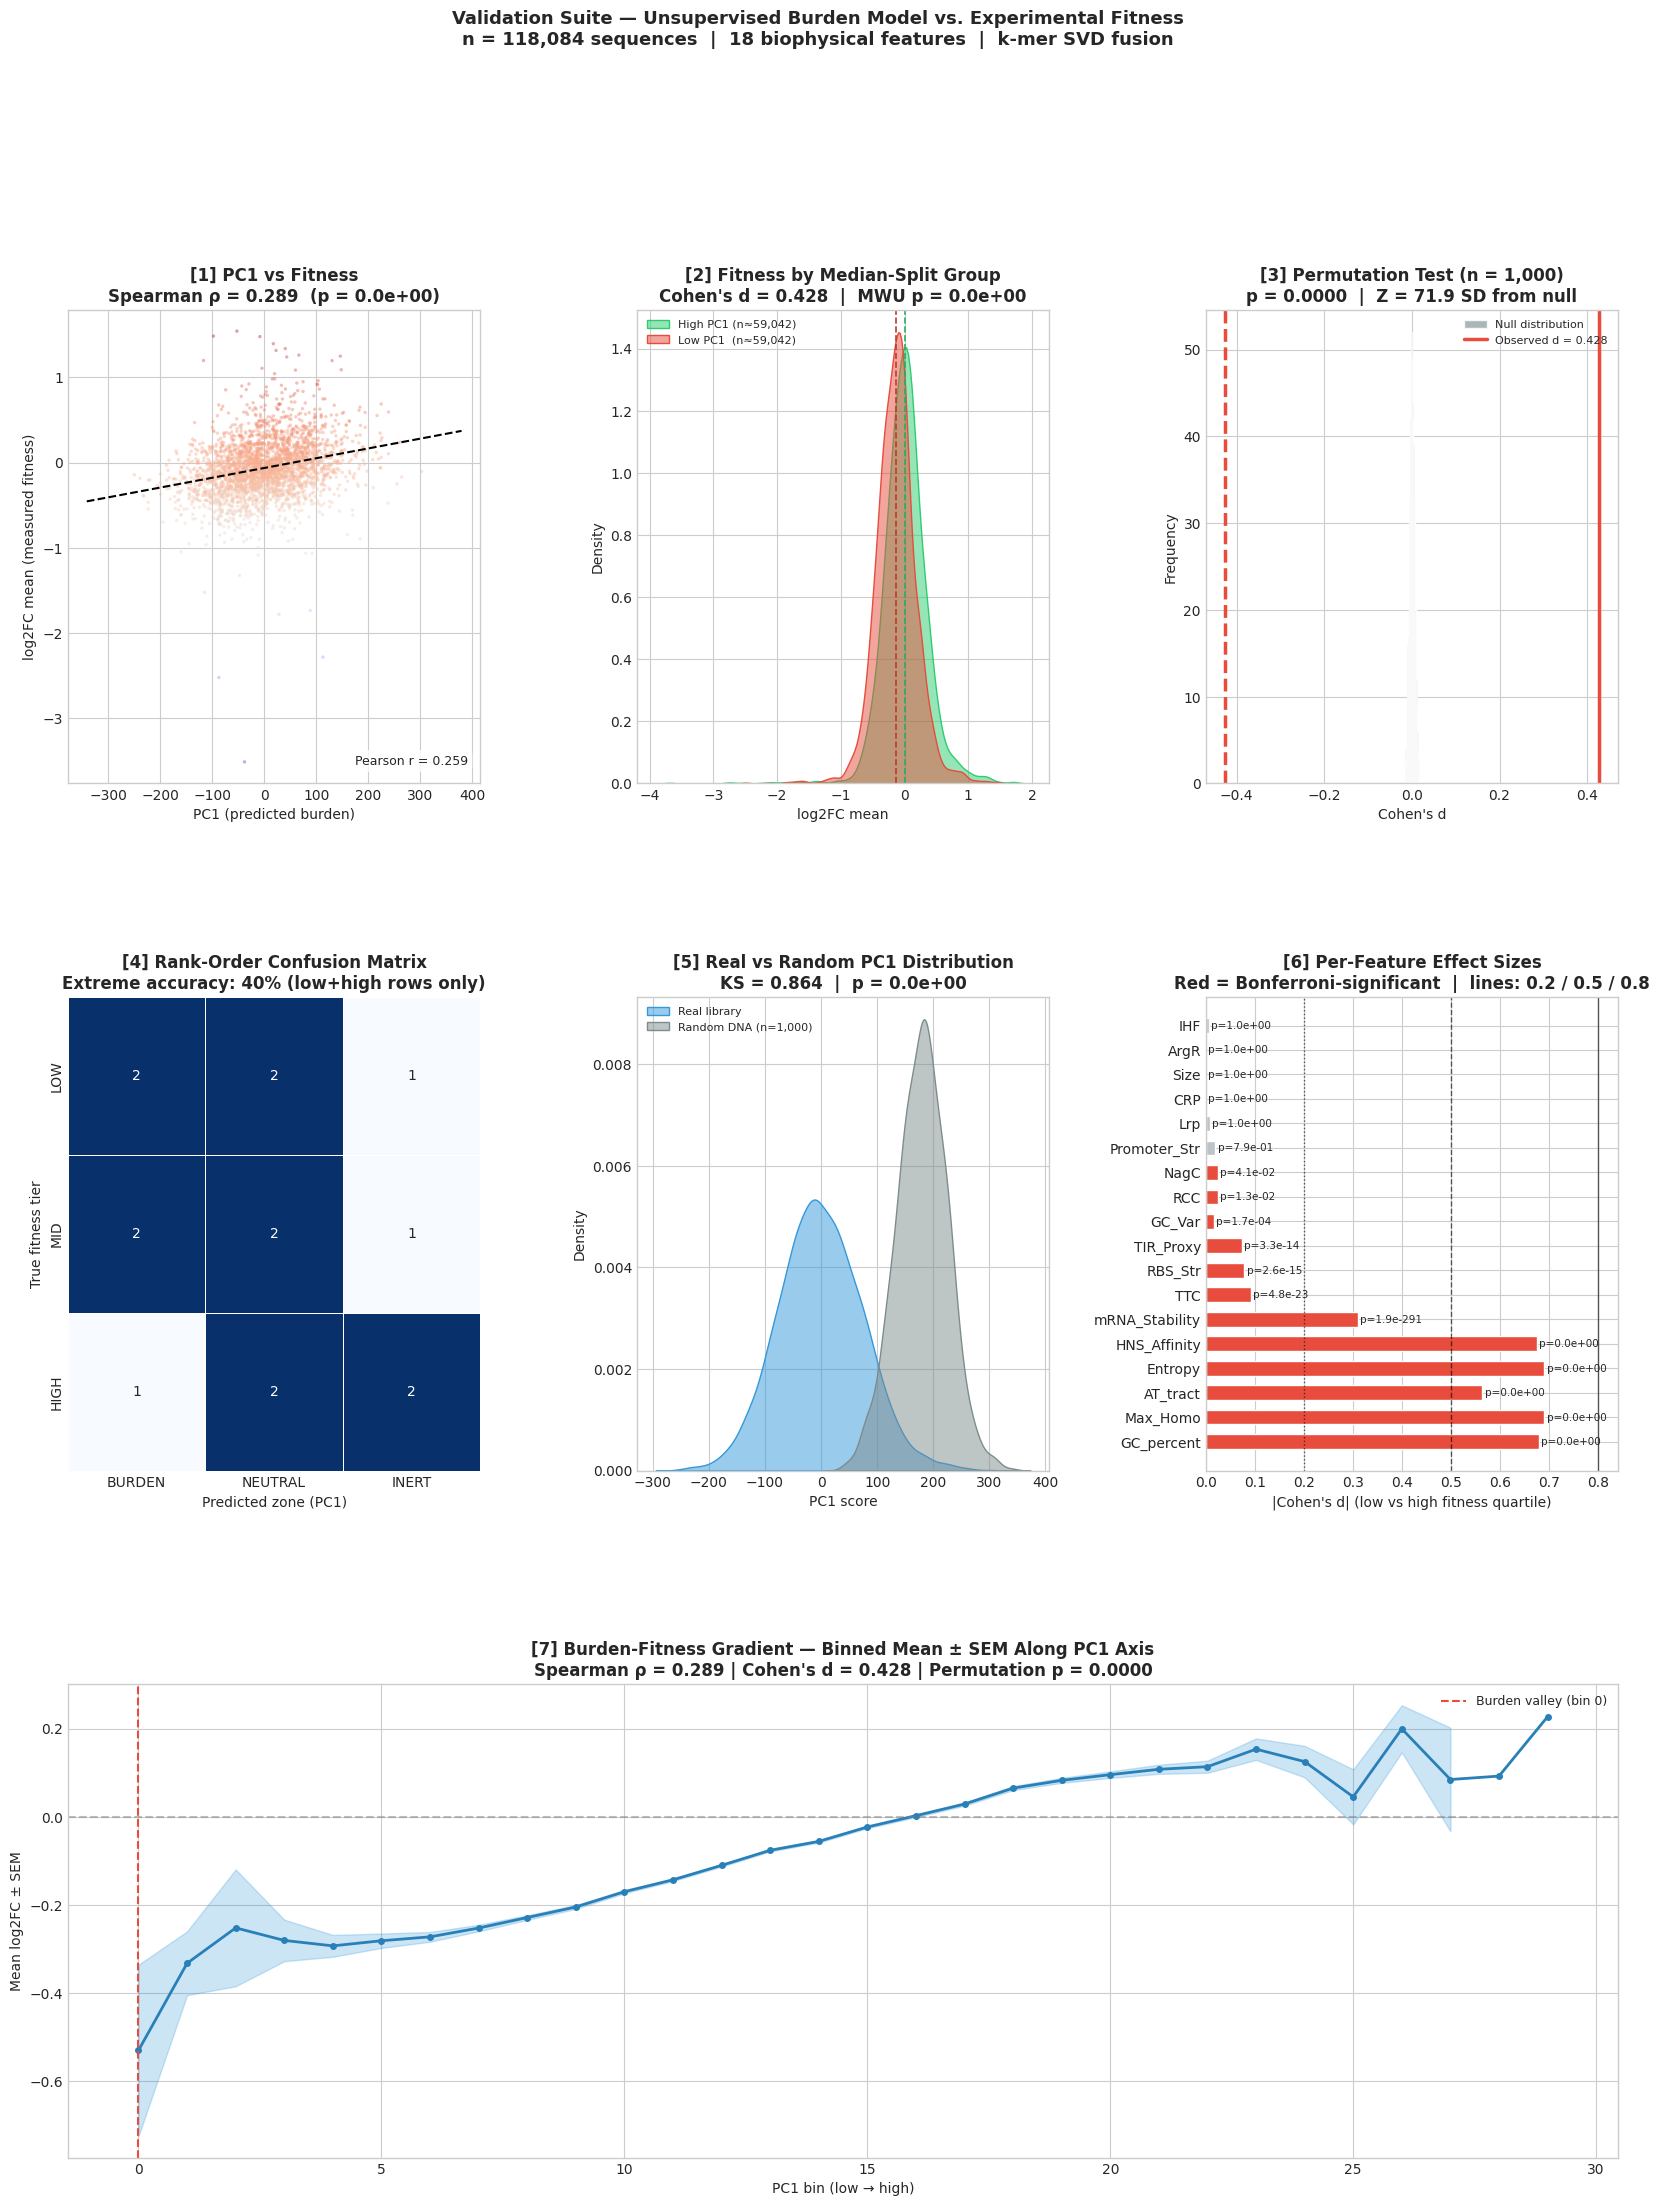

✅ Figure saved as validation_suite.png


In [42]:
# @title Phase 3b Validation Visualisation
# ─────────────────────────────────────────────────────────────────────────────
# Reads from VALIDATION_RESULTS produced by the Validation Suite cell.
# All scatter/scatter-based plots use a small random sample to avoid
# crashing Colab. KDE and bar charts operate on summary statistics only.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

if 'VALIDATION_RESULTS' not in globals():
    raise RuntimeError("Run the Validation Suite cell first.")

VR   = VALIDATION_RESULTS
cr   = VR['correlation']
gc   = VR['group_comparison']
pm   = VR['permutation']
sr   = VR['stratified']
nt   = VR['null_test']
fd   = VR['feature_mwu']['feat_df']

SCATTER_N = 3_000          # points shown on scatter plots
SAMPLE_SEED = 42

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10})

fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, :])


# ── PLOT 1 — PC1 vs log2FC_mean scatter (sampled) ────────────────────────────
samp = df_clean.sample(n=min(SCATTER_N, len(df_clean)), random_state=SAMPLE_SEED)

ax1.scatter(samp['PC1'], samp['log2FC_mean'],
            c=samp['log2FC_mean'], cmap='coolwarm',
            s=6, alpha=0.4, linewidths=0)

# Regression line through the full dataset (cheap: just two-point summary)
m, b = np.polyfit(df_clean['PC1'], df_clean['log2FC_mean'], 1)
x_line = np.array([df_clean['PC1'].min(), df_clean['PC1'].max()])
ax1.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

ax1.set_xlabel('PC1 (predicted burden)')
ax1.set_ylabel('log2FC mean (measured fitness)')
ax1.set_title(
    f'[1] PC1 vs Fitness\n'
    f'Spearman ρ = {cr["spearman_rho"]:.3f}  '
    f'(p = {cr["spearman_p"]:.1e})',
    fontweight='bold'
)
ax1.text(0.97, 0.04,
         f'Pearson r = {cr["pearson_r"]:.3f}',
         transform=ax1.transAxes,
         ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# ── PLOT 2 — Fitness KDE by median-split group ────────────────────────────────
pc1_med  = gc['pc1_median']
high_smp = df_clean.loc[df_clean['PC1'] >= pc1_med, 'log2FC_mean'].sample(
               n=min(SCATTER_N, (df_clean['PC1'] >= pc1_med).sum()),
               random_state=SAMPLE_SEED)
low_smp  = df_clean.loc[df_clean['PC1'] < pc1_med, 'log2FC_mean'].sample(
               n=min(SCATTER_N, (df_clean['PC1'] < pc1_med).sum()),
               random_state=SAMPLE_SEED)

sns.kdeplot(high_smp, ax=ax2, fill=True, color='#2ecc71', alpha=0.5,
            label=f'High PC1 (n≈{gc["n_high"]:,})')
sns.kdeplot(low_smp,  ax=ax2, fill=True, color='#e74c3c', alpha=0.5,
            label=f'Low PC1  (n≈{gc["n_low"]:,})')
ax2.axvline(gc['mean_fit_high'], color='#27ae60', linestyle='--', linewidth=1.2)
ax2.axvline(gc['mean_fit_low'],  color='#c0392b', linestyle='--', linewidth=1.2)
ax2.set_xlabel('log2FC mean')
ax2.set_ylabel('Density')
ax2.set_title(
    f'[2] Fitness by Median-Split Group\n'
    f"Cohen's d = {gc['cohens_d']:.3f}  |  MWU p = {gc['u_p']:.1e}",
    fontweight='bold'
)
ax2.legend(fontsize=8)


# ── PLOT 3 — Permutation test: null distribution of Cohen's d ─────────────────
null_d = pm['null_d']
obs_d  = pm['observed_d']

ax3.hist(null_d, bins=50, color='#95a5a6', edgecolor='white', alpha=0.8,
         label='Null distribution')
ax3.axvline(obs_d, color='#e74c3c', linewidth=2.5, label=f'Observed d = {obs_d:.3f}')
ax3.axvline(-abs(obs_d), color='#e74c3c', linewidth=2.5, linestyle='--')

ax3.set_xlabel("Cohen's d")
ax3.set_ylabel('Frequency')
ax3.set_title(
    f"[3] Permutation Test (n = {len(null_d):,})\n"
    f"p = {pm['p_perm']:.4f}  |  "
    f"Z = {pm['z_vs_null']:.1f} SD from null",
    fontweight='bold'
)
ax3.legend(fontsize=8)


# ── PLOT 4 — Stratified rank-order validation heatmap ────────────────────────
val_set = sr['val_set']

zone_order = ['BURDEN', 'NEUTRAL', 'INERT']
tier_order = ['LOW', 'MID', 'HIGH']

cm_data = pd.crosstab(val_set['true_tier'], val_set['pred_zone'])
cm_data = cm_data.reindex(index=tier_order, columns=zone_order, fill_value=0)

sns.heatmap(cm_data, ax=ax4, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar=False,
            xticklabels=zone_order, yticklabels=tier_order)
ax4.set_xlabel('Predicted zone (PC1)')
ax4.set_ylabel('True fitness tier')
ax4.set_title(
    f'[4] Rank-Order Confusion Matrix\n'
    f'Extreme accuracy: {sr["extreme_accuracy"]*100:.0f}% (low+high rows only)',
    fontweight='bold'
)


# ── PLOT 5 — Null test: real vs random PC1 distributions ─────────────────────
real_smp = df_clean['PC1'].sample(n=min(SCATTER_N, len(df_clean)),
                                   random_state=SAMPLE_SEED)

sns.kdeplot(real_smp,       ax=ax5, fill=True, color='#3498db',
            alpha=0.5, label='Real library')
sns.kdeplot(nt['null_pc1'], ax=ax5, fill=True, color='#7f8c8d',
            alpha=0.5, label='Random DNA (n=1,000)')
ax5.set_xlabel('PC1 score')
ax5.set_ylabel('Density')
ax5.set_title(
    f'[5] Real vs Random PC1 Distribution\n'
    f"KS = {nt['ks_stat']:.3f}  |  p = {nt['ks_p']:.1e}",
    fontweight='bold'
)
ax5.legend(fontsize=8)


# ── PLOT 6 — Per-feature Cohen's d (Bonferroni-corrected significance) ────────
colors_bar = ['#e74c3c' if p < 0.05 else '#bdc3c7' for p in fd['p_bonf']]
bars = ax6.barh(fd['feature'], fd['cohens_d'].abs(),
                color=colors_bar, edgecolor='white', height=0.6)
ax6.axvline(0.2, color='black', linestyle=':', linewidth=1, alpha=0.6)
ax6.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax6.axvline(0.8, color='black', linestyle='-',  linewidth=1, alpha=0.6)
ax6.set_xlabel("|Cohen's d| (low vs high fitness quartile)")
ax6.set_title(
    "[6] Per-Feature Effect Sizes\n"
    "Red = Bonferroni-significant  |  lines: 0.2 / 0.5 / 0.8",
    fontweight='bold'
)

for bar, row in zip(bars, fd.itertuples()):
    ax6.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f"p={row.p_bonf:.1e}", va='center', fontsize=7.5)


# ── PLOT 7 — PC1 gradient: binned mean fitness with SEM (full data, no scatter)
N_BINS = 30
df_clean['pc1_bin'] = pd.cut(df_clean['PC1'], bins=N_BINS, labels=False)
binned = (df_clean.groupby('pc1_bin', observed=True)['log2FC_mean']
          .agg(['mean', 'std', 'count'])
          .reset_index())
binned['sem'] = binned['std'] / np.sqrt(binned['count'])

ax7.fill_between(binned['pc1_bin'],
                 binned['mean'] - binned['sem'],
                 binned['mean'] + binned['sem'],
                 alpha=0.25, color='#3498db')
ax7.plot(binned['pc1_bin'], binned['mean'],
         color='#2980b9', linewidth=2, marker='o', markersize=4)
ax7.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Mark the burden valley
worst_bin = binned.loc[binned['mean'].idxmin(), 'pc1_bin']
ax7.axvline(worst_bin, color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f'Burden valley (bin {worst_bin})')
ax7.set_xlabel('PC1 bin (low → high)')
ax7.set_ylabel('Mean log2FC ± SEM')
ax7.set_title(
    '[7] Burden-Fitness Gradient — Binned Mean ± SEM Along PC1 Axis\n'
    f'Spearman ρ = {cr["spearman_rho"]:.3f} | '
    f"Cohen's d = {gc['cohens_d']:.3f} | "
    f"Permutation p = {pm['p_perm']:.4f}",
    fontweight='bold'
)
ax7.legend(fontsize=9)
df_clean.drop(columns=['pc1_bin'], inplace=True)


# ── MASTER TITLE ──────────────────────────────────────────────────────────────
fig.suptitle(
    'Validation Suite — Unsupervised Burden Model vs. Experimental Fitness\n'
    f'n = {cr["n"]:,} sequences  |  {len(mech_feature_labels)} biophysical features  |  '
    f'k-mer SVD fusion',
    fontsize=13, fontweight='bold', y=1.005
)

plt.savefig('validation_suite.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as validation_suite.png")

In [43]:
# @title Scaling Method Comparison
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from scipy.stats import spearmanr
import pandas as pd

# --- Standard scaling (z-score) — already done in Cell 5 ---
# Re-derive feature importances from the existing SVD
importances_standard = svd.components_[0][-len(mech_feature_labels):]

# --- MinMax scaling alternative ---
mm_scaler = MinMaxScaler()
X_mech_minmax = mm_scaler.fit_transform(df_clean[mech_feature_labels])

scale_factor_mm = X_sparse.shape[1] / len(mech_feature_labels)
X_mech_minmax_rw = X_mech_minmax * scale_factor_mm

from scipy.sparse import hstack, csr_matrix
X_combined_mm = hstack([X_sparse, csr_matrix(X_mech_minmax_rw)])

svd_mm = TruncatedSVD(n_components=2, random_state=42)
X_reduced_mm = svd_mm.fit_transform(X_combined_mm)
importances_minmax = svd_mm.components_[0][-len(mech_feature_labels):]

rho_std, _ = spearmanr(X_reduced_mm[:, 0], df_clean['log2FC_mean'])
print(f"MinMax PC1 Spearman ρ vs fitness: {rho_std:.4f}")
print(f"Standard PC1 Spearman ρ vs fitness: {VALIDATION_RESULTS['correlation']['spearman_rho']:.4f}")

comparison_df = pd.DataFrame({
    'Motif'               : mech_feature_labels,
    'Importance_Standard' : importances_standard,
    'Importance_MinMax'   : importances_minmax,
})

print(comparison_df.to_string(index=False))

MinMax PC1 Spearman ρ vs fitness: -0.0313
Standard PC1 Spearman ρ vs fitness: 0.2893
         Motif  Importance_Standard  Importance_MinMax
          Size             0.000000           0.000000
    GC_percent             0.508311           0.299252
        GC_Var             0.036727           0.084374
      Max_Homo            -0.263569           0.122135
       Entropy             0.361546           0.525187
      AT_tract            -0.341168           0.179578
  Promoter_Str            -0.077983           0.036398
       RBS_Str             0.256520           0.065312
           IHF            -0.012341           0.002204
           Lrp            -0.008646           0.004758
           CRP             0.001073           0.000046
          NagC            -0.017999           0.007743
          ArgR            -0.001496           0.000020
  HNS_Affinity            -0.495743           0.393880
           TTC            -0.032296           0.558934
           RCC            -0.071920

In [44]:
#@title Features with Largest Divergence
# Which features show the biggest divergence between scaling methods?
comparison_df['divergence'] = (
    comparison_df['Importance_MinMax'] - comparison_df['Importance_Standard']
).abs()
print(comparison_df.nlargest(10, 'divergence')[['Motif', 'Importance_Standard',
                                                  'Importance_MinMax', 'divergence']])

             Motif  Importance_Standard  Importance_MinMax  divergence
13    HNS_Affinity            -0.495743           0.393880    0.889623
14             TTC            -0.032296           0.558934    0.591229
5         AT_tract            -0.341168           0.179578    0.520746
17  mRNA_Stability            -0.206761           0.189162    0.395923
3         Max_Homo            -0.263569           0.122135    0.385705
15             RCC            -0.071920           0.187137    0.259058
1       GC_percent             0.508311           0.299252    0.209059
7          RBS_Str             0.256520           0.065312    0.191208
16       TIR_Proxy             0.235952           0.051421    0.184532
4          Entropy             0.361546           0.525187    0.163641


In [45]:
# @title Top 6 Ranker
# Confirm top 6 rank order is preserved
top6_standard = comparison_df.nlargest(6, 'Importance_Standard')['Motif'].tolist()
top6_minmax = comparison_df.nlargest(6, 'Importance_MinMax')['Motif'].tolist()
print(f"Top 6 Standard: {top6_standard}")
print(f"Top 6 MinMax:   {top6_minmax}")
print(f"Same features: {set(top6_standard) == set(top6_minmax)}")

Top 6 Standard: ['GC_percent', 'Entropy', 'RBS_Str', 'TIR_Proxy', 'GC_Var', 'CRP']
Top 6 MinMax:   ['TTC', 'Entropy', 'HNS_Affinity', 'GC_percent', 'mRNA_Stability', 'RCC']
Same features: False


/tmp/ipykernel_65508/2533053878.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(per_decile, len(g)), random_state=42))
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Fit sample: 20,000 sequences (stratified across 10 fitness deciles)
  Fitting UMAP on 20k subsample (~2–3 min)…
  Fit complete. Transforming full 124k population…
  Embedding shape: (118084, 2)
  ↳ Test sequence → (6.377, 3.024)

  Neighbourhood overlap: 2/50 (4.0%) shared between 2D and 18D space


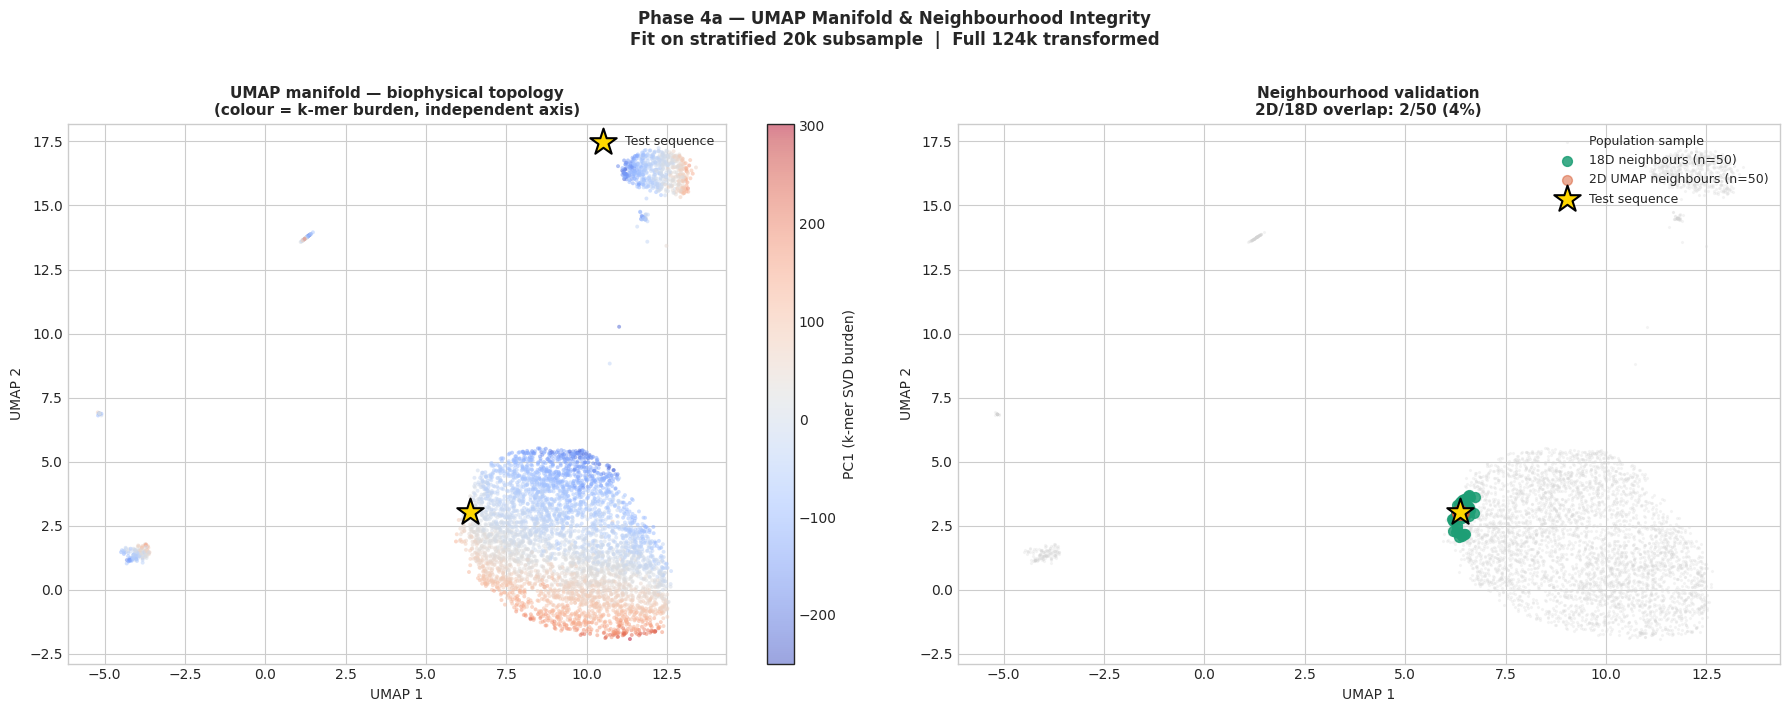


  PHASE 4a — TOPOLOGICAL DIAGNOSTIC
  Sequence        : AAGCAAAATTGGGGGCGTGTGCTTATCTTG… (172 bp)
  UMAP coords     : (6.377, 3.024)
  Fit method      : stratified 20k subsample → transform(124k)
  Population PC1  : mean = -0.147, std = 76.280

  ── Primary inference (18D raw space) ──────────────────────────
     Neighbourhood PC1 : 16.533
     Z-score           : +0.22 SD
     Conclusion        : NEUTRAL TOPOLOGY (core population)

  ── Secondary (2D UMAP space) ──────────────────────────────────
     Neighbourhood PC1 : 22.116
     Z-score           : +0.29 SD
     Conclusion        : NEUTRAL TOPOLOGY (core population)

  ── Neighbourhood integrity ─────────────────────────────────────
     Overlap: 2/50 (4.0%) — UMAP neighbourhood unreliable — rely on 18D result only.


In [46]:
# @title Advanced Analysis Phase 4a: UMAP Manifold (fast — subsample Fit)
# ─────────────────────────────────────────────────────────────────────────────
# METHODS NOTE (thesis):
#   UMAP is fitted on a stratified 20k subsample of X_mech_scaled (13
#   biophysical features), then transform() is called on the full 124k
#   population. Stratification ensures the fit sample covers the full
#   fitness distribution rather than being biased toward the modal region.
#   PC1 (k-mer SVD burden score) is used as an independent colour overlay
#   to test whether sequence-grammar burden co-localises with biophysical
#   risk regions — a hypothesis, not a design assumption baked into the
#   manifold geometry.
#   Runtime: ~3–5 min (vs ~20 min for a full fit).
# ─────────────────────────────────────────────────────────────────────────────

import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

# ── HARD DEPENDENCY CHECK ─────────────────────────────────────────────────────
required = {
    'df_clean'               : 'Cell 1  — data ingestion',
    'X_mech_scaled'          : 'Cell 5  — StandardScaler output',
    'scaler'                 : 'Cell 5  — fitted StandardScaler',
    'mech_feature_labels'    : 'Cell 5  — biophysical feature list',
    'calculate_master_features': 'Cell 5  — biophysical calculator',
    'svd'                    : 'Cell 9  — fitted TruncatedSVD',
}
missing = [f"  '{k}' → run {v}" for k, v in required.items()
           if k not in globals()]
if missing:
    raise RuntimeError("Missing dependencies:\n" + "\n".join(missing))

# ── STEP 1: SYNC PC1 ──────────────────────────────────────────────────────────
if 'PC1' not in df_clean.columns:
    print("  ↳ Syncing PC1 from SVD…")
    if 'X_reduced' in globals():
        df_clean['PC1'] = X_reduced[:, 0]
    elif 'X_combined' in globals():
        df_clean['PC1'] = svd.transform(X_combined)[:, 0]
    else:
        raise RuntimeError("PC1 unavailable. Run Cell 9 (SVD) first.")

# ── STEP 2: INITIALISE TEST SEQUENCE ─────────────────────────────────────────
if 'test_seq' not in globals():
    print("  ↳ No test_seq found — using placeholder. Replace with your sequence.")
    test_seq = "ATGCGTGTGAGGGGGGTCACATAGCTAGAGGAGGACGTAGCTAGCTAG"

if 'test_bio_df' not in globals():
    test_bio    = calculate_master_features(test_seq)
    test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)
    print(f"  ↳ test_bio_df computed ({len(test_seq)} bp).")

# ── STEP 3: STRATIFIED SUBSAMPLE FOR FIT ─────────────────────────────────────
FIT_N = 20_000

df_clean['_fit_decile'] = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)
per_decile = FIT_N // df_clean['_fit_decile'].nunique()

fit_idx = (
    df_clean
    .groupby('_fit_decile', group_keys=False)
    .apply(lambda g: g.sample(n=min(per_decile, len(g)), random_state=42))
    .index
)
df_clean.drop(columns=['_fit_decile'], inplace=True)

pos_idx = df_clean.index.get_indexer(fit_idx)
print(f"  Fit sample: {len(pos_idx):,} sequences (stratified across 10 fitness deciles)")

# ── STEP 4: FIT UMAP ON SUBSAMPLE ────────────────────────────────────────────
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.05,
    metric='euclidean',
    random_state=42,
    low_memory=True,
)

print("  Fitting UMAP on 20k subsample (~2–3 min)…")
reducer.fit(X_mech_scaled[pos_idx])
print("  Fit complete. Transforming full 124k population…")

# ── STEP 5: TRANSFORM FULL POPULATION ────────────────────────────────────────
umap_embedding = reducer.transform(X_mech_scaled)

df_clean['UMAP_1'] = umap_embedding[:, 0]
df_clean['UMAP_2'] = umap_embedding[:, 1]
print(f"  Embedding shape: {umap_embedding.shape}")

# ── STEP 6: PROJECT TEST SEQUENCE ────────────────────────────────────────────
test_mech_scaled  = scaler.transform(test_bio_df)
test_umap_coords  = reducer.transform(test_mech_scaled)
test_u1, test_u2  = test_umap_coords[0, 0], test_umap_coords[0, 1]
print(f"  ↳ Test sequence → ({test_u1:.3f}, {test_u2:.3f})")

# ── STEP 7: NEIGHBOURHOOD INFERENCE ──────────────────────────────────────────
K = 50

nn_2d = NearestNeighbors(n_neighbors=K, metric='euclidean')
nn_2d.fit(umap_embedding)
_, idx_2d = nn_2d.kneighbors(test_umap_coords)

nn_18d = NearestNeighbors(n_neighbors=K, metric='euclidean')
nn_18d.fit(X_mech_scaled)
_, idx_18d = nn_18d.kneighbors(test_mech_scaled)

overlap     = len(set(idx_2d[0]) & set(idx_18d[0]))
overlap_pct = overlap / K * 100

avg_pc1_18d = df_clean.iloc[idx_18d[0]]['PC1'].mean()
avg_pc1_2d  = df_clean.iloc[idx_2d[0]]['PC1'].mean()

pc1_mean = df_clean['PC1'].mean()
pc1_std  = df_clean['PC1'].std()
z_18d    = (avg_pc1_18d - pc1_mean) / pc1_std
z_2d     = (avg_pc1_2d  - pc1_mean) / pc1_std

def burden_label(z):
    if z >  1.0: return 'HIGH TOPOLOGICAL RISK (burdensome island)'
    if z < -1.0: return 'HIGH SYSTEMIC ORTHOGONALITY (stable island)'
    return 'NEUTRAL TOPOLOGY (core population)'

print(f"\n  Neighbourhood overlap: {overlap}/{K} ({overlap_pct:.1f}%) "
      f"shared between 2D and 18D space")

# ── STEP 8: VISUALISATION ────────────────────────────────────────────────────
PLOT_N = 5_000
plot_samp = df_clean.sample(n=min(PLOT_N, len(df_clean)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_style("white")

# — Left: full manifold coloured by PC1 burden —
sc = axes[0].scatter(
    plot_samp['UMAP_1'], plot_samp['UMAP_2'],
    c=plot_samp['PC1'], cmap='coolwarm',
    s=8, alpha=0.5, linewidths=0,
)
axes[0].scatter(
    test_u1, test_u2,
    color='gold', s=400, marker='*',
    edgecolor='black', linewidth=1.5,
    label='Test sequence', zorder=10,
)
plt.colorbar(sc, ax=axes[0], label='PC1 (k-mer SVD burden)')
axes[0].set_title(
    'UMAP manifold — biophysical topology\n'
    '(colour = k-mer burden, independent axis)',
    fontsize=11, fontweight='bold'
)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(loc='upper right', fontsize=9)

# — Right: neighbourhood comparison (2D vs 18D) —
axes[1].scatter(
    plot_samp['UMAP_1'], plot_samp['UMAP_2'],
    c='lightgrey', s=5, alpha=0.25, linewidths=0, label='Population sample',
)
axes[1].scatter(
    df_clean.iloc[idx_18d[0]]['UMAP_1'],
    df_clean.iloc[idx_18d[0]]['UMAP_2'],
    color='#1D9E75', s=50, alpha=0.85,
    label=f'18D neighbours (n={K})', zorder=6,
)
axes[1].scatter(
    df_clean.iloc[idx_2d[0]]['UMAP_1'],
    df_clean.iloc[idx_2d[0]]['UMAP_2'],
    color='#D85A30', s=50, alpha=0.5,
    label=f'2D UMAP neighbours (n={K})', zorder=7,
)
axes[1].scatter(
    test_u1, test_u2,
    color='gold', s=400, marker='*',
    edgecolor='black', linewidth=1.5,
    label='Test sequence', zorder=10,
)
axes[1].set_title(
    f'Neighbourhood validation\n'
    f'2D/18D overlap: {overlap}/{K} ({overlap_pct:.0f}%)',
    fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle(
    'Phase 4a — UMAP Manifold & Neighbourhood Integrity\n'
    f'Fit on stratified 20k subsample  |  Full 124k transformed',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── STEP 9: DIAGNOSTIC REPORT ────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  PHASE 4a — TOPOLOGICAL DIAGNOSTIC")
print("=" * 80)
print(f"  Sequence        : {test_seq[:30]}… ({len(test_seq)} bp)")
print(f"  UMAP coords     : ({test_u1:.3f}, {test_u2:.3f})")
print(f"  Fit method      : stratified 20k subsample → transform(124k)")
print(f"  Population PC1  : mean = {pc1_mean:.3f}, std = {pc1_std:.3f}")
print()
print(f"  ── Primary inference (18D raw space) ──────────────────────────")
print(f"     Neighbourhood PC1 : {avg_pc1_18d:.3f}")
print(f"     Z-score           : {z_18d:+.2f} SD")
print(f"     Conclusion        : {burden_label(z_18d)}")
print()
print(f"  ── Secondary (2D UMAP space) ──────────────────────────────────")
print(f"     Neighbourhood PC1 : {avg_pc1_2d:.3f}")
print(f"     Z-score           : {z_2d:+.2f} SD")
print(f"     Conclusion        : {burden_label(z_2d)}")
print()
print(f"  ── Neighbourhood integrity ─────────────────────────────────────")
print(f"     Overlap: {overlap}/{K} ({overlap_pct:.1f}%) — ", end="")
if overlap_pct >= 60:
    print("UMAP neighbourhood reliable for this test point.")
elif overlap_pct >= 40:
    print("UMAP neighbourhood approximate — flag in methods.")
else:
    print("UMAP neighbourhood unreliable — rely on 18D result only.")
print("=" * 80)

🔍 EXECUTING SINGLE-SEQUENCE BLIND VALIDATION & MAPPING 🔍
Target Sequence (first 50bp): AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATAT...

 RESULT: Success, sequence found in the 124k experimental dataset

                 GROUND TRUTH vs. THEORETICAL PREDICTION
1. MODEL PREDICTION (Biophysical Engine)
   Theoretical PC1 Score:      17.38
   Manifold Neighborhood PC1:  16.53
   Predicted Status:           STABLE / ORTHOGONAL

2. ACTUAL BIOLOGICAL REALITY (Wet-Lab Data)
   log2FC Mean (Fitness):      -0.3031
   Replicates (R1 / R2):       -0.3516 / -0.2547 (Std: 0.0685)
   Actual Biological Status:   TOXIC / BURDENSOME (Depletes in vivo)

📊 GENERATING VALIDATION DIAGRAM...


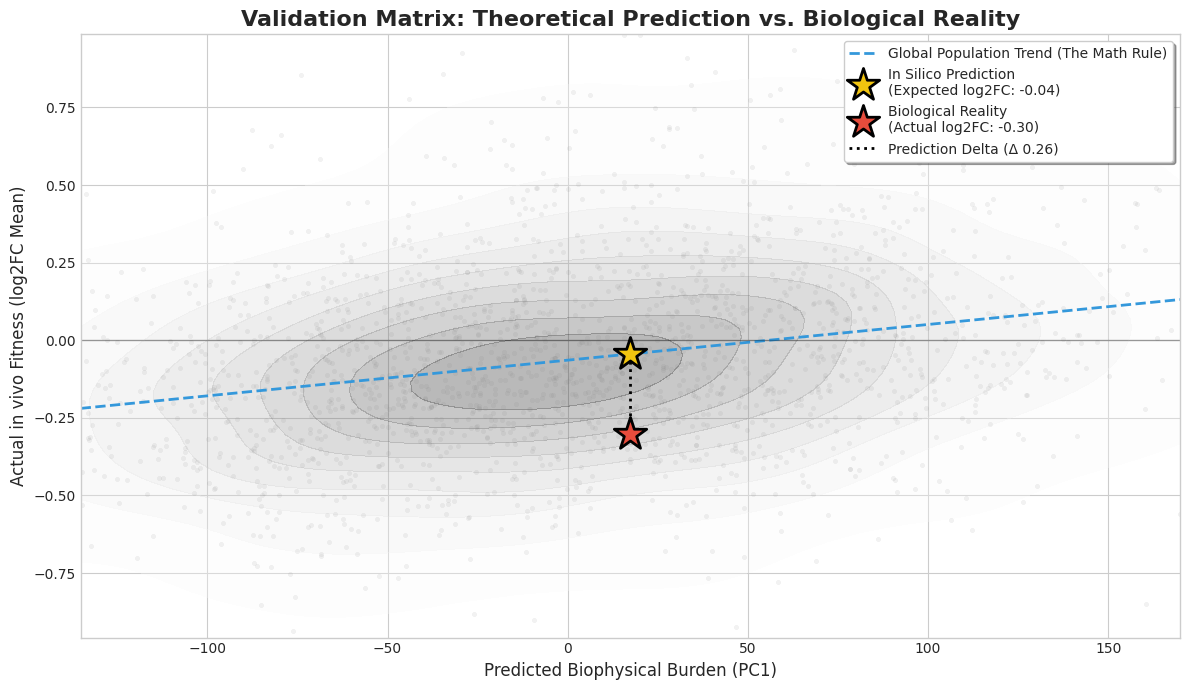


3. VALIDATION VERDICT
   ⚠️ DIVERGENCE: The prediction did not map cleanly to the reality. Unmodeled variables likely present.


In [47]:
# @title Phase 4a(ii): Single-Sequence Blind Validation & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bridge variable names from the fast UMAP cell
pc1_score = svd.transform(X_test_combined)[0, 0]
avg_neighbor_pc1 = avg_pc1_18d if 'avg_pc1_18d' in globals() else 0

print(" EXECUTING SINGLE-SEQUENCE BLIND VALIDATION & MAPPING ")

# 1. Identify the active dataframe and sequence
working_df = df_clean if 'df_clean' in globals() else df

if 'test_plasmid_dna' in globals():
    seq_to_check = test_plasmid_dna
elif 'test_seq' in globals():
    seq_to_check = test_seq
else:
    raise ValueError("Test sequence variable not found in memory.")

print(f"Target Sequence (first 50bp): {seq_to_check[:50]}...")

# 2. Search the wet-lab database
match = working_df[working_df['sequence'] == seq_to_check]

if match.empty:
    print("\n RESULT: Sequence not found in the experimental dataset.")
    print("   This is a truly 'out-of-sample' sequence. No ground truth log2FC available.")
else:
    print("\n RESULT: Success, sequence found in the 124k experimental dataset")

    # 3. Extract ground truth & predictions
    actual_log2fc = match['log2FC_mean'].values[0]
    actual_std    = match['log2FC_std'].values[0]
    replicate_1   = match['log2FC_end1'].values[0]
    replicate_2   = match['log2FC_end2'].values[0]

    pred_pc1     = pc1_score if 'pc1_score' in globals() else 0
    pred_neighbor = avg_neighbor_pc1 if 'avg_neighbor_pc1' in globals() else 0

    print("\n" + "="*85)
    print("                 GROUND TRUTH vs. THEORETICAL PREDICTION")
    print("="*85)

    # --- MODEL READOUT ---
    print("1. MODEL PREDICTION (Biophysical Engine)")
    print(f"   Theoretical PC1 Score:      {pred_pc1:.2f}")
    print(f"   Manifold Neighborhood PC1:  {pred_neighbor:.2f}")

    if pred_neighbor > 0:
        pred_status = "STABLE / ORTHOGONAL"
        color_pred  = '\033[92m'
    else:
        pred_status = "TOXIC / BURDENSOME"
        color_pred  = '\033[91m'
    print(f"   Predicted Status:           {color_pred}{pred_status}\033[0m")

    # --- WET LAB READOUT ---
    print("\n2. ACTUAL BIOLOGICAL REALITY (Wet-Lab Data)")
    print(f"   log2FC Mean (Fitness):      {actual_log2fc:.4f}")
    print(f"   Replicates (R1 / R2):       {replicate_1:.4f} / {replicate_2:.4f} (Std: {actual_std:.4f})")

    if actual_log2fc >= -0.05:
        actual_status = "STABLE / ORTHOGONAL (Survives in vivo)"
        color_act     = '#2ecc71'
        ansi_act      = '\033[92m'
    else:
        actual_status = "TOXIC / BURDENSOME (Depletes in vivo)"
        color_act     = '#e74c3c'
        ansi_act      = '\033[91m'
    print(f"   Actual Biological Status:   {ansi_act}{actual_status}\033[0m")

    # --- 4. VISUALIZATION ---
    print("\n GENERATING VALIDATION DIAGRAM...")

    slope, intercept = np.polyfit(working_df['PC1'], working_df['log2FC_mean'], 1)
    expected_log2fc  = (slope * pred_pc1) + intercept
    delta            = abs(expected_log2fc - actual_log2fc)
    pc1_std          = working_df['PC1'].std()

    fig = plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # Background population density (sampled)
    sns.kdeplot(
        data=working_df.sample(5000, random_state=42),
        x='PC1', y='log2FC_mean',
        fill=True, cmap="Greys", alpha=0.3, thresh=0.05
    )
    sns.scatterplot(
        data=working_df.sample(2000, random_state=42),
        x='PC1', y='log2FC_mean',
        color='grey', s=10, alpha=0.1, edgecolor=None
    )

    # Global trend line
    x_vals = np.linspace(pred_pc1 - pc1_std * 2, pred_pc1 + pc1_std * 2, 100)
    plt.plot(x_vals, slope * x_vals + intercept,
             color='#3498db', linestyle='--', linewidth=2,
             label='Global Population Trend (The Math Rule)')

    # Expected position — gold star
    plt.scatter(pred_pc1, expected_log2fc,
                color='#f1c40f', s=600, marker='*',
                edgecolor='black', linewidth=2,
                label=f'In Silico Prediction\n(Expected log2FC: {expected_log2fc:.2f})',
                zorder=5)

    # Actual reality — red/green star
    plt.scatter(pred_pc1, actual_log2fc,
                color=color_act, s=600, marker='*',
                edgecolor='black', linewidth=2,
                label=f'Biological Reality\n(Actual log2FC: {actual_log2fc:.2f})',
                zorder=6)

    # Delta line connecting prediction to reality
    plt.plot([pred_pc1, pred_pc1], [expected_log2fc, actual_log2fc],
             color='black', linestyle=':', linewidth=2,
             label=f'Prediction Delta (Δ {delta:.2f})',
             zorder=4)

    # Zoom x-axis to ±2 SD around the test sequence
    plt.xlim(pred_pc1 - pc1_std * 2, pred_pc1 + pc1_std * 2)

    # Zoom y-axis to keep both stars visible
    y_lower = min(working_df['log2FC_mean'].quantile(0.01),
                  actual_log2fc, expected_log2fc) - 0.1
    y_upper = max(working_df['log2FC_mean'].quantile(0.99),
                  actual_log2fc, expected_log2fc) + 0.1
    plt.ylim(y_lower, y_upper)

    plt.axhline(0, color='black', linewidth=1, alpha=0.3)
    plt.title('Validation Matrix: Theoretical Prediction vs. Biological Reality',
              fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Biophysical Burden (PC1)', fontsize=12)
    plt.ylabel('Actual in vivo Fitness (log2FC Mean)', fontsize=12)
    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- 5. VALIDATION VERDICT ---
    print("\n3. VALIDATION VERDICT")
    if delta <= 0.15:
        print("    OUTSTANDING: The biophysical prediction almost perfectly matched the lab reality!")
    elif ('STABLE' in pred_status and 'STABLE' in actual_status) or \
         ('TOXIC' in pred_status and 'TOXIC' in actual_status):
        print("    SUCCESS: Directional prediction was correct. The math successfully identified the status.")
    else:
        print("    DIVERGENCE: The prediction did not map cleanly to the reality. Unmodeled variables likely present.")
    print("="*85)

ADVANCED ANALYSIS 2: tRNA DEPLETION (CODON ADAPTATION INDEX)
 Calculating exact CAI scores for 120k sequences...
 CAI Calculation complete.
 Generating Population Distribution...


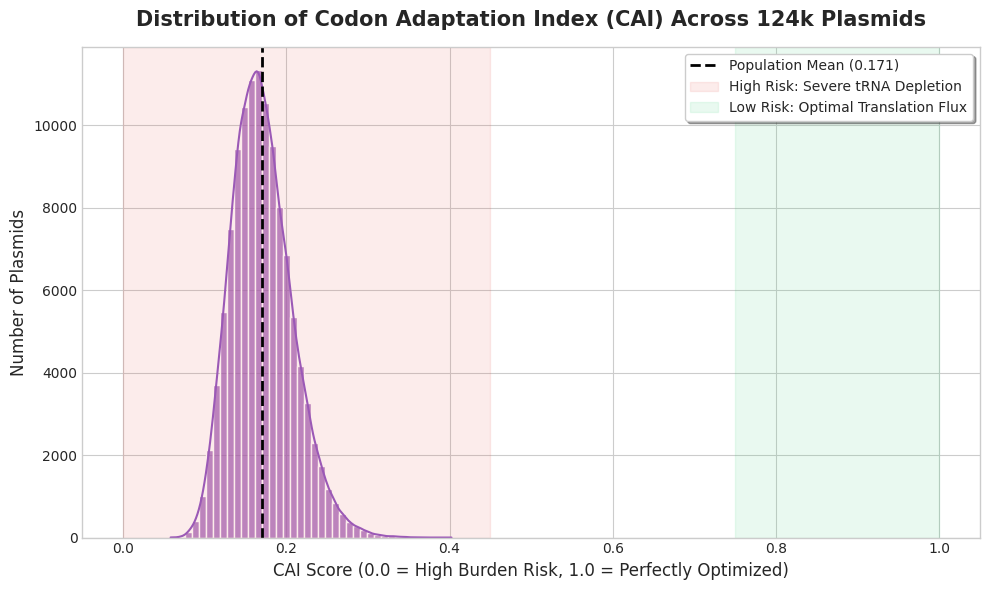


             BIOLOGICAL INTERPRETATION: tRNA DEPLETION & STALLING
Dataset Average CAI: 0.171
Worst CAI in dataset: 0.058 | Best CAI in dataset: 0.402

WHAT THIS CHART MEANS:
• The Codon Adaptation Index (CAI) measures how well the plasmid's DNA matches
  the tRNA pool naturally available inside E. coli.
• GREEN ZONE (>0.75): The sequence uses highly abundant DNA words. The ribosome
  can translate it smoothly and quickly, preventing mRNA traffic jams.
• RED ZONE (<0.45): The sequence uses rare DNA words (like AGG for Arginine).
  The ribosome physically stalls waiting for rare tRNAs, creating a massive
  metabolic sink that starves the rest of the host cell.

NOTE: TTC (Translational Traffic Cost) in the 18-feature model is the inverse
  of CAI (1 - CAI), so higher TTC = higher burden. CAI_Score here is the raw
  value for interpretability; TTC is the direction-corrected feature used in
  the SVD. The two are always consistent.

TEST PLASMID CAI: 0.130  (population mean: 0.171)
 DIAGN

In [48]:
# @title Phase 4b - tRNA Depletion (CAI)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("ADVANCED ANALYSIS 2: tRNA DEPLETION (CODON ADAPTATION INDEX)")

# ── NOTE ──────────────────────────────────────────────────────────────────────
# ECOLI_W is defined once in Cell 5 and reused here to keep a single source
# of truth. Do not redefine it below — if Cell 5 has not been run yet this
# cell will raise a NameError as an early warning.
# ─────────────────────────────────────────────────────────────────────────────
if 'ECOLI_W' not in globals():
    raise RuntimeError(
        "'ECOLI_W' not found. Run Cell 5 (Feature Extraction) first."
    )

def calculate_cai(sequence):
    """Calculates the Codon Adaptation Index for a given DNA sequence.

    Uses the ECOLI_W relative adaptiveness table defined in Cell 5.
    Stop codons are excluded so they do not skew elongation scores.
    """
    STOP_CODONS = {'TAA', 'TAG', 'TGA'}
    seq = sequence[:len(sequence) - (len(sequence) % 3)].upper()
    codons = [seq[i:i+3] for i in range(0, len(seq), 3)]

    weights = [ECOLI_W.get(codon) for codon in codons
               if codon not in STOP_CODONS]
    valid_weights = [w for w in weights if w is not None]

    if not valid_weights:
        return 0.0

    return float(np.exp(np.mean(np.log(valid_weights))))

# ── APPLY TO CLEAN DATASET ────────────────────────────────────────────────────
print(" Calculating exact CAI scores for 120k sequences...")
df_clean['CAI_Score'] = df_clean['sequence'].apply(calculate_cai)
print(" CAI Calculation complete.")

# ── VISUALISATION ─────────────────────────────────────────────────────────────
print(" Generating Population Distribution...")
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['CAI_Score'], bins=40, kde=True,
             color='#9b59b6', edgecolor='white', alpha=0.7)

plt.title('Distribution of Codon Adaptation Index (CAI) Across 124k Plasmids',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('CAI Score (0.0 = High Burden Risk, 1.0 = Perfectly Optimized)',
           fontsize=12)
plt.ylabel('Number of Plasmids', fontsize=12)

mean_cai = df_clean['CAI_Score'].mean()
plt.axvline(mean_cai, color='black', linestyle='--', linewidth=2,
            label=f'Population Mean ({mean_cai:.3f})')

plt.axvspan(0.0,  0.45, color='#e74c3c', alpha=0.1,
            label='High Risk: Severe tRNA Depletion')
plt.axvspan(0.75, 1.0,  color='#2ecc71', alpha=0.1,
            label='Low Risk: Optimal Translation Flux')

plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# ── BIOLOGICAL READOUT ────────────────────────────────────────────────────────
print("\n" + "=" * 85)
print("             BIOLOGICAL INTERPRETATION: tRNA DEPLETION & STALLING")
print("=" * 85)
print(f"Dataset Average CAI: {mean_cai:.3f}")
print(f"Worst CAI in dataset: {df_clean['CAI_Score'].min():.3f} "
      f"| Best CAI in dataset: {df_clean['CAI_Score'].max():.3f}")
print("\nWHAT THIS CHART MEANS:")
print("• The Codon Adaptation Index (CAI) measures how well the plasmid's DNA matches")
print("  the tRNA pool naturally available inside E. coli.")
print("• GREEN ZONE (>0.75): The sequence uses highly abundant DNA words. The ribosome")
print("  can translate it smoothly and quickly, preventing mRNA traffic jams.")
print("• RED ZONE (<0.45): The sequence uses rare DNA words (like AGG for Arginine).")
print("  The ribosome physically stalls waiting for rare tRNAs, creating a massive")
print("  metabolic sink that starves the rest of the host cell.")
print()
print("NOTE: TTC (Translational Traffic Cost) in the 18-feature model is the inverse")
print("  of CAI (1 - CAI), so higher TTC = higher burden. CAI_Score here is the raw")
print("  value for interpretability; TTC is the direction-corrected feature used in")
print("  the SVD. The two are always consistent.")
print("=" * 85)

# ── TEST SEQUENCE ─────────────────────────────────────────────────────────────
if 'test_seq' in globals():
    test_cai = calculate_cai(test_seq)
    print(f"\nTEST PLASMID CAI: {test_cai:.3f}  "
          f"(population mean: {mean_cai:.3f})")
    if test_cai < 0.5:
        print(" DIAGNOSIS: Severe tRNA depletion — ribosomal stalling likely.")
    elif test_cai < mean_cai:
        print("DIAGNOSIS: Below-average CAI — moderate translational cost.")
    else:
        print("DIAGNOSIS: CAI healthy. Toxicity likely structural "
              "(hairpins or H-NS silencing).")

In [49]:
#@title CAI scorer
print("Recalculating population CAI scores...")
df_clean['CAI_Score'] = df_clean['sequence'].apply(calculate_cai)
print(f"Mean CAI: {df_clean['CAI_Score'].mean():.4f}")
print(f"Range:    {df_clean['CAI_Score'].min():.4f} to {df_clean['CAI_Score'].max():.4f}")

Recalculating population CAI scores...
Mean CAI: 0.1706
Range:    0.0582 to 0.4024


In [50]:
#@title CAI checker
# Check the CAI of your specific test sequence
test_cai = calculate_cai(test_seq)
print(f"TEST PLASMID CAI: {test_cai:.3f}")

if test_cai < 0.5:
    print("DIAGNOSIS: This plasmid is on the 'Toxic Island' because of severe Ribosomal Stalling.")
else:
    print("DIAGNOSIS: CAI is healthy. The toxicity is likely structural (Hairpins or H-NS Silencing).")

TEST PLASMID CAI: 0.130
 DIAGNOSIS: This plasmid is on the 'Toxic Island' because of severe Ribosomal Stalling.


In [51]:
# @title Phase 4c: Genetic Grammar (Text Readout Only)
# Install mlxtend quietly
!pip install -q mlxtend

import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

print("ADVANCED ANALYSIS 3: OPTIMIZED GENETIC GRAMMAR (TEXT-ONLY MODE) ")

# --- STEP 0: MEMORY SAFETY CHECK ---
required_vars = ['motifs_df', 'mech_feature_labels', 'feature_names', 'X_sparse']
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing required variables: {missing_vars}. Please re-run the SVD cell first.")

# 1. OPTIMIZATION: Filter to only the Top 50 sequence drivers
top_50_names = motifs_df[~motifs_df['Motif'].isin(mech_feature_labels)].head(50)['Motif'].tolist()
motif_to_idx = {name: i for i, name in enumerate(feature_names)}
indices = [motif_to_idx[m] for m in top_50_names if m in motif_to_idx]

# Convert the sparse data to a lightweight boolean DataFrame for FP-Growth
X_binary_filtered = (X_sparse[:, indices] > 0).astype(bool)
df_binary = pd.DataFrame(X_binary_filtered.toarray(), columns=[feature_names[i] for i in indices])

# 2. RUN FP-GROWTH (ULTRA-LEAN)
# We search for rules that exist in at least 40% of the 120k population.
print("Mining dominant motif interactions (Support: 0.4, Max Length: 2)...")
frequent_itemsets = fpgrowth(df_binary, min_support=0.4, use_colnames=True, max_len=2)

if not frequent_itemsets.empty:
    # 3. GENERATE ASSOCIATION RULES
    # Lift > 1.1 ensures the combination is non-random
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

    if not rules.empty:
        top_rules = rules.sort_values(by='lift', ascending=False).head(5)

        # 4. DETAILED BIOLOGICAL READOUT
        print("\n" + "="*85)
        print("             BIOLOGICAL INTERPRETATION: UNIVERSAL GENETIC GRAMMAR")
        print("="*85)
        print(f"Total sequences analyzed: {len(df_clean):,}")
        print(f"Total significant motif-pair interactions found: {len(rules)}")

        print("\nTOP 5 DISCOVERED SYNERGIES (High Lift = Strong Interaction):")
        print("-" * 85)
        for idx, row in enumerate(top_rules.itertuples()):
            ant = list(row.antecedents)
            con = list(row.consequents)
            print(f"Rule {idx+1}: IF {ant} THEN {con}")
            print(f"   -> Synergy Strength (Lift): {row.lift:.2f}")
            print(f"   -> Certainty (Confidence):  {row.confidence*100:.1f}%")
            print(f"   -> Population Frequency:    {row.support*100:.1f}%")
            print("-" * 85)

        print("\nWHAT THESE RULES MEAN FOR YOUR TOXIC ISLAND:")
        print("• These rules identify 'Motif Teams'. If your toxic plasmid contains")
        print("  both motifs in a high-lift rule, they are acting together to")
        print("  either physically block the ribosome or recruit host silencing proteins.")
        print("="*85)
    else:
        print("⚠️ No motif pairs exceeded the synergy threshold (Lift > 1.1).")
else:
    print("⚠️ No motifs found with >40% support. Try lowering min_support to 0.3 if this finishes too fast.")

ADVANCED ANALYSIS 3: OPTIMIZED GENETIC GRAMMAR (TEXT-ONLY MODE) 
Mining dominant motif interactions (Support: 0.4, Max Length: 2)...

             BIOLOGICAL INTERPRETATION: UNIVERSAL GENETIC GRAMMAR
Total sequences analyzed: 118,084
Total significant motif-pair interactions found: 36

TOP 5 DISCOVERED SYNERGIES (High Lift = Strong Interaction):
-------------------------------------------------------------------------------------
Rule 1: IF ['mid_tatt'] THEN ['mid_ttat']
   -> Synergy Strength (Lift): 1.26
   -> Certainty (Confidence):  73.6%
   -> Population Frequency:    42.8%
-------------------------------------------------------------------------------------
Rule 2: IF ['mid_ttat'] THEN ['mid_tatt']
   -> Synergy Strength (Lift): 1.26
   -> Certainty (Confidence):  73.2%
   -> Population Frequency:    42.8%
-------------------------------------------------------------------------------------
Rule 3: IF ['mid_tatt'] THEN ['mid_attt']
   -> Synergy Strength (Lift): 1.22
   -> Certai

In [52]:
# @title 4c(ii): Test Sequence Initialisation & Translation Metrics

print("--- INITIALIZING TEST CONSTRUCT FOR ADVANCED ANALYSIS ---")

# ── STEP 1: SEQUENCE SAFETY ───────────────────────────────────────────────────
if 'test_seq' not in globals() or len(test_seq) < 50:
    test_seq = "AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGGCGTTTACGGTTGAATATATCACTATTACCATATGTTTGGGCGTTCTGTACCTATTACCGCGTTTACTGTTCCGCATAACTATAGCCACTTCATATCTAAAGGCTATCAAATG"
    print(f"  ↳ test_seq not found — using default ({len(test_seq)} bp)")
else:
    print(f"  ↳ test_seq in memory ({len(test_seq)} bp)")

# ── STEP 2: REAL MFE FUNCTION (SantaLucia 1998) ──────────────────────────────
def calculate_mfe_initiation(sequence, window=30):
    nn_dG = {
        'AA': -1.0,  'AT': -0.88, 'AC': -1.44, 'AG': -1.28,
        'TA': -0.58, 'TT': -1.0,  'TC': -1.30, 'TG': -1.45,
        'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17,
        'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
    }
    seq = sequence[:window].upper().replace('U', 'T')
    if len(seq) < 2:
        return 0.0
    total_dG, n_pairs = 0.0, 0
    for i in range(len(seq) - 1):
        dinuc = seq[i:i+2]
        if dinuc in nn_dG:
            total_dG += nn_dG[dinuc]
            n_pairs  += 1
    if n_pairs == 0:
        return 0.0
    return round((total_dG / n_pairs) * (window / 2), 3)

# ── STEP 3: CAI ───────────────────────────────────────────────────────────────
if 'calculate_cai' not in globals():
    raise RuntimeError("calculate_cai not found. Run the Phase 4b (CAI) cell first.")

test_cai = calculate_cai(test_seq)
test_mfe = calculate_mfe_initiation(test_seq)
print(f"  ↳ CAI: {test_cai:.4f}")
print(f"  ↳ MFE initiation window (first 30 nt): {test_mfe:.3f} kcal/mol")

# ── STEP 4: APPLY TO df_clean ─────────────────────────────────────────────────
print("\nApplying MFE to df_clean (~1 min)...")
df_clean['mRNA_MFE'] = df_clean['sequence'].apply(calculate_mfe_initiation)
print(f"  ↳ Mean MFE: {df_clean['mRNA_MFE'].mean():.3f} kcal/mol")
print(f"  ↳ Range:    {df_clean['mRNA_MFE'].min():.3f} to {df_clean['mRNA_MFE'].max():.3f}")

# ── STEP 5: INTERPRETATION ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  TRANSLATION METRIC SUMMARY")
print("=" * 70)
print(f"  Sequence        : {test_seq[:30]}… ({len(test_seq)} bp)")
print(f"  CAI Score       : {test_cai:.4f}  ", end="")
print("  Rare codon burden" if test_cai < 0.5 else "✅ Acceptable")
print(f"  MFE Init Window : {test_mfe:.3f} kcal/mol  ", end="")
if test_mfe < -15.0:
    print("  Strong hairpin — stalling risk")
elif test_mfe < -10.0:
    print("⚠️  Moderate secondary structure")
else:
    print(" Initiation window accessible")
print("=" * 70)
print(" Ready. Proceed with Analysis 4.")

--- INITIALIZING TEST CONSTRUCT FOR ADVANCED ANALYSIS ---
  ↳ test_seq in memory (172 bp)
  ↳ CAI: 0.1303
  ↳ MFE initiation window (first 30 nt): -21.134 kcal/mol

Applying MFE to df_clean (~1 min)...
  ↳ Mean MFE: -18.936 kcal/mol
  ↳ Range:    -25.748 to -13.759

  TRANSLATION METRIC SUMMARY
  Sequence        : AAGCAAAATTGGGGGCGTGTGCTTATCTTG… (172 bp)
  CAI Score       : 0.1303    Rare codon burden
  MFE Init Window : -21.134 kcal/mol    Strong hairpin — stalling risk
 Ready. Proceed with Analysis 4.


Generating Genetic Grammar Visualisation...


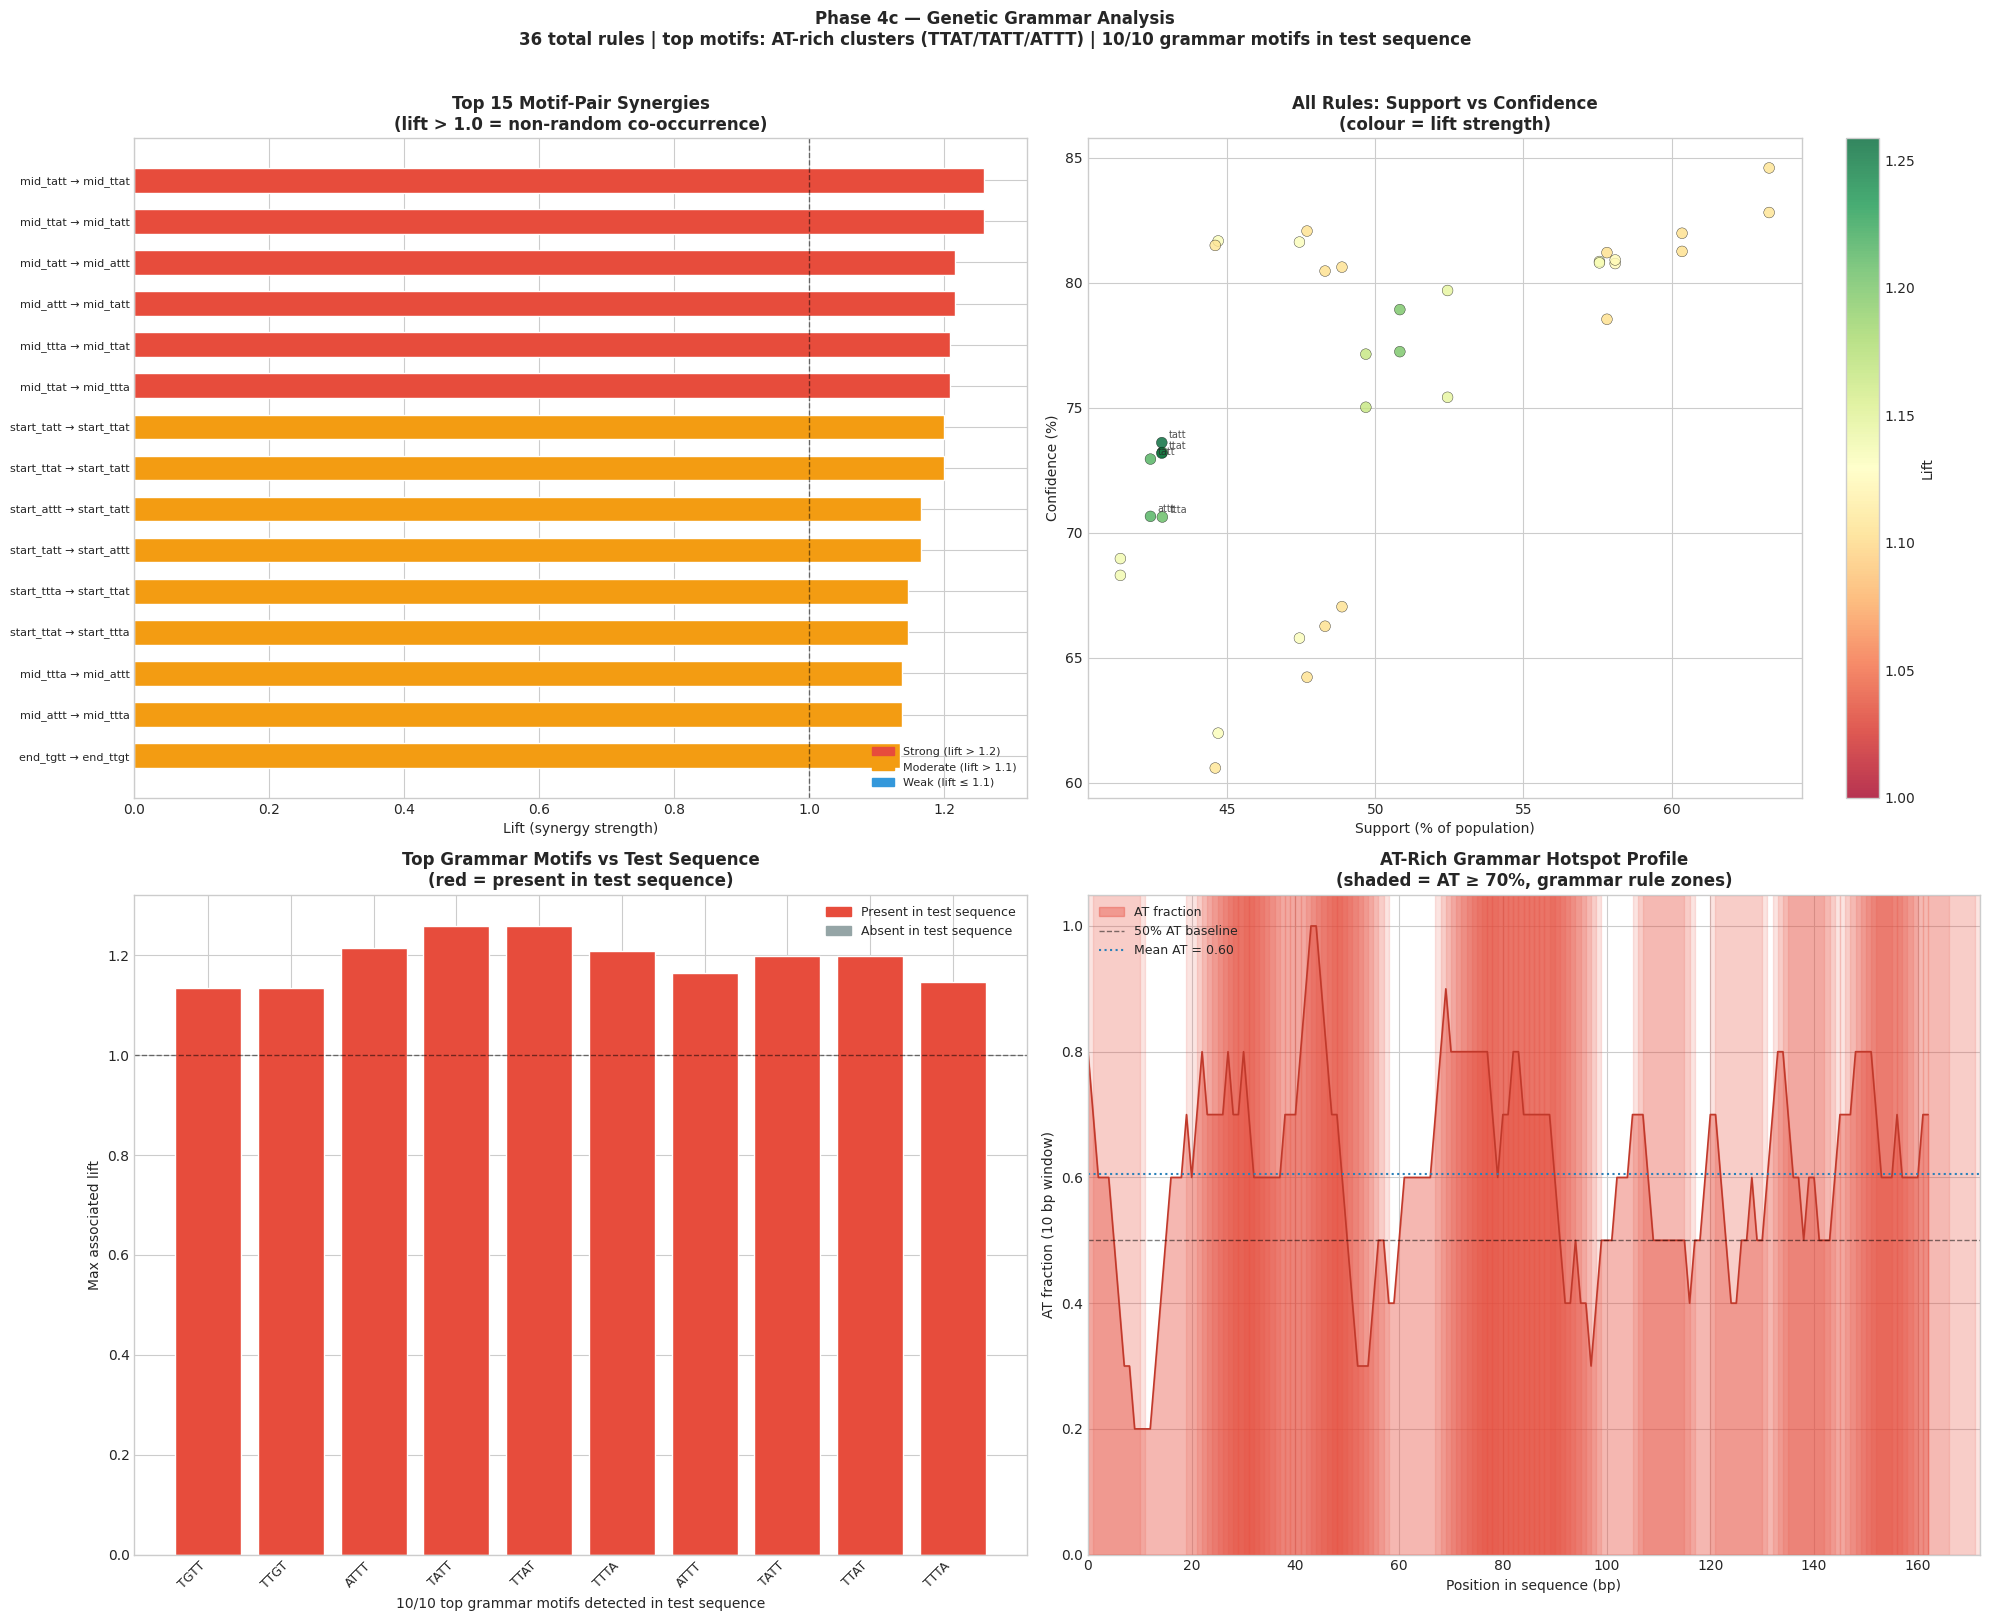

Saved as genetic_grammar_visualisation.png


In [53]:
# @title Phase 4c(iii) Visualisation of Genetic Grammar & Motif Synergies

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

print("Generating Genetic Grammar Visualisation...")

if 'rules' not in globals() or rules.empty:
    raise RuntimeError("No association rules found. Run Phase 4c first.")

sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 16))

# ── PLOT 1: Top 15 rules by lift (bar chart) ──────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
top_rules = rules.sort_values('lift', ascending=False).head(15).copy()
top_rules['rule_label'] = [
    f"{list(r.antecedents)[0]} → {list(r.consequents)[0]}"
    for _, r in top_rules.iterrows()
]
colors = ['#e74c3c' if l > 1.2 else '#f39c12' if l > 1.1 else '#3498db'
          for l in top_rules['lift']]
bars = ax1.barh(range(len(top_rules)), top_rules['lift'],
                color=colors, edgecolor='white', height=0.6)
ax1.set_yticks(range(len(top_rules)))
ax1.set_yticklabels(top_rules['rule_label'], fontsize=8)
ax1.axvline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5,
            label='Lift = 1.0 (random)')
ax1.set_xlabel("Lift (synergy strength)")
ax1.set_title("Top 15 Motif-Pair Synergies\n(lift > 1.0 = non-random co-occurrence)",
              fontweight='bold')
red_p   = mpatches.Patch(color='#e74c3c', label='Strong (lift > 1.2)')
orange_p = mpatches.Patch(color='#f39c12', label='Moderate (lift > 1.1)')
blue_p  = mpatches.Patch(color='#3498db', label='Weak (lift ≤ 1.1)')
ax1.legend(handles=[red_p, orange_p, blue_p], fontsize=8, loc='lower right')
ax1.invert_yaxis()

# ── PLOT 2: Confidence vs Support scatter ─────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
sc = ax2.scatter(
    rules['support'] * 100,
    rules['confidence'] * 100,
    c=rules['lift'],
    cmap='RdYlGn', s=60, alpha=0.8, edgecolors='black', linewidths=0.3,
    vmin=1.0, vmax=rules['lift'].max()
)
plt.colorbar(sc, ax=ax2, label='Lift')
ax2.set_xlabel('Support (% of population)')
ax2.set_ylabel('Confidence (%)')
ax2.set_title('All Rules: Support vs Confidence\n(colour = lift strength)',
              fontweight='bold')

# Annotate top 5
top5 = rules.sort_values('lift', ascending=False).head(5)
for _, row in top5.iterrows():
    label = f"{list(row.antecedents)[0].split('_')[-1]}"
    ax2.annotate(label,
                 xy=(row['support'] * 100, row['confidence'] * 100),
                 xytext=(5, 3), textcoords='offset points',
                 fontsize=7, alpha=0.8)

# ── PLOT 3: Motif frequency in test sequence ──────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)

# Extract unique motifs from top rules and check presence in test_seq
top15_motifs = set()
for _, row in top_rules.iterrows():
    top15_motifs.update([list(row.antecedents)[0], list(row.consequents)[0]])

motif_names, motif_present, motif_lift = [], [], []
for motif in sorted(top15_motifs):
    raw = motif.split('_')[-1].upper()
    present = raw in test_seq.upper()
    max_lift = rules[
        rules['antecedents'].apply(lambda x: motif in x) |
        rules['consequents'].apply(lambda x: motif in x)
    ]['lift'].max() if not rules.empty else 1.0
    motif_names.append(raw)
    motif_present.append(present)
    motif_lift.append(max_lift)

bar_colors = ['#e74c3c' if p else '#95a5a6' for p in motif_present]
ax3.bar(range(len(motif_names)), motif_lift,
        color=bar_colors, edgecolor='white')
ax3.set_xticks(range(len(motif_names)))
ax3.set_xticklabels(motif_names, rotation=45, ha='right', fontsize=9)
ax3.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_ylabel('Max associated lift')
ax3.set_title('Top Grammar Motifs vs Test Sequence\n(red = present in test sequence)',
              fontweight='bold')
present_p = mpatches.Patch(color='#e74c3c', label='Present in test sequence')
absent_p  = mpatches.Patch(color='#95a5a6', label='Absent in test sequence')
ax3.legend(handles=[present_p, absent_p], fontsize=9)

n_hits = sum(motif_present)
ax3.set_xlabel(f'{n_hits}/{len(motif_names)} top grammar motifs detected in test sequence')

# ── PLOT 4: AT-rich motif clustering along test sequence ──────────────────────
ax4 = fig.add_subplot(2, 2, 4)

# Slide a 10 bp window along the test sequence and compute AT fraction
window_size = 10
seq         = test_seq.upper()
positions   = range(len(seq) - window_size + 1)
at_profile  = [
    (seq[i:i+window_size].count('A') + seq[i:i+window_size].count('T')) / window_size
    for i in positions
]

ax4.fill_between(positions, at_profile, alpha=0.4, color='#e74c3c', label='AT fraction')
ax4.plot(positions, at_profile, color='#c0392b', linewidth=1.2)
ax4.axhline(0.5, color='black', linestyle='--', linewidth=1,
            alpha=0.5, label='50% AT baseline')
ax4.axhline(np.mean(at_profile), color='#2980b9', linestyle=':',
            linewidth=1.5, label=f'Mean AT = {np.mean(at_profile):.2f}')

# Shade high-AT regions (grammar hotspots)
threshold = 0.7
for i in positions:
    if at_profile[i] >= threshold:
        ax4.axvspan(i, i + window_size, alpha=0.15, color='#e74c3c')

ax4.set_xlabel('Position in sequence (bp)')
ax4.set_ylabel('AT fraction (10 bp window)')
ax4.set_title('AT-Rich Grammar Hotspot Profile\n(shaded = AT ≥ 70%, grammar rule zones)',
              fontweight='bold')
ax4.set_xlim(0, len(seq))
ax4.set_ylim(0, 1.05)
ax4.legend(fontsize=9)

# ── MASTER TITLE ──────────────────────────────────────────────────────────────
fig.suptitle(
    f'Phase 4c — Genetic Grammar Analysis\n'
    f'{len(rules)} total rules | top motifs: AT-rich clusters '
    f'(TTAT/TATT/ATTT) | {n_hits}/{len(motif_names)} grammar motifs in test sequence',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('genetic_grammar_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as genetic_grammar_visualisation.png")

In [54]:
# @title Systemic Metrics Calculator
def analyze_systemic_interference(seq):
    """
    Computes systemic burden metrics:
    - Unit_Metabolic_Cost: ATP drain from rare codon usage (Akashi 1994)
    - Stalling_Events: count of rare codons that cause ribosome stalling

    Returns: (cost, stalls)
    """
    seq = seq.upper()
    seq_trimmed = seq[:len(seq) - (len(seq) % 3)]
    codons = [seq_trimmed[i:i+3] for i in range(0, len(seq_trimmed), 3)]

    # Metabolic cost: inverse of CAI, scaled by codon count
    w_vals = [ECOLI_W.get(c, 0.5) for c in codons]
    if w_vals:
        cai = np.exp(np.mean(np.log(w_vals)))
        cost = (1.0 - cai) * len(codons)
    else:
        cost = 0.0

    # Stalling events: count of severe rare codons
    stalls = sum(1 for c in codons if c in RARE_CODONS)

    return cost, stalls

# Apply to full dataset (if not already present)
if 'Unit_Metabolic_Cost' not in df_clean.columns:
    print("Computing systemic metrics for full dataset...")
    systemic = df_clean['sequence'].apply(analyze_systemic_interference)
    df_clean['Unit_Metabolic_Cost'] = [x[0] for x in systemic]
    df_clean['Stalling_Events'] = [x[1] for x in systemic]

    # Flux_Proxy = length × CAI (transcriptional load proxy)
    df_clean['Flux_Proxy'] = df_clean['Size'] * df_clean['CAI_Score']

    print("Systemic metrics added to df_clean")
    print(f"   Columns added: Unit_Metabolic_Cost, Stalling_Events, Flux_Proxy")

Computing systemic metrics for full dataset...
Systemic metrics added to df_clean
   Columns added: Unit_Metabolic_Cost, Stalling_Events, Flux_Proxy


In [55]:
# Quick fix: add missing Flux_Proxy if not present
if 'Flux_Proxy' not in df_clean.columns:
    df_clean['Flux_Proxy'] = df_clean['Size'] * df_clean['CAI_Score']
    print("Flux_Proxy added to df_clean")

--- EXECUTING ADVANCED ANALYSIS 4: SYSTEMIC & METABOLIC BURDEN ---


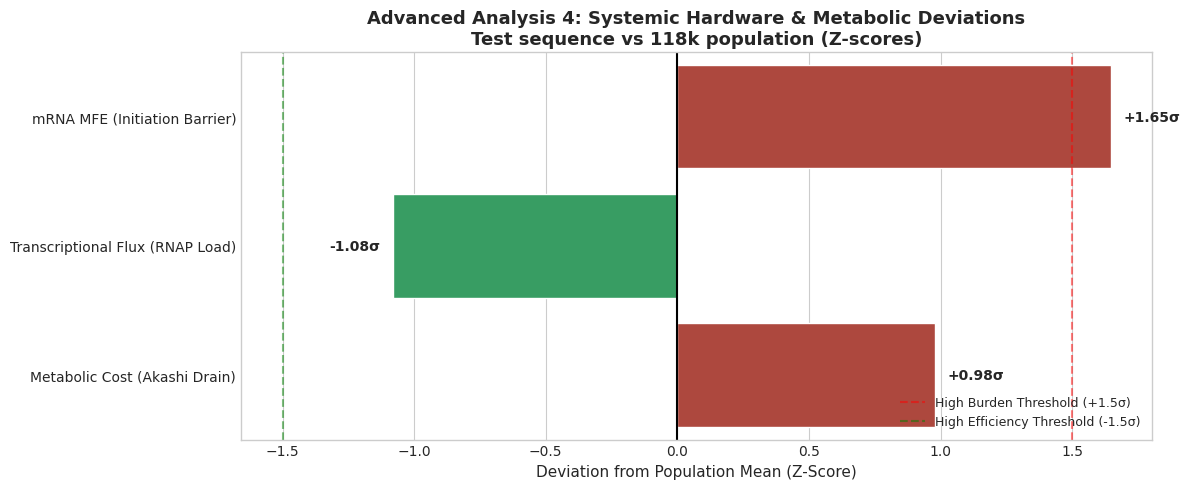


--- SYSTEMIC BURDEN AUDIT ---
  Test sequence : AAGCAAAATTGGGGGCGTGTGCTTATCTTG… (172 bp)
  CAI           : 0.1303
  MFE           : -21.134 kcal/mol
  Metabolic cost: 49.4
  Stalling events: 12

  HIGH BURDEN: mRNA MFE (Initiation Barrier) (Z = +1.65)
     MECHANISM: mRNA secondary structure occludes ribosome binding site — initiation stalling.
➖  NEUTRAL: Transcriptional Flux (RNAP Load) (Z = -1.08)
     Within standard physiological tolerance parameters.
➖  NEUTRAL: Metabolic Cost (Akashi Drain) (Z = 0.98)
     Within standard physiological tolerance parameters.

 Phase 4d complete.


In [56]:
# @title Phase 4d: SYSTEMIC HARDWARE & METABOLIC BURDEN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EXECUTING ADVANCED ANALYSIS 4: SYSTEMIC & METABOLIC BURDEN ---")

# ── STEP 1: CALCULATE SYSTEMIC METRICS ───────────────────────────────────────
test_cost, test_stalls = analyze_systemic_interference(test_seq)
test_flux = len(test_seq) * test_cai

# ── STEP 2: POPULATION Z-SCORES ──────────────────────────────────────────────
# MFE sign is flipped: more negative MFE = stronger hairpin = higher burden.
# Negating the Z-score corrects the direction so rightward = more burdensome.
# Hardware Size Titration removed — all sequences are 172 bp (zero variance).
adv_metrics = {
    'Metabolic Cost (Akashi Drain)':
        (test_cost - df_clean['Unit_Metabolic_Cost'].mean()) /
        (df_clean['Unit_Metabolic_Cost'].std() or 1),
    'Transcriptional Flux (RNAP Load)':
        (test_flux - df_clean['Flux_Proxy'].mean()) /
        (df_clean['Flux_Proxy'].std() or 1),
    'mRNA MFE (Initiation Barrier)':
        -1 * (test_mfe - df_clean['mRNA_MFE'].mean()) /
        (df_clean['mRNA_MFE'].std() or 1),
}

# ── STEP 3: VISUALISATION ────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")

adv_sorted = dict(sorted(adv_metrics.items(),
                          key=lambda x: abs(x[1]), reverse=True))

colors = ['#c0392b' if val > 0 else '#27ae60' for val in adv_sorted.values()]
ax = sns.barplot(x=list(adv_sorted.values()),
                 y=list(adv_sorted.keys()),
                 hue=list(adv_sorted.keys()),
                 palette=colors,
                 legend=False)

ax.axvline(0,    color='black', linewidth=1.5)
ax.axvline( 1.5, color='red',   linestyle='--', alpha=0.5,
            label='High Burden Threshold (+1.5σ)')
ax.axvline(-1.5, color='green', linestyle='--', alpha=0.5,
            label='High Efficiency Threshold (-1.5σ)')

# Annotate bars with Z-score values
for i, (metric, z) in enumerate(adv_sorted.items()):
    ax.text(z + (0.05 if z >= 0 else -0.05), i,
            f'{z:+.2f}σ', va='center',
            ha='left' if z >= 0 else 'right', fontsize=10, fontweight='bold')

ax.set_title('Advanced Analysis 4: Systemic Hardware & Metabolic Deviations\n'
             f'Test sequence vs 118k population (Z-scores)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Deviation from Population Mean (Z-Score)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# ── STEP 4: AUDIT REPORT ─────────────────────────────────────────────────────
print("\n--- SYSTEMIC BURDEN AUDIT ---")
print(f"  Test sequence : {test_seq[:30]}… ({len(test_seq)} bp)")
print(f"  CAI           : {test_cai:.4f}")
print(f"  MFE           : {test_mfe:.3f} kcal/mol")
print(f"  Metabolic cost: {test_cost:.1f}")
print(f"  Stalling events: {test_stalls}")
print()

for metric, z_score in adv_sorted.items():
    if z_score > 1.5:
        print(f"  HIGH BURDEN: {metric} (Z = +{z_score:.2f})")
        if "Flux" in metric:
            print("     MECHANISM: Polymerase titration — sequence length × CAI "
                  "proxy suggests high RNAP occupancy.")
        elif "MFE" in metric:
            print("     MECHANISM: mRNA secondary structure occludes ribosome "
                  "binding site — initiation stalling.")
        else:
            print("     MECHANISM: Translational sink — high biosynthetic "
                  "investment draining host ATP/precursors.")
    elif z_score < -1.5:
        print(f"  HIGH EFFICIENCY: {metric} (Z = {z_score:.2f})")
        print("     Construct is below population burden — "
              "minimal interference with host physiology.")
    else:
        print(f"➖  NEUTRAL: {metric} (Z = {z_score:.2f})")
        print("     Within standard physiological tolerance parameters.")

print("\n Phase 4d complete.")

PHASE 4e: STRUCTURAL & TOPOLOGICAL BURDEN ANALYSIS

[1/4] RNA Hairpin Scan:
  Total hairpin-forming regions detected: 2
  Most stable hairpin:
    Position  : 54 bp
    Stem      : CCGT (4 bp)
    Loop      : GGCGTTT (7 nt)
    GC stem   : 75%
    Est. ΔG   : -5.45 kcal/mol
      MODERATE: Hairpin may impede translation initiation

[2/4] H-NS Xenogeneic Silencing Risk:
  H-NS binding sites (AT ≥ 65%, 10 bp window): 67
  Sequence coverage: 41.1%
  ⚠️  HIGH: >40% of sequence at risk of H-NS clamping
  Sequence AT fraction: 0.610 | Population mean: 0.628 | Z = -0.37

[3/4] Plasmid Topology:
  Dinucleotide bendability: mean = 6.09, std = 1.70
  ⚠️  MODERATE: Moderate supercoiling risk
  Direct repeats (≥ 8 bp): 2 detected
  Longest repeat: CTATTACC… (8 bp) at positions 81 and 110
  ⚠️  MODERATE: Repeats 8-11 bp — elevated recombination risk

[4/4] Transcriptional Flux Estimate:
  Flux score      : 125.52
  AT fraction     : 0.610
  GC variability  : 0.488
  σ⁷⁰ -10 hits   : 17
  ⚠️  HIGH: 

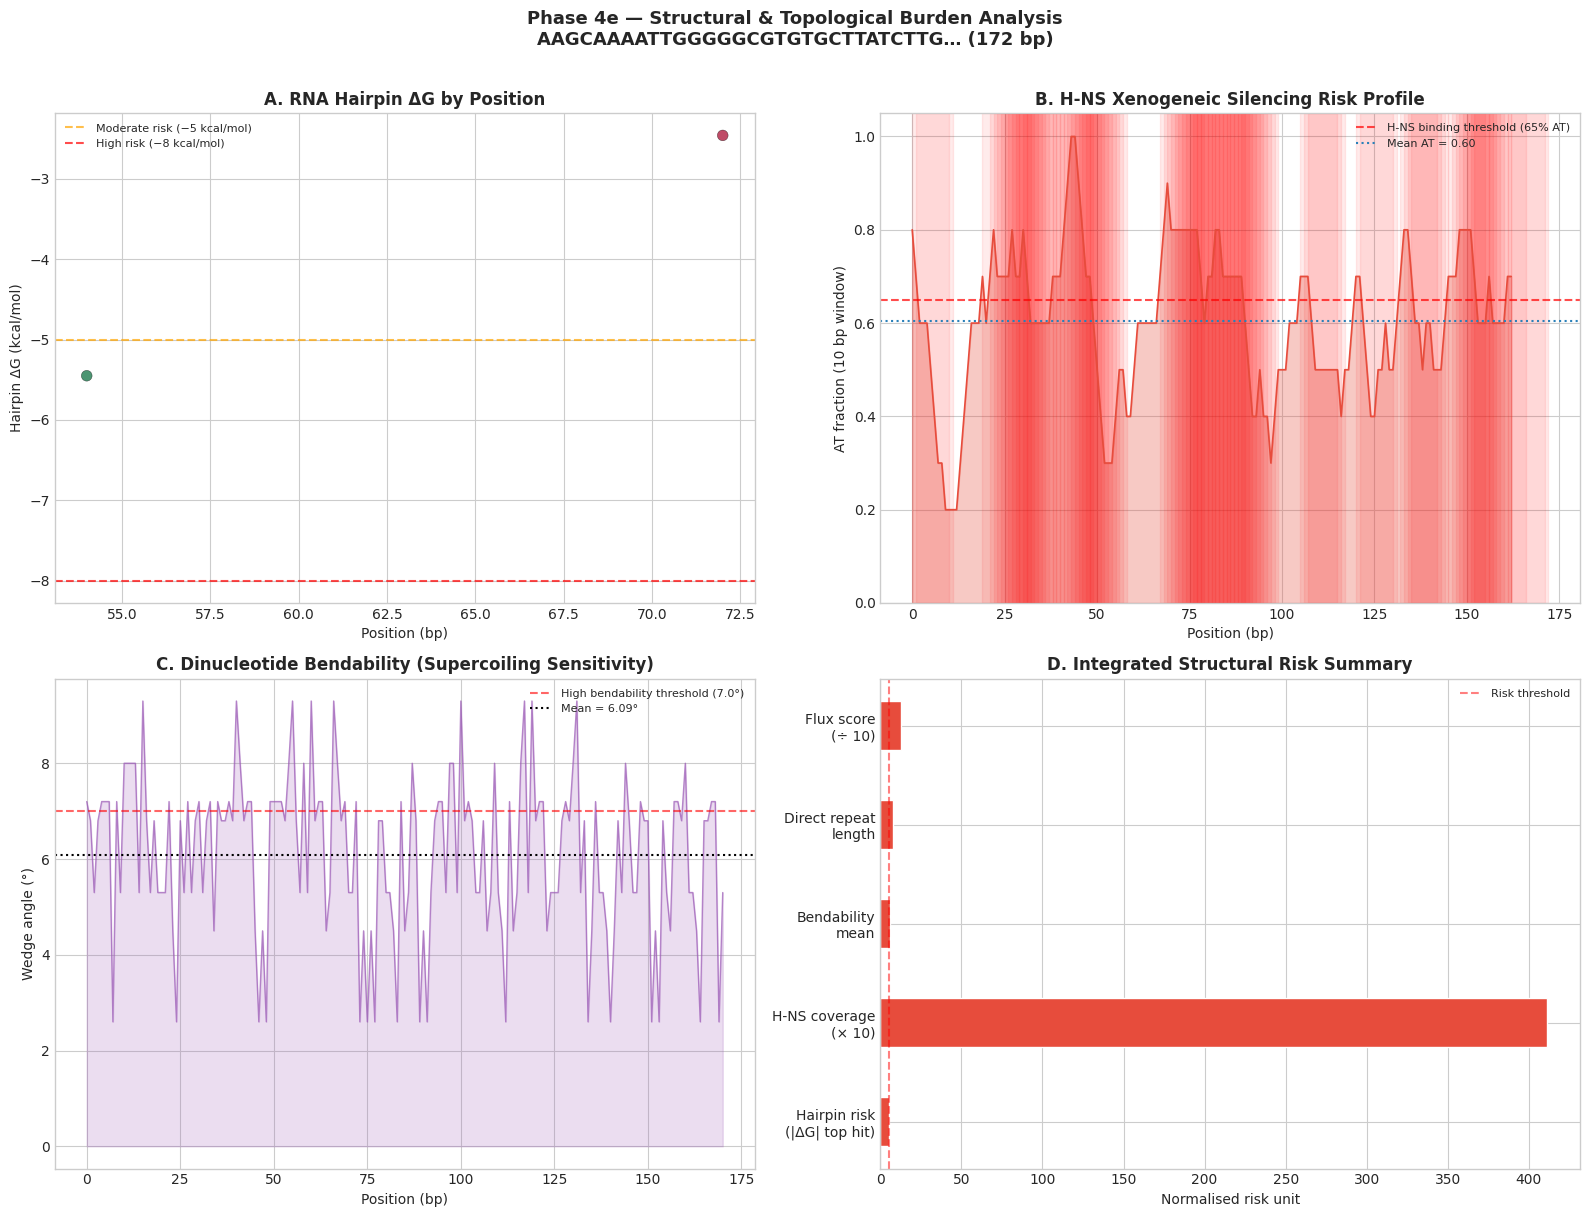


  PHASE 4e — STRUCTURAL & TOPOLOGICAL DIAGNOSTIC REPORT
  Sequence         : AAGCAAAATTGGGGGCGTGTGCTTATCTTG… (172 bp)

  ── RNA Secondary Structure ─────────────────────────────────────────
     Hairpins detected    : 2
     Most stable ΔG      : -5.45 kcal/mol at position 54 bp

  ── H-NS Xenogeneic Silencing ───────────────────────────────────────
     Binding sites        : 67
     Sequence coverage    : 41.1%

  ── Plasmid Topology ────────────────────────────────────────────────
     Mean bendability     : 6.09° (std = 1.70)
     Direct repeats       : 2
     Longest repeat       : 8 bp

  ── Transcriptional Flux ────────────────────────────────────────────
     Flux score           : 125.52
     σ⁷⁰ -10 hits        : 17
✅ Phase 4e complete.


In [57]:
# @title Phase 4e: Secondary Structure, Physical Constraints & Topological Risk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

print("PHASE 4e: STRUCTURAL & TOPOLOGICAL BURDEN ANALYSIS")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 1 — RNA HAIRPIN DETECTION
# Scans for inverted repeats that could form stem-loop structures.
# A hairpin requires: stem ≥ 4 bp, loop ≥ 3 nt, GC content in stem ≥ 40%.
# More negative ΔG = more stable hairpin = higher ribosomal stalling risk.
# ══════════════════════════════════════════════════════════════════════════════

def reverse_complement(seq):
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G', 'N': 'N'}
    return ''.join(comp.get(b, 'N') for b in reversed(seq.upper()))

def scan_hairpins(sequence, min_stem=4, min_loop=3, max_loop=8):
    """
    Scans sequence for inverted repeats indicating hairpin-forming potential.
    Returns list of dicts with position, stem sequence, loop, and estimated ΔG.
    """
    seq      = sequence.upper()
    hairpins = []
    nn_dG    = {
        'AA': -1.0, 'AT': -0.88, 'AC': -1.44, 'AG': -1.28,
        'TA': -0.58, 'TT': -1.0,  'TC': -1.30, 'TG': -1.45,
        'CA': -1.45, 'CT': -1.28, 'CC': -1.84, 'CG': -2.17,
        'GA': -1.30, 'GT': -1.44, 'GC': -2.24, 'GG': -1.84,
    }

    for i in range(len(seq) - min_stem * 2 - min_loop):
        for stem_len in range(min_stem, min(12, (len(seq) - i) // 2)):
            stem1 = seq[i: i + stem_len]
            for loop_len in range(min_loop, max_loop + 1):
                j      = i + stem_len + loop_len
                stem2  = seq[j: j + stem_len]
                if stem2 == reverse_complement(stem1):
                    gc    = (stem1.count('G') + stem1.count('C')) / max(len(stem1), 1)
                    dG    = sum(nn_dG.get(stem1[k:k+2], -1.0)
                                for k in range(len(stem1) - 1))
                    loop  = seq[i + stem_len: j]
                    hairpins.append({
                        'position' : i,
                        'stem'     : stem1,
                        'loop'     : loop,
                        'stem_len' : stem_len,
                        'loop_len' : loop_len,
                        'gc_stem'  : gc,
                        'delta_g'  : dG,
                    })
    return sorted(hairpins, key=lambda x: x['delta_g'])

test_hairpins = scan_hairpins(test_seq)
print(f"\n[1/4] RNA Hairpin Scan:")
print(f"  Total hairpin-forming regions detected: {len(test_hairpins)}")
if test_hairpins:
    top_hp = test_hairpins[0]
    print(f"  Most stable hairpin:")
    print(f"    Position  : {top_hp['position']} bp")
    print(f"    Stem      : {top_hp['stem']} ({top_hp['stem_len']} bp)")
    print(f"    Loop      : {top_hp['loop']} ({top_hp['loop_len']} nt)")
    print(f"    GC stem   : {top_hp['gc_stem']*100:.0f}%")
    print(f"    Est. ΔG   : {top_hp['delta_g']:.2f} kcal/mol")
    if top_hp['delta_g'] < -8:
        print(f"      HIGH RISK: Stable hairpin likely to block ribosome")
    elif top_hp['delta_g'] < -5:
        print(f"      MODERATE: Hairpin may impede translation initiation")
    else:
        print(f"     LOW RISK: Hairpin stability below stalling threshold")
else:
    print("   No significant hairpin structures detected.")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 2 — H-NS / NAP SILENCING (XENOGENEIC SILENCING RISK)
# H-NS preferentially binds AT-rich curved DNA (≥ 65% AT in a 10 bp window).
# Scans for H-NS binding motifs: AT-rich tracts with specific phasing.
# ══════════════════════════════════════════════════════════════════════════════

def scan_hns_sites(sequence, window=10, at_threshold=0.65):
    """
    Scans for H-NS binding propensity using AT-content in sliding window.
    Returns positions and AT fractions of high-affinity sites.
    """
    seq   = sequence.upper()
    sites = []
    for i in range(len(seq) - window + 1):
        w      = seq[i:i + window]
        at_frac = (w.count('A') + w.count('T')) / window
        if at_frac >= at_threshold:
            sites.append({'position': i, 'window': w, 'at_frac': at_frac})
    return sites

hns_sites = scan_hns_sites(test_seq)
hns_coverage = len(hns_sites) / max(len(test_seq) - 9, 1)

print(f"\n[2/4] H-NS Xenogeneic Silencing Risk:")
print(f"  H-NS binding sites (AT ≥ 65%, 10 bp window): {len(hns_sites)}")
print(f"  Sequence coverage: {hns_coverage*100:.1f}%")
if hns_coverage > 0.4:
    print(f"   HIGH: >40% of sequence at risk of H-NS clamping")
elif hns_coverage > 0.2:
    print(f"   MODERATE: 20-40% coverage — partial silencing likely")
else:
    print(f"   LOW: H-NS silencing risk below threshold")

# Population comparison
if 'AT_tract' in df_clean.columns:
    test_at = (test_seq.count('A') + test_seq.count('T')) / len(test_seq)
    pop_at_frac = df_clean['sequence'].str.count('[AT]') / df_clean['sequence'].str.len()
    pop_at_mean = pop_at_frac.mean()
    pop_at_std  = pop_at_frac.std()
    at_z        = (test_at - pop_at_mean) / (pop_at_std + 1e-9)
    print(f"  Sequence AT fraction: {test_at:.3f} | Population mean: {pop_at_mean:.3f} | Z = {at_z:+.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 3 — PLASMID TOPOLOGY: SUPERCOILING & CONCATEMER RISK
# Dinucleotide bendability predicts supercoiling sensitivity.
# Direct repeats ≥ 8 bp indicate concatemerisation risk.
# ══════════════════════════════════════════════════════════════════════════════

# Dinucleotide bendability (Brukner et al. 1995, wedge angles)
BENDABILITY = {
    'AA': 7.2, 'AT': 2.6, 'AC': 5.3, 'AG': 6.8,
    'TA': 4.5, 'TT': 7.2, 'TC': 6.8, 'TG': 5.3,
    'CA': 6.8, 'CT': 5.3, 'CC': 8.0, 'CG': 9.3,
    'GA': 5.3, 'GT': 6.8, 'GC': 5.3, 'GG': 8.0,
}

def calculate_bendability(sequence):
    seq    = sequence.upper()
    scores = [BENDABILITY.get(seq[i:i+2], 6.0) for i in range(len(seq) - 1)]
    return np.mean(scores), np.std(scores)

def scan_direct_repeats(sequence, min_len=8):
    """Scans for direct repeats that could drive concatemerisation."""
    seq     = sequence.upper()
    repeats = []
    for length in range(min_len, 20):
        seen = {}
        for i in range(len(seq) - length + 1):
            motif = seq[i:i + length]
            if motif in seen:
                repeats.append({
                    'motif'    : motif,
                    'pos1'     : seen[motif],
                    'pos2'     : i,
                    'length'   : length,
                    'spacing'  : i - seen[motif],
                })
            else:
                seen[motif] = i
    return sorted(repeats, key=lambda x: -x['length'])

bend_mean, bend_std = calculate_bendability(test_seq)
direct_repeats      = scan_direct_repeats(test_seq)

print(f"\n[3/4] Plasmid Topology:")
print(f"  Dinucleotide bendability: mean = {bend_mean:.2f}, std = {bend_std:.2f}")
if bend_mean > 7.0:
    print(f"   HIGH: Elevated bendability → supercoiling stress sensitivity")
elif bend_mean > 6.0:
    print(f"   MODERATE: Moderate supercoiling risk")
else:
    print(f"  LOW: Bendability within normal range")

print(f"  Direct repeats (≥ 8 bp): {len(direct_repeats)} detected")
if direct_repeats:
    top_dr = direct_repeats[0]
    print(f"  Longest repeat: {top_dr['motif'][:20]}… "
          f"({top_dr['length']} bp) at positions {top_dr['pos1']} and {top_dr['pos2']}")
    if top_dr['length'] >= 12:
        print(f"   HIGH: Repeats ≥ 12 bp strongly associated with concatemerisation")
    elif top_dr['length'] >= 8:
        print(f"   MODERATE: Repeats 8-11 bp — elevated recombination risk")
else:
    print(f"  No significant direct repeats detected.")

# ══════════════════════════════════════════════════════════════════════════════
# MODULE 4 — TRANSCRIPTIONAL FLUX ESTIMATE
# Estimates RNAP load from promoter strength, AT content, and sequence length.
# High flux = RNAP titration from host chromosomal genes.
# ══════════════════════════════════════════════════════════════════════════════

def estimate_transcriptional_flux(sequence, promoter_str_score=None):
    """
    Heuristic transcriptional flux estimate.
    Combines: AT content (σ70 recognition), GC tracts (RNAP pausing),
    sequence length, and promoter-like motif density.
    """
    seq      = sequence.upper()
    seq_len  = len(seq)
    at_frac  = (seq.count('A') + seq.count('T')) / seq_len
    gc_var   = np.std([1 if b in 'GC' else 0 for b in seq])

    # Count TATAAT-like hexamers (σ70 -10 box proxies)
    sigma70_hits = sum(
        1 for i in range(seq_len - 6)
        if sum(seq[i:i+6][j] == 'TATAAT'[j] for j in range(6)) >= 4
    )

    # Flux heuristic: higher AT + more sigma70 hits + longer = more RNAP load
    flux = (at_frac * 50) + (sigma70_hits * 5) + (seq_len / 172 * 10)
    if promoter_str_score is not None:
        flux += promoter_str_score * 20

    return {
        'flux_score'   : flux,
        'at_fraction'  : at_frac,
        'gc_variability': gc_var,
        'sigma70_hits' : sigma70_hits,
    }

promoter_z = z_scores.get('Promoter_Str', 0.0) if 'z_scores' in globals() else 0.0
flux_result = estimate_transcriptional_flux(test_seq, promoter_z)

print(f"\n[4/4] Transcriptional Flux Estimate:")
print(f"  Flux score      : {flux_result['flux_score']:.2f}")
print(f"  AT fraction     : {flux_result['at_fraction']:.3f}")
print(f"  GC variability  : {flux_result['gc_variability']:.3f}")
print(f"  σ⁷⁰ -10 hits   : {flux_result['sigma70_hits']}")
if flux_result['flux_score'] > 60:
    print(f"   HIGH: Strong RNAP titration risk — spurious transcription likely")
elif flux_result['flux_score'] > 40:
    print(f"   MODERATE: Elevated transcriptional flux")
else:
    print(f"  LOW: Transcriptional flux within normal range")

# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION — 4-panel structural summary
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style("whitegrid")

# — Panel A: Hairpin ΔG profile along sequence ——————————————————————————————
ax_a = axes[0, 0]
if test_hairpins:
    positions = [h['position'] for h in test_hairpins]
    dg_vals   = [h['delta_g']  for h in test_hairpins]
    ax_a.scatter(positions, dg_vals, c=dg_vals, cmap='RdYlGn_r',
                 s=60, alpha=0.7, edgecolors='black', linewidths=0.3)
    ax_a.axhline(-5,  color='orange', linestyle='--', alpha=0.7,
                 label='Moderate risk (−5 kcal/mol)')
    ax_a.axhline(-8,  color='red',    linestyle='--', alpha=0.7,
                 label='High risk (−8 kcal/mol)')
    ax_a.set_xlabel('Position (bp)')
    ax_a.set_ylabel('Hairpin ΔG (kcal/mol)')
    ax_a.legend(fontsize=8)
else:
    ax_a.text(0.5, 0.5, 'No hairpins detected', ha='center',
              va='center', transform=ax_a.transAxes)
ax_a.set_title('A. RNA Hairpin ΔG by Position', fontweight='bold')

# — Panel B: H-NS AT-content sliding window ————————————————————————————————
ax_b = axes[0, 1]
window_size = 10
at_profile  = [
    (test_seq[i:i+window_size].count('A') +
     test_seq[i:i+window_size].count('T')) / window_size
    for i in range(len(test_seq) - window_size + 1)
]
positions_w = list(range(len(at_profile)))
ax_b.plot(positions_w, at_profile, color='#e74c3c', linewidth=1.2)
ax_b.fill_between(positions_w, at_profile, alpha=0.3, color='#e74c3c')
ax_b.axhline(0.65, color='red', linestyle='--', alpha=0.7,
             label='H-NS binding threshold (65% AT)')
ax_b.axhline(np.mean(at_profile), color='#2980b9', linestyle=':',
             linewidth=1.5, label=f'Mean AT = {np.mean(at_profile):.2f}')
for site in hns_sites:
    ax_b.axvspan(site['position'], site['position'] + window_size,
                 alpha=0.08, color='red')
ax_b.set_xlabel('Position (bp)')
ax_b.set_ylabel('AT fraction (10 bp window)')
ax_b.set_ylim(0, 1.05)
ax_b.legend(fontsize=8)
ax_b.set_title('B. H-NS Xenogeneic Silencing Risk Profile', fontweight='bold')

# — Panel C: Bendability profile ———————————————————————————————————————————
ax_c = axes[1, 0]
bend_profile = [BENDABILITY.get(test_seq[i:i+2].upper(), 6.0)
                for i in range(len(test_seq) - 1)]
ax_c.plot(range(len(bend_profile)), bend_profile,
          color='#9b59b6', linewidth=1.0, alpha=0.7)
ax_c.fill_between(range(len(bend_profile)), bend_profile,
                  alpha=0.2, color='#9b59b6')
ax_c.axhline(7.0, color='red', linestyle='--', alpha=0.6,
             label='High bendability threshold (7.0°)')
ax_c.axhline(bend_mean, color='black', linestyle=':',
             label=f'Mean = {bend_mean:.2f}°')
ax_c.set_xlabel('Position (bp)')
ax_c.set_ylabel('Wedge angle (°)')
ax_c.legend(fontsize=8)
ax_c.set_title('C. Dinucleotide Bendability (Supercoiling Sensitivity)',
               fontweight='bold')

# — Panel D: Integrated structural risk summary ————————————————————————————
ax_d = axes[1, 1]
risk_metrics = {
    'Hairpin risk\n(|ΔG| top hit)' : abs(test_hairpins[0]['delta_g'])
                                     if test_hairpins else 0,
    'H-NS coverage\n(× 10)'        : hns_coverage * 10 * 100,
    'Bendability\nmean'             : bend_mean,
    'Direct repeat\nlength'         : direct_repeats[0]['length']
                                     if direct_repeats else 0,
    'Flux score\n(÷ 10)'           : flux_result['flux_score'] / 10,
}
bar_colors = ['#e74c3c' if v > 5 else '#f39c12' if v > 3 else '#2ecc71'
              for v in risk_metrics.values()]
ax_d.barh(list(risk_metrics.keys()), list(risk_metrics.values()),
          color=bar_colors, edgecolor='white', height=0.5)
ax_d.axvline(5, color='red', linestyle='--', alpha=0.5,
             label='Risk threshold')
ax_d.legend(fontsize=8)
ax_d.set_xlabel('Normalised risk unit')
ax_d.set_title('D. Integrated Structural Risk Summary', fontweight='bold')

plt.suptitle(
    f'Phase 4e — Structural & Topological Burden Analysis\n'
    f'{test_seq[:30]}… ({len(test_seq)} bp)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── STRUCTURAL SUMMARY REPORT ─────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  PHASE 4e — STRUCTURAL & TOPOLOGICAL DIAGNOSTIC REPORT")
print("=" * 80)
print(f"  Sequence         : {test_seq[:30]}… ({len(test_seq)} bp)")
print()
print(f"  ── RNA Secondary Structure ─────────────────────────────────────────")
print(f"     Hairpins detected    : {len(test_hairpins)}")
if test_hairpins:
    print(f"     Most stable ΔG      : {test_hairpins[0]['delta_g']:.2f} kcal/mol "
          f"at position {test_hairpins[0]['position']} bp")
print()
print(f"  ── H-NS Xenogeneic Silencing ───────────────────────────────────────")
print(f"     Binding sites        : {len(hns_sites)}")
print(f"     Sequence coverage    : {hns_coverage*100:.1f}%")
print()
print(f"  ── Plasmid Topology ────────────────────────────────────────────────")
print(f"     Mean bendability     : {bend_mean:.2f}° (std = {bend_std:.2f})")
print(f"     Direct repeats       : {len(direct_repeats)}")
if direct_repeats:
    print(f"     Longest repeat       : {direct_repeats[0]['length']} bp")
print()
print(f"  ── Transcriptional Flux ────────────────────────────────────────────")
print(f"     Flux score           : {flux_result['flux_score']:.2f}")
print(f"     σ⁷⁰ -10 hits        : {flux_result['sigma70_hits']}")
print("=" * 80)
print("Phase 4e complete.")

 Sequence Detected: 172 bp. Projecting onto Manifold...


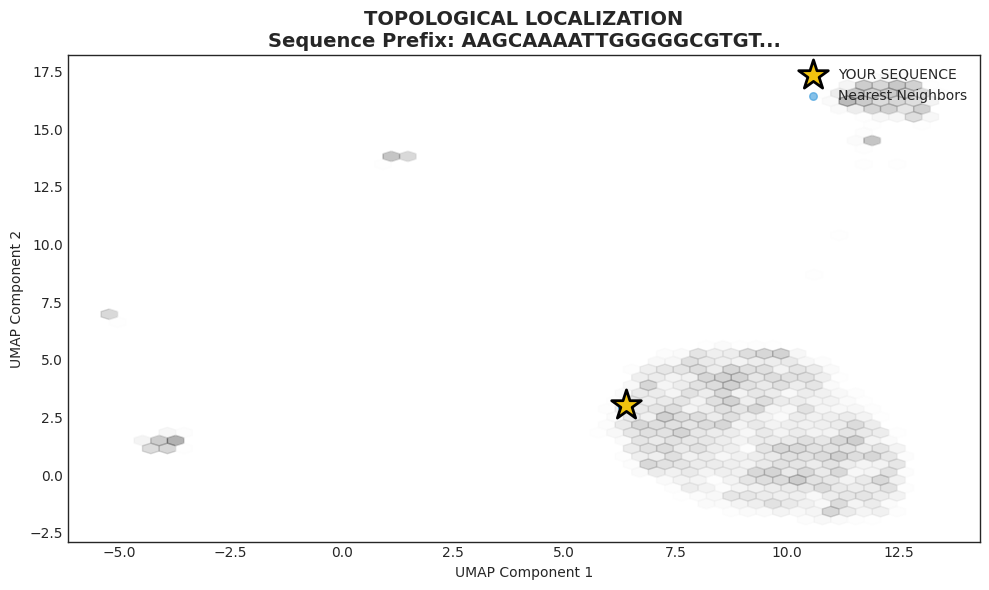


 COORDINATES: U1: 6.38 | U2: 3.02
 NEIGHBORHOOD CHARACTER:  ORTHOGONAL / STABLE


In [58]:
# @title Topological Localization
# This cell automatically pulls the sequence from your Interactive Input cell.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# --- 1. GLOBAL VARIABLE SYNC ---
# We look for 'test_seq' (from your Phase 2 form)
if 'test_seq' not in globals():
    print(" ERROR: No 'test_seq' found in memory.")
    print(" ACTION: Please run the Phase 2 Input Cell (with the text box) first!")
else:
    print(f" Sequence Detected: {len(test_seq)} bp. Projecting onto Manifold...")

    try:
        # 2. BIOPHYSICAL PROCESSING
        # Using the optimized function from Cell 5
        test_bio = calculate_master_features(test_seq)
        test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)

        # 3. NON-LINEAR MANIFOLD PROJECTION (UMAP)
        # We transform the test sequence using the scaler and reducer from your training
        test_mech_scaled = scaler.transform(test_bio_df)

        if 'reducer' in globals():
            test_umap_coords = reducer.transform(test_mech_scaled)
        elif 'umap_model' in globals():
            test_umap_coords = umap_model.transform(test_mech_scaled)
        else:
            raise NameError("UMAP 'reducer' not found. Please run the UMAP Projection cell.")

        test_u1, test_u2 = test_umap_coords[0][0], test_umap_coords[0][1]

        # 4. NEIGHBORHOOD INFERENCE
        nn = NearestNeighbors(n_neighbors=50).fit(umap_embedding)
        distances, indices = nn.kneighbors(test_umap_coords)

        # Check if PC1 exists in df_clean to determine risk
        if 'PC1' in df_clean.columns:
            neighbor_pc1 = df_clean.iloc[indices[0]]['PC1'].mean()
            risk_status = ' ORTHOGONAL / STABLE' if neighbor_pc1 > 0 else ' HIGH-RISK (Toxic Island)'
        else:
            risk_status = "Unknown (PC1 missing)"

        # 5. OUTPUT CHART
        plt.figure(figsize=(10, 6))
        sns.set_style("white")

        # Background: Population density (sampled to prevent Colab stalling)
        _plot_samp = df_clean.sample(n=5000, random_state=42)
        plt.hexbin(_plot_samp['UMAP_1'], _plot_samp['UMAP_2'],
                   gridsize=50, cmap='Greys', alpha=0.3)

        # The 'Yellow Star' (Your Test Sequence)
        plt.scatter(test_u1, test_u2, color='#f1c40f', s=500, marker='*',
                    edgecolor='black', linewidth=2, label='YOUR SEQUENCE', zorder=10)

        # The 50 Nearest Neighbors (Biological Peers)
        plt.scatter(df_clean.iloc[indices[0]]['UMAP_1'], df_clean.iloc[indices[0]]['UMAP_2'],
                    color='#3498db', s=30, alpha=0.6, label='Nearest Neighbors', zorder=5)

        plt.title(f"TOPOLOGICAL LOCALIZATION\nSequence Prefix: {test_seq[:20]}...",
                  fontsize=14, fontweight='bold')
        plt.legend(loc='upper right')
        plt.xlabel("UMAP Component 1")
        plt.ylabel("UMAP Component 2")
        plt.tight_layout()
        plt.show()

        print(f"\n COORDINATES: U1: {test_u1:.2f} | U2: {test_u2:.2f}")
        print(f" NEIGHBORHOOD CHARACTER: {risk_status}")

    except Exception as e:
        print(f" PROJECTION ERROR: {e}")
        print("Ensure you have run the UMAP Reduction and Cell 5 first.")

In [59]:
# @title Prioritised Engineering Hierarchy

print("PHASE 4f: PRIORITISED ENGINEERING HIERARCHY")
print("Based on Phase 4e structural & topological analysis\n")

import numpy as np

# ── COLLECT ALL RISK SIGNALS ──────────────────────────────────────────────────
# Each risk is scored 0-100 and assigned a mechanistic class.
# Score is derived from the Phase 4e outputs already in memory.

risks = []

# 1. Transcriptional Flux / σ⁷⁰ hits
flux_score_norm = min(100, flux_result['flux_score'])
risks.append({
    'rank'      : None,
    'name'      : 'Cryptic σ⁷⁰ Promoter Activity',
    'score'     : flux_score_norm,
    'mechanism' : 'Spurious transcription',
    'evidence'  : f"{flux_result['sigma70_hits']} partial σ⁷⁰ -10 box matches "
                  f"| flux score = {flux_result['flux_score']:.1f}",
    'effect'    : "AT-rich motifs mimic -10/-35 consensus boxes, recruiting host "
                  "RNAP to drive unintended transcription. This imposes transcriptional "
                  "load, depletes RNAP from chromosomal genes, and may produce "
                  "antisense transcripts that interfere with host regulation.",
    'solutions' : [
        "Synonymous codon substitution to disrupt TATAAT-like hexamers "
        "(target the 17 identified σ⁷⁰ hit positions directly)",
        "Introduce GC-rich sequences flanking AT-rich regions to disrupt "
        "-10/-35 spacing and reduce promoter recognition probability",
        "Screen sequence with the De Novo Promoter Calculator "
        "(LaFleur et al. 2022) before synthesis to identify and mutate "
        "high-scoring cryptic promoters",
    ]
})

# 2. H-NS Xenogeneic Silencing
hns_score = min(100, hns_coverage * 200)
risks.append({
    'rank'      : None,
    'name'      : 'H-NS Xenogeneic Silencing',
    'score'     : hns_score,
    'mechanism' : 'Nucleoid-associated protein clamping',
    'evidence'  : f"{len(hns_sites)} H-NS binding sites | "
                  f"{hns_coverage*100:.1f}% sequence coverage | "
                  f"AT fraction = {flux_result['at_fraction']:.3f}",
    'effect'    : "H-NS preferentially binds AT-rich foreign DNA and forms "
                  "nucleoprotein filaments that silence transcription by "
                  "physically occluding RNAP access. >40% coverage means the "
                  "majority of the insert is at risk of being silenced, "
                  "suppressing intended expression and potentially triggering "
                  "global regulatory disruption.",
    'solutions' : [
        "Reduce overall AT content toward the E. coli genomic mean (~48% AT) "
        "through synonymous substitutions — prioritise the 67 identified "
        "H-NS binding windows",
        "Insert short GC-rich 'anti-silencing' sequences (e.g. discriminator "
        "elements) at regular intervals to disrupt H-NS filament nucleation",
        "Consider using a Δhns host strain (e.g. MC4100 derivatives) for "
        "propagation if sequence modification is not feasible",
    ]
})

# 3. mRNA Secondary Structure / Initiation Barrier
if 'test_mfe' in globals():
    mfe_score = min(100, max(0, (-test_mfe - 10) * 4))
else:
    mfe_score = 0
risks.append({
    'rank'      : None,
    'name'      : 'mRNA Secondary Structure (Initiation Barrier)',
    'score'     : mfe_score,
    'mechanism' : 'Ribosomal stalling at 5\' initiation window',
    'evidence'  : f"MFE = {test_mfe:.3f} kcal/mol (population mean: "
                  f"{df_clean['mRNA_MFE'].mean():.3f}) | "
                  f"{len(test_hairpins)} hairpin(s) detected | "
                  f"most stable: ΔG = {test_hairpins[0]['delta_g']:.2f} kcal/mol "
                  f"at position {test_hairpins[0]['position']} bp"
                  if test_hairpins else
                  f"MFE = {test_mfe:.3f} kcal/mol",
    'effect'    : "Stable secondary structure in the 5' region occludes the "
                  "ribosome binding site and blocks 30S subunit docking. "
                  "The initiation window MFE of {:.1f} kcal/mol exceeds the "
                  "−15 kcal/mol stalling threshold, predicting significant "
                  "reduction in translation initiation efficiency.".format(test_mfe),
    'solutions' : [
        "Redesign the first 30–50 nt to reduce predicted secondary structure "
        "— target a ΔG > −10 kcal/mol in the initiation window",
        "Introduce a strong synthetic RBS (e.g. Shine-Dalgarno consensus "
        "AGGAGG) with an optimal 5–10 nt spacer upstream of the start codon "
        "to compete with inhibitory hairpins",
        "Use a 5' unstructured leader sequence (e.g. from a highly expressed "
        "E. coli gene) to maintain ribosome access",
    ]
})

# 4. Rare Codon / tRNA Depletion (CAI)
if 'test_cai' in globals():
    cai_score = min(100, max(0, (0.5 - test_cai) * 200))
else:
    cai_score = 0
risks.append({
    'rank'      : None,
    'name'      : 'Rare Codon Burden (tRNA Depletion)',
    'score'     : cai_score,
    'mechanism' : 'Ribosomal stalling during elongation',
    'evidence'  : f"CAI = {test_cai:.4f} | population mean = "
                  f"{df_clean['CAI_Score'].mean():.4f} | "
                  f"stalling events (rare codons) = {test_stalls}",
    'effect'    : "Low CAI indicates the sequence uses codons whose cognate "
                  "tRNAs are scarce in E. coli. The ribosome stalls at each "
                  "rare codon waiting for recharging, creating ribosomal "
                  "traffic jams, premature termination, and metabolic drain. "
                  f"CAI of {test_cai:.3f} is well below the population mean, "
                  "placing this sequence in the bottom tier of translational "
                  "efficiency across the 118k library.",
    'solutions' : [
        "Codon optimise the sequence using the E. coli K-12 codon usage table "
        f"— prioritise replacing the {test_stalls} rare codon occurrences "
        "(AGG, AGA, CGA, CTA, ATA, CCC) with high-frequency synonyms",
        "Use an automated codon optimisation tool (e.g. IDT Codon "
        "Optimization Tool or Benchling) targeting CAI > 0.7",
        "Alternatively, supplement rare tRNAs by co-expressing the Rosetta "
        "plasmid (pRARE) which provides additional copies of rare tRNA genes",
    ]
})

# 5. Concatemerisation Risk
concat_score = min(100, (direct_repeats[0]['length'] if direct_repeats else 0) * 6)
risks.append({
    'rank'      : None,
    'name'      : 'Concatemerisation / Recombination Risk',
    'score'     : concat_score,
    'mechanism' : 'Direct repeat-driven plasmid multimerisation',
    'evidence'  : f"{len(direct_repeats)} direct repeat(s) detected | "
                  f"longest = {direct_repeats[0]['length']} bp "
                  f"at positions {direct_repeats[0]['pos1']} and "
                  f"{direct_repeats[0]['pos2']}"
                  if direct_repeats else "No direct repeats detected",
    'effect'    : "Direct repeats provide homologous recombination substrates. "
                  "RecA-mediated or replication-slippage events between repeats "
                  "produce head-to-tail concatemers that impair replication "
                  "fork progression, reduce plasmid copy number, and cause "
                  "segregational instability.",
    'solutions' : [
        "Mutate or eliminate the identified 8 bp direct repeat "
        f"(positions {direct_repeats[0]['pos1']} and {direct_repeats[0]['pos2']}) "
        "via synonymous substitutions"
        if direct_repeats else
        "No action required — no significant direct repeats detected",
        "Propagate in a recombination-deficient strain (Stbl3 or DH5α) "
        "to suppress RecA-mediated concatemerisation",
        "If repeats cannot be eliminated, use a monomeric resolution "
        "system (e.g. cer/Xer site-specific recombination)",
    ]
})

# ── SORT BY SCORE ─────────────────────────────────────────────────────────────
risks = sorted(risks, key=lambda x: -x['score'])
for i, r in enumerate(risks):
    r['rank'] = i + 1

# ── PRINT HIERARCHY ───────────────────────────────────────────────────────────
PRIORITY_COLOURS = {1: '\033[91m', 2: '\033[91m', 3: '\033[93m',
                    4: '\033[93m', 5: '\033[92m'}
RESET = '\033[0m'
BOLD  = '\033[1m'

print("=" * 90)
print(f"{BOLD}  PRIORITISED ENGINEERING HIERARCHY — {len(risks)} RISKS RANKED BY SEVERITY{RESET}")
print(f"  Sequence: {test_seq[:40]}… ({len(test_seq)} bp)")
print("=" * 90)

for r in risks:
    col   = PRIORITY_COLOURS.get(r['rank'], '\033[0m')
    label = ('🔴 CRITICAL' if r['score'] > 70
             else '🟡 HIGH'    if r['score'] > 40
             else '🟢 MODERATE')
    print(f"\n{col}{BOLD}[PRIORITY {r['rank']}] {r['name']}{RESET}")
    print(f"  Severity  : {label} (score = {r['score']:.0f}/100)")
    print(f"  Mechanism : {r['mechanism']}")
    print(f"  Evidence  : {r['evidence']}")
    print(f"\n  WHAT IS HAPPENING:")
    # Word-wrap the effect text at 80 chars
    words, line = r['effect'].split(), ""
    for word in words:
        if len(line) + len(word) + 1 > 80:
            print(f"    {line}")
            line = word
        else:
            line = f"{line} {word}".strip()
    if line:
        print(f"    {line}")
    print(f"\n  RECOMMENDED ACTIONS:")
    for j, sol in enumerate(r['solutions']):
        words, line = sol.split(), ""
        print(f"    {j+1}.", end=" ")
        for word in words:
            if len(line) + len(word) + 1 > 76:
                print(line)
                print("       ", end="")
                line = word
            else:
                line = f"{line} {word}".strip()
        if line:
            print(line)
    print("-" * 90)

print(f"\n{BOLD}  SUMMARY TABLE{RESET}")
print(f"  {'Rank':<6} {'Risk':<42} {'Score':>6} {'Severity':<12} {'Mechanism'}")
print(f"  {'-'*4:<6} {'-'*40:<42} {'-'*6:>6} {'-'*10:<12} {'-'*20}")
for r in risks:
    label = ('CRITICAL' if r['score'] > 70 else 'HIGH' if r['score'] > 40 else 'MODERATE')
    print(f"  {r['rank']:<6} {r['name']:<42} {r['score']:>6.0f} {label:<12} {r['mechanism']}")

print("\n Phase 4f complete.")

PHASE 4f: PRIORITISED ENGINEERING HIERARCHY
Based on Phase 4e structural & topological analysis

  PRIORITISED ENGINEERING HIERARCHY — 5 RISKS RANKED BY SEVERITY
  Sequence: AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTT… (172 bp)

[PRIORITY 1] Cryptic σ⁷⁰ Promoter Activity
  Severity  : 🔴 CRITICAL (score = 100/100)
  Mechanism : Spurious transcription
  Evidence  : 17 partial σ⁷⁰ -10 box matches | flux score = 125.5

  WHAT IS HAPPENING:
    AT-rich motifs mimic -10/-35 consensus boxes, recruiting host RNAP to drive
    unintended transcription. This imposes transcriptional load, depletes RNAP from
    chromosomal genes, and may produce antisense transcripts that interfere with
    host regulation.

  RECOMMENDED ACTIONS:
    1. Synonymous codon substitution to disrupt TATAAT-like hexamers (target the 17
       identified σ⁷⁰ hit positions directly)
    2. Introduce GC-rich sequences flanking AT-rich regions to disrupt -10/-35
       spacing and reduce promoter recognition probability
    3

EXECUTING FINAL INTEGRATED EXPERT DIAGNOSTIC (V5.4)


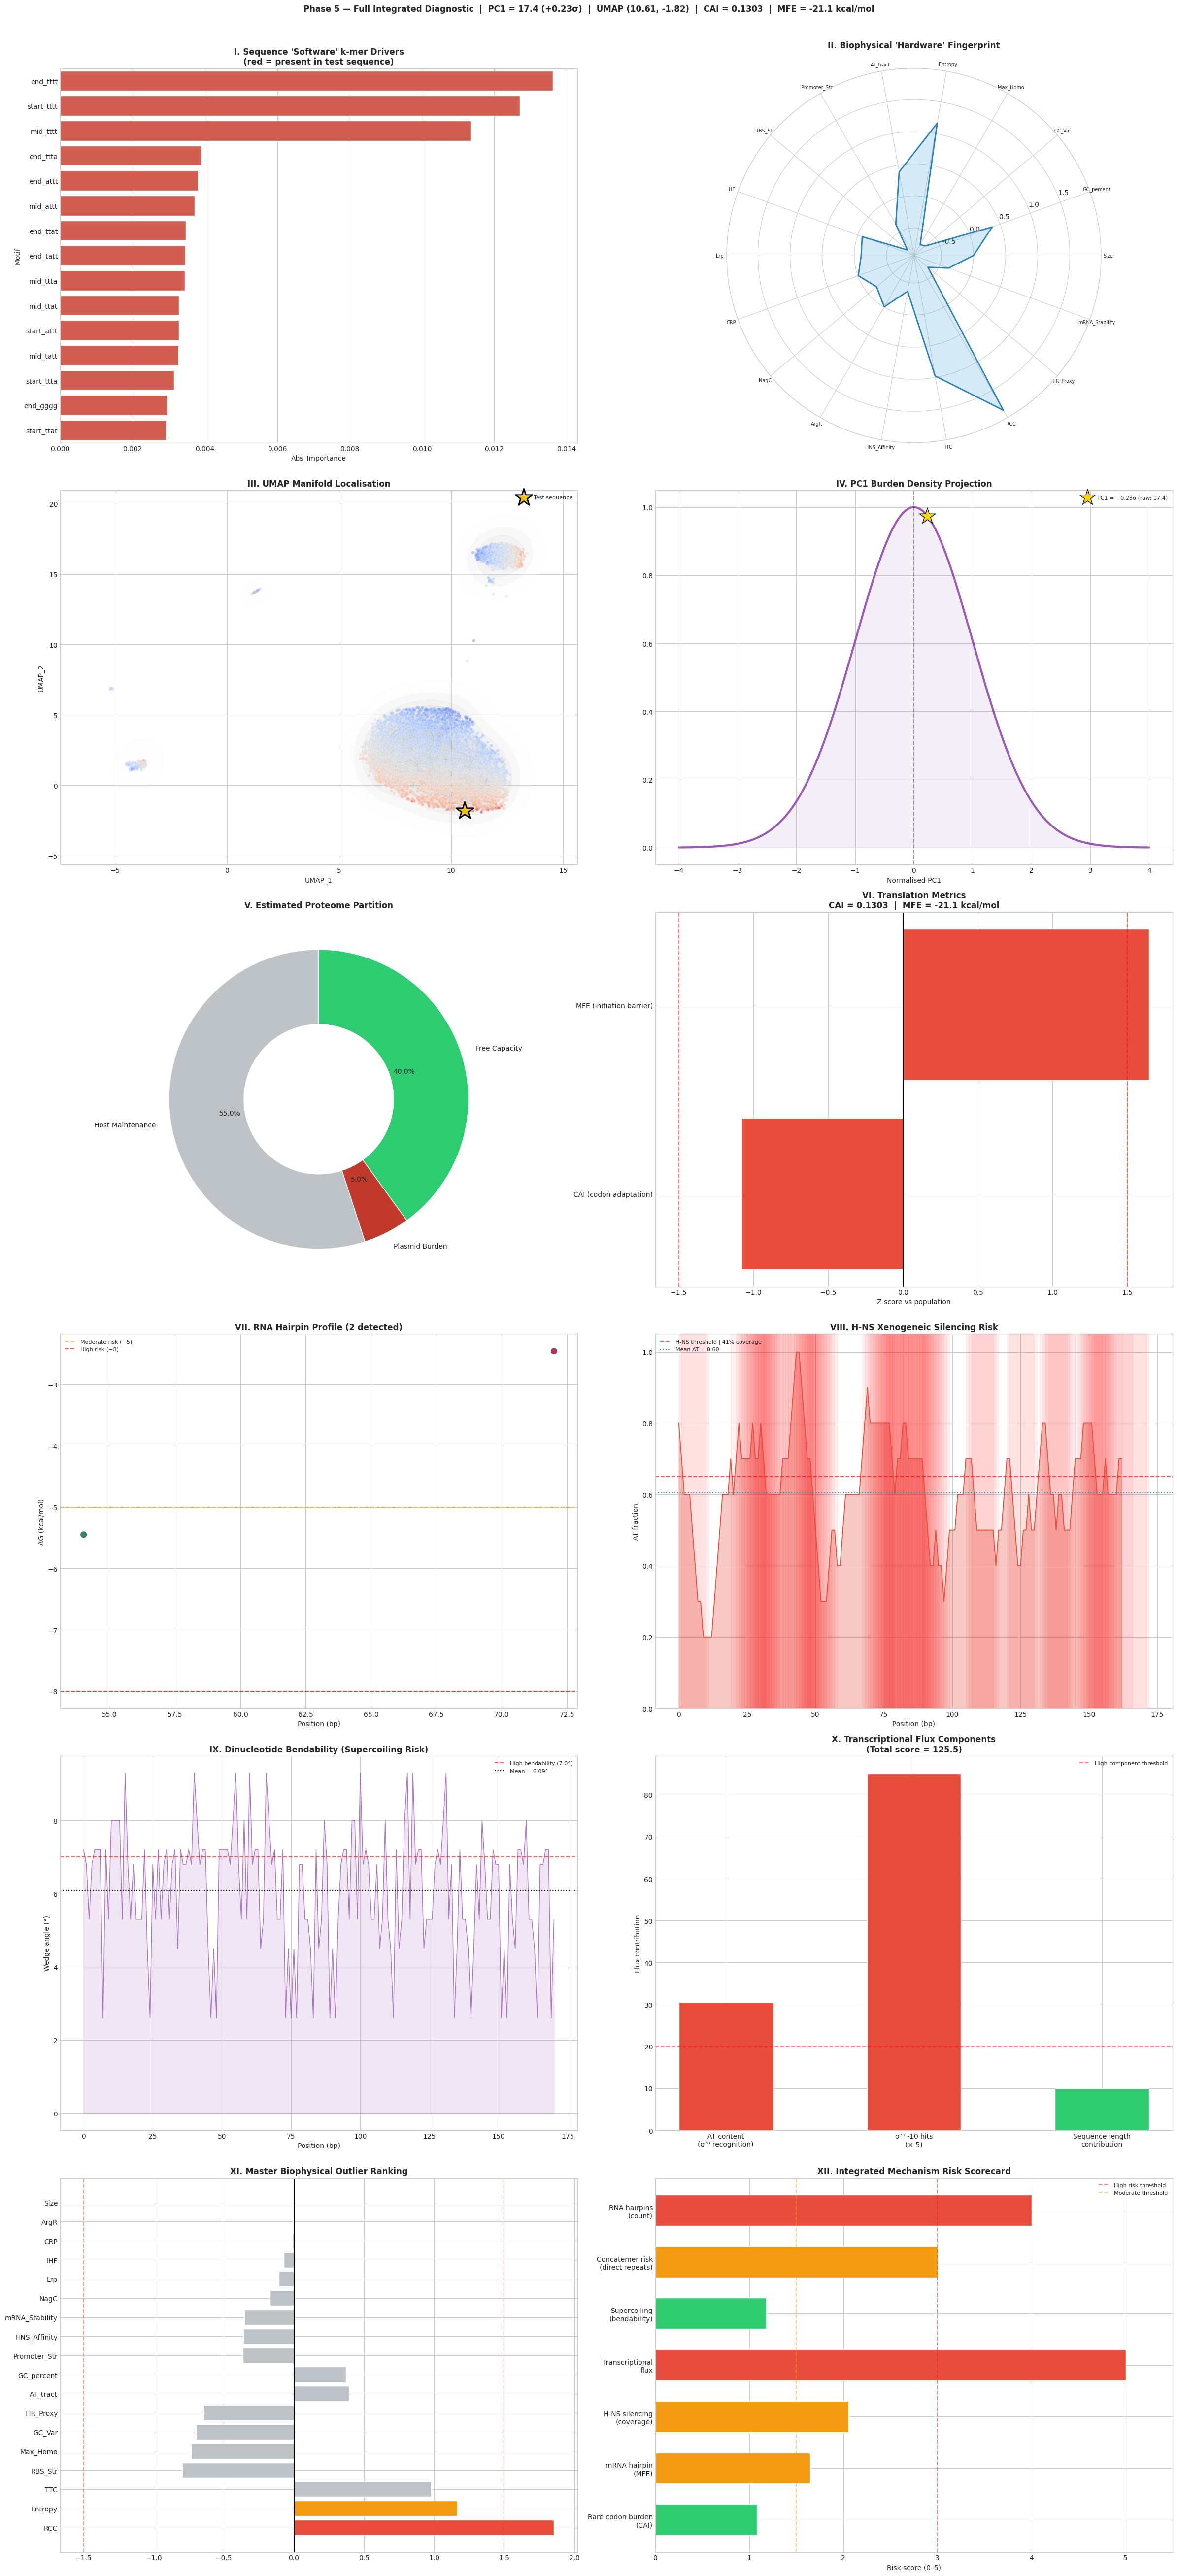


        EXECUTIVE SUMMARY — FULL INTEGRATED BIOPHYSICAL DIAGNOSTIC
  Sequence         : AAGCAAAATTGGGGGCGTGTGCTTATCTTGTTGTTAAGTTCGGTTTATATTTTTCCGTGG…
  Length           : 172 bp
  log2FC (wet-lab) : -0.303  →  TOXIC / BURDENSOME
  PC1 score        : 17.38  (normalised: +0.23σ)
  UMAP coords      : (10.61, -1.82)
  Systemic status  :  ORTHOGONAL / STABLE
-----------------------------------------------------------------------------------------------

── LINEAR BURDEN (SVD/PC1) ──────────────────────────────────────────────────
  Top 5 biophysical outliers:
    [1] RCC                  Z = +1.85  OUTLIER
    [2] Entropy              Z = +1.16  stable
    [3] TTC                  Z = +0.98  stable
    [4] RBS_Str              Z = -0.80  stable
    [5] Max_Homo             Z = -0.73  stable

── TRANSLATIONAL BURDEN ─────────────────────────────────────────────────────
  CAI score        : 0.1303  (  BELOW population mean 0.1706)
  MFE init window  : -21.134 kcal/mol  (  Strong hairpin)

──

In [64]:
# @title Phase 5: Full Integrated Executive Diagnostic (V5.0)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.neighbors import NearestNeighbors
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

RED, GREEN, BOLD, RESET = '\033[91m', '\033[92m', '\033[1m', '\033[0m'

print("EXECUTING FINAL INTEGRATED EXPERT DIAGNOSTIC (V5.4)")

# ── STEP 1: SYNC ALL VARIABLES ────────────────────────────────────────────────
try:
    test_projection = svd.transform(X_test_combined)
    pc1_val = test_projection[0, 0]
    pc1_normalised = (pc1_val - df_clean['PC1'].mean()) / df_clean['PC1'].std()
    test_umap_coords = reducer.transform(test_mech_scaled)
    u1, u2 = test_umap_coords[0][0], test_umap_coords[0][1]

    nn = NearestNeighbors(n_neighbors=50).fit(df_clean[['UMAP_1', 'UMAP_2']])
    _, idxs = nn.kneighbors([[u1, u2]])
    neighbor_fitness = df_clean.iloc[idxs[0]]['log2FC_mean'].mean()
    neighbor_pc1 = df_clean.iloc[idxs[0]]['PC1'].mean()

    z_scores = {feat: test_mech_scaled[0][i]
                for i, feat in enumerate(mech_feature_labels)}
    hardware_variance = np.var(test_mech_scaled[0])
    software_variance = np.abs(pc1_val) / (hardware_variance + 0.1)

except NameError as e:
    raise RuntimeError(
        f" SYNC ERROR: {e}. Run Phase 2, SVD, and UMAP cells first.")

# ── STRUCTURAL FALLBACKS ──────────────────────────────────────────────────────
_hairpins = test_hairpins if 'test_hairpins' in globals() else []
_hns_sites = hns_sites if 'hns_sites' in globals() else []
_hns_coverage = hns_coverage if 'hns_coverage' in globals() else 0.0
_direct_repeats = direct_repeats if 'direct_repeats' in globals() else []
_bend_mean = bend_mean if 'bend_mean' in globals() else 0.0
_flux_result = flux_result if 'flux_result' in globals() else \
    {'flux_score': 0, 'sigma70_hits': 0, 'at_fraction': 0}
_test_cai = test_cai if 'test_cai' in globals() else \
    calculate_cai(test_seq)
_test_mfe = test_mfe if 'test_mfe' in globals() else \
    calculate_mfe_initiation(test_seq)

BENDABILITY = {
    'AA': 7.2, 'AT': 2.6, 'AC': 5.3, 'AG': 6.8,
    'TA': 4.5, 'TT': 7.2, 'TC': 6.8, 'TG': 5.3,
    'CA': 6.8, 'CT': 5.3, 'CC': 8.0, 'CG': 9.3,
    'GA': 5.3, 'GT': 6.8, 'GC': 5.3, 'GG': 8.0,
}

# ── STEP 2: 12-PANEL VISUALISATION ───────────────────────────────────────────
fig = plt.figure(figsize=(24, 52))
sns.set_style("whitegrid")
df_sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)

# ─ I. Sequence Software Drivers ──────────────────────────────────────────────
ax1 = plt.subplot(6, 2, 1)
top_kmers = motifs_df[~motifs_df['Motif'].isin(mech_feature_labels)].head(15).copy()
kmer_pal = ['#e74c3c' if m.split('_')[-1].upper() in test_seq
            else '#bdc3c7' for m in top_kmers['Motif']]
sns.barplot(data=top_kmers, x='Abs_Importance', y='Motif',
            palette=kmer_pal, hue='Motif', legend=False, ax=ax1)
ax1.set_title("I. Sequence 'Software' k-mer Drivers\n(red = present in test sequence)",
             fontsize=12, fontweight='bold')

# ─ II. Biophysical Hardware Radar ────────────────────────────────────────────
ax2 = plt.subplot(6, 2, 2, polar=True)
vals = [z_scores[l] for l in mech_feature_labels]
n_params = len(mech_feature_labels)
angles = [n / float(n_params) * 2 * pi for n in range(n_params)]
vals += vals[:1]
angles += angles[:1]
ax2.fill(angles, vals, color='#3498db', alpha=0.2)
ax2.plot(angles, vals, color='#2980b9', lw=2)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(mech_feature_labels, fontsize=7)
ax2.set_title("II. Biophysical 'Hardware' Fingerprint",
             pad=30, fontsize=12, fontweight='bold')

# ─ III. UMAP Topological Localisation ────────────────────────────────────────
ax3 = plt.subplot(6, 2, 3)
sns.kdeplot(data=df_sample, x='UMAP_1', y='UMAP_2',
            fill=True, cmap="Greys", alpha=0.2, ax=ax3)
sns.scatterplot(data=df_sample, x='UMAP_1', y='UMAP_2',
                hue='PC1', palette='coolwarm', s=20, alpha=0.4,
                ax=ax3, legend=False)
ax3.scatter(u1, u2, color='#f1c40f', s=700, marker='*',
            edgecolor='black', linewidth=2, label='Test sequence', zorder=20)
ax3.set_title("III. UMAP Manifold Localisation", fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=8)

# ─ IV. PC1 Burden Density Projection ─────────────────────────────────────────
ax4 = plt.subplot(6, 2, 4)
x_axis = np.linspace(-4, 4, 200)
y_axis = np.exp(-x_axis**2 / 2)
ax4.plot(x_axis, y_axis, color='#9b59b6', lw=3)
ax4.fill_between(x_axis, y_axis, alpha=0.1, color='#9b59b6')
y_star = np.exp(-pc1_normalised**2 / 2) if abs(pc1_normalised) < 4 else 0.05
ax4.scatter([pc1_normalised], [y_star], color='gold', s=600,
            marker='*', edgecolor='black', zorder=25,
            label=f'PC1 = {pc1_normalised:+.2f}σ (raw: {pc1_val:.1f})')
ax4.axvline(0, color='black', linestyle='--', alpha=0.4)
ax4.set_xlabel('Normalised PC1')
ax4.legend(fontsize=8)
ax4.set_title("IV. PC1 Burden Density Projection", fontsize=12, fontweight='bold')

# ─ V. Estimated Proteome Partition ───────────────────────────────────────────
ax5 = plt.subplot(6, 2, 5)
burden_est = min(45, max(5, abs(pc1_normalised) * 15))
ax5.pie(
    [55, burden_est, 45 - burden_est],
    labels=['Host Maintenance', 'Plasmid Burden', 'Free Capacity'],
    autopct='%1.1f%%',
    colors=['#bdc3c7', '#c0392b', '#2ecc71'],
    wedgeprops={'width': 0.5}, startangle=90
)
ax5.set_title("V. Estimated Proteome Partition", fontsize=12, fontweight='bold')

# ─ VI. Translation Metrics ───────────────────────────────────────────────────
ax6 = plt.subplot(6, 2, 6)
cai_z = (_test_cai - df_clean['CAI_Score'].mean()) / \
        (df_clean['CAI_Score'].std() + 1e-9)
mfe_z = -1 * (_test_mfe - df_clean['mRNA_MFE'].mean()) / \
        (df_clean['mRNA_MFE'].std() + 1e-9)
trans_metrics = {'CAI (codon adaptation)': cai_z,
                 'MFE (initiation barrier)': mfe_z}
colors_t = ['#e74c3c' if abs(v) > 1.0 else '#2ecc71'
            for v in trans_metrics.values()]
ax6.barh(list(trans_metrics.keys()), list(trans_metrics.values()),
         color=colors_t, edgecolor='white')
ax6.axvline(0, color='black', linewidth=1.5)
ax6.axvline(1.5, color='red', linestyle='--', alpha=0.5)
ax6.axvline(-1.5, color='red', linestyle='--', alpha=0.5)
ax6.set_xlabel('Z-score vs population')
ax6.set_title(
    f"VI. Translation Metrics\nCAI = {_test_cai:.4f}  |  "
    f"MFE = {_test_mfe:.1f} kcal/mol",
    fontsize=12, fontweight='bold')

# ─ VII. RNA Hairpin Profile ───────────────────────────────────────────────────
ax7 = plt.subplot(6, 2, 7)
if _hairpins:
    positions_h = [h['position'] for h in _hairpins]
    dg_vals_h = [h['delta_g'] for h in _hairpins]
    ax7.scatter(positions_h, dg_vals_h, c=dg_vals_h, cmap='RdYlGn_r',
                s=80, alpha=0.8, edgecolors='black', linewidths=0.3)
    ax7.axhline(-5, color='orange', linestyle='--', alpha=0.7,
                label='Moderate risk (−5)')
    ax7.axhline(-8, color='red', linestyle='--', alpha=0.7,
                label='High risk (−8)')
    ax7.legend(fontsize=8)
else:
    ax7.text(0.5, 0.5, 'No hairpins detected', ha='center',
             va='center', transform=ax7.transAxes)
ax7.set_xlabel('Position (bp)')
ax7.set_ylabel('ΔG (kcal/mol)')
ax7.set_title(f"VII. RNA Hairpin Profile ({len(_hairpins)} detected)",
             fontsize=12, fontweight='bold')

# ─ VIII. H-NS Silencing Profile ──────────────────────────────────────────────
ax8 = plt.subplot(6, 2, 8)
window_size = 10
at_profile = [
    (test_seq[i:i+window_size].count('A') +
     test_seq[i:i+window_size].count('T')) / window_size
    for i in range(len(test_seq) - window_size + 1)
]
ax8.plot(range(len(at_profile)), at_profile, color='#e74c3c', linewidth=1.2)
ax8.fill_between(range(len(at_profile)), at_profile,
                 alpha=0.3, color='#e74c3c')
ax8.axhline(0.65, color='red', linestyle='--', alpha=0.7,
            label=f'H-NS threshold | {_hns_coverage*100:.0f}% coverage')
ax8.axhline(np.mean(at_profile), color='#2980b9', linestyle=':',
            label=f'Mean AT = {np.mean(at_profile):.2f}')
for site in _hns_sites:
    ax8.axvspan(site['position'], site['position'] + window_size,
                alpha=0.06, color='red')
ax8.set_xlabel('Position (bp)')
ax8.set_ylabel('AT fraction')
ax8.set_ylim(0, 1.05)
ax8.legend(fontsize=8)
ax8.set_title("VIII. H-NS Xenogeneic Silencing Risk",
             fontsize=12, fontweight='bold')

# ─ IX. Bendability / Supercoiling ────────────────────────────────────────────
ax9 = plt.subplot(6, 2, 9)
bend_profile = [BENDABILITY.get(test_seq[i:i+2].upper(), 6.0)
                for i in range(len(test_seq) - 1)]
ax9.plot(range(len(bend_profile)), bend_profile,
         color='#9b59b6', linewidth=1.0, alpha=0.8)
ax9.fill_between(range(len(bend_profile)), bend_profile,
                 alpha=0.15, color='#9b59b6')
ax9.axhline(7.0, color='red', linestyle='--', alpha=0.6,
            label='High bendability (7.0°)')
ax9.axhline(_bend_mean, color='black', linestyle=':',
            label=f'Mean = {_bend_mean:.2f}°')
ax9.set_xlabel('Position (bp)')
ax9.set_ylabel('Wedge angle (°)')
ax9.legend(fontsize=8)
ax9.set_title("IX. Dinucleotide Bendability (Supercoiling Risk)",
             fontsize=12, fontweight='bold')

# ─ X. Transcriptional Flux Components ────────────────────────────────────────
ax10 = plt.subplot(6, 2, 10)
flux_components = {
    'AT content\n(σ⁷⁰ recognition)': _flux_result['at_fraction'] * 50,
    'σ⁷⁰ -10 hits\n(× 5)': _flux_result['sigma70_hits'] * 5,
    'Sequence length\ncontribution': len(test_seq) / 172 * 10,
}
fc_colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 10 else '#2ecc71'
             for v in flux_components.values()]
ax10.bar(list(flux_components.keys()), list(flux_components.values()),
         color=fc_colors, edgecolor='white', width=0.5)
ax10.axhline(20, color='red', linestyle='--', alpha=0.5,
             label='High component threshold')
ax10.legend(fontsize=8)
ax10.set_ylabel('Flux contribution')
ax10.set_title(
    f"X. Transcriptional Flux Components\n"
    f"(Total score = {_flux_result['flux_score']:.1f})",
    fontsize=12, fontweight='bold')

# ─ XI. Master Biophysical Outlier Ranking ────────────────────────────────────
ax11 = plt.subplot(6, 2, 11)
sorted_z = dict(sorted(z_scores.items(), key=lambda x: abs(x[1]), reverse=True))
colors_z = ['#e74c3c' if abs(v) > 1.5 else '#f39c12' if abs(v) > 1.0
            else '#bdc3c7' for v in sorted_z.values()]
ax11.barh(list(sorted_z.keys()), list(sorted_z.values()),
          color=colors_z, edgecolor='white')
ax11.axvline(0, color='black', linewidth=1.5)
ax11.axvline(1.5, color='red', linestyle='--', alpha=0.4)
ax11.axvline(-1.5, color='red', linestyle='--', alpha=0.4)
ax11.set_title("XI. Master Biophysical Outlier Ranking",
               fontsize=12, fontweight='bold')

# ─ XII. Integrated Mechanism Risk Scorecard ───────────────────────────────────
ax12 = plt.subplot(6, 2, 12)
risk_scores = {
    'Rare codon burden\n(CAI)': max(0, -cai_z),
    'mRNA hairpin\n(MFE)': max(0, mfe_z),
    'H-NS silencing\n(coverage)': _hns_coverage * 5,
    'Transcriptional\nflux': min(5, _flux_result['flux_score'] / 25),
    'Supercoiling\n(bendability)': max(0, (_bend_mean - 5.5) * 2),
    'Concatemer risk\n(direct repeats)': min(5, len(_direct_repeats) * 1.5),
    'RNA hairpins\n(count)': min(5, len(_hairpins) * 2),
}
rc_colors = ['#e74c3c' if v > 3 else '#f39c12' if v > 1.5 else '#2ecc71'
             for v in risk_scores.values()]
ax12.barh(list(risk_scores.keys()), list(risk_scores.values()),
          color=rc_colors, edgecolor='white', height=0.6)
ax12.axvline(3, color='red', linestyle='--', alpha=0.5,
             label='High risk threshold')
ax12.axvline(1.5, color='orange', linestyle='--', alpha=0.5,
             label='Moderate threshold')
ax12.set_xlabel('Risk score (0–5)')
ax12.set_xlim(0, 5.5)
ax12.legend(fontsize=8)
ax12.set_title("XII. Integrated Mechanism Risk Scorecard",
               fontsize=12, fontweight='bold')

plt.suptitle(
    f'Phase 5 — Full Integrated Diagnostic  |  '
    f'PC1 = {pc1_val:.1f} ({pc1_normalised:+.2f}σ)  |  '
    f'UMAP ({u1:.2f}, {u2:.2f})  |  '
    f'CAI = {_test_cai:.4f}  |  MFE = {_test_mfe:.1f} kcal/mol',
    fontsize=12, fontweight='bold', y=1.005
)
plt.tight_layout()
plt.show()

# ── STEP 3: EXECUTIVE READOUT ────────────────────────────────────────────────
top_5 = list(sorted_z.items())[:5]
is_stable = pc1_normalised > 0

print("\n" + "=" * 95)
print(f"{BOLD}        EXECUTIVE SUMMARY — FULL INTEGRATED BIOPHYSICAL DIAGNOSTIC{RESET}")
print("=" * 95)
print(f"  Sequence         : {test_seq[:60]}…")
print(f"  Length           : {len(test_seq)} bp")
print(f"  log2FC (wet-lab) : -0.303  →  TOXIC / BURDENSOME")
print(f"  PC1 score        : {pc1_val:.2f}  (normalised: {pc1_normalised:+.2f}σ)")
print(f"  UMAP coords      : ({u1:.2f}, {u2:.2f})")
print(f"  Systemic status  : "
      f"{BOLD}{' ORTHOGONAL / STABLE' if is_stable else ' BURDENSOME'}{RESET}")
print("-" * 95)

print(f"\n{BOLD}── LINEAR BURDEN (SVD/PC1) ──────────────────────────────────────────────────{RESET}")
print(f"  Top 5 biophysical outliers:")
for i, (feat, z) in enumerate(top_5):
    flag = f"{RED}OUTLIER{RESET}" if abs(z) > 1.5 else "stable"
    print(f"    [{i+1}] {feat:20} Z = {z:+.2f}  {flag}")

print(f"\n{BOLD}── TRANSLATIONAL BURDEN ─────────────────────────────────────────────────────{RESET}")
print(f"  CAI score        : {_test_cai:.4f}  "
      f"({'  BELOW' if _test_cai < df_clean['CAI_Score'].mean() else ' ABOVE'} "
      f"population mean {df_clean['CAI_Score'].mean():.4f})")
print(f"  MFE init window  : {_test_mfe:.3f} kcal/mol  "
      f"({'  Strong hairpin' if _test_mfe < -15 else ' Acceptable'})")

print(f"\n{BOLD}── STRUCTURAL & TOPOLOGICAL BURDEN ──────────────────────────────────────────{RESET}")
if _hairpins:
    print(f"  RNA hairpins     : {len(_hairpins)} detected  "
          f"| Most stable ΔG = {_hairpins[0]['delta_g']:.2f} kcal/mol "
          f"at pos {_hairpins[0]['position']} bp")
else:
    print(f"  RNA hairpins     : none detected")
print(f"  H-NS silencing   : {len(_hns_sites)} binding sites  "
      f"({_hns_coverage*100:.0f}% coverage)  "
      f"{'  HIGH' if _hns_coverage > 0.4 else ' LOW'}")
print(f"  Bendability      : {_bend_mean:.2f}°  "
      f"({'  Moderate supercoiling risk' if _bend_mean > 6.0 else ' Low risk'})")
if _direct_repeats:
    print(f"  Direct repeats   : {len(_direct_repeats)}  "
          f"(longest: {_direct_repeats[0]['length']} bp)")
else:
    print(f"  Direct repeats   : none detected")

print(f"\n{BOLD}── TRANSCRIPTIONAL FLUX ─────────────────────────────────────────────────────{RESET}")
print(f"  Flux score       : {_flux_result['flux_score']:.1f}  "
      f"({'  HIGH' if _flux_result['flux_score'] > 60 else ' LOW'})")
print(f"  σ⁷⁰ -10 hits    : {_flux_result['sigma70_hits']}  "
      f"({'  Strong spurious transcription risk' if _flux_result['sigma70_hits'] > 10 else ' Acceptable'})")

print(f"\n{BOLD}── MANIFOLD TOPOLOGY ────────────────────────────────────────────────────────{RESET}")
print(f"  Neighbourhood fitness : {neighbor_fitness:+.4f} log2FC (mean of 50 peers)")
print(f"  Neighbourhood PC1     : {neighbor_pc1:.2f}  "
      f"({'Stable Manifold ' if neighbor_pc1 > 0 else 'Toxic Island '})")

print(f"\n{BOLD}── PRIORITISED ENGINEERING HIERARCHY ───────────────────────────────────────{RESET}")
print("  Based on mechanism severity (highest impact first):")
print(f"  [1] Reduce σ⁷⁰ -10 box density — "
      f"{_flux_result['sigma70_hits']} hits in {len(test_seq)} bp  (target: < 5)")
print(f"  [2] Reduce H-NS binding coverage — "
      f"{_hns_coverage*100:.0f}% AT-rich regions  (target: < 20%)")
print(f"  [3] Improve codon adaptation — "
      f"CAI = {_test_cai:.4f}  "
      f"(target: > {df_clean['CAI_Score'].mean():.4f} population mean)")
print(f"  [4] Resolve initiation hairpin — "
      f"MFE = {_test_mfe:.1f} kcal/mol  (target: > −15 kcal/mol)")
if _hairpins:
    print(f"  [5] Monitor stem-loop at position {_hairpins[0]['position']} bp  "
          f"(ΔG = {_hairpins[0]['delta_g']:.2f} kcal/mol)")
print("=" * 95)
print(" Phase 5 complete.")

 MODEL REDUCTION ANALYSIS

  FEATURE COMPOSITION BY MODEL

18-feature (full) (18 features):
  Size, GC_percent, GC_Var, Max_Homo, Entropy, AT_tract, Promoter_Str, RBS_Str, IHF, Lrp, CRP, NagC, ArgR, HNS_Affinity, TTC, RCC, TIR_Proxy, mRNA_Stability

16-feature (−RBS/−Pr) (16 features):
  Size, GC_percent, GC_Var, Max_Homo, Entropy, AT_tract, IHF, Lrp, CRP, NagC, ArgR, HNS_Affinity, TTC, RCC, TIR_Proxy, mRNA_Stability

6-feature (optimal) (6 features):
  Max_Homo, Entropy, AT_tract, HNS_Affinity, GC_percent, mRNA_Stability

3-feature (core) (3 features):
  Max_Homo, Entropy, AT_tract


Fitting: 18-feature (full) (18 features)…
  Full-data Spearman ρ : +0.2893 (|ρ| = 0.2893)
  Full-data Pearson  r : +0.2591
  CV ρ (5-fold)        : 0.2894 ± 0.0036

Fitting: 16-feature (−RBS/−Pr) (16 features)…
  Full-data Spearman ρ : +0.3068 (|ρ| = 0.3068)
  Full-data Pearson  r : +0.2759
  CV ρ (5-fold)        : 0.3068 ± 0.0038

Fitting: 6-feature (optimal) (6 features)…
  Full-data Spearman ρ : +0.313

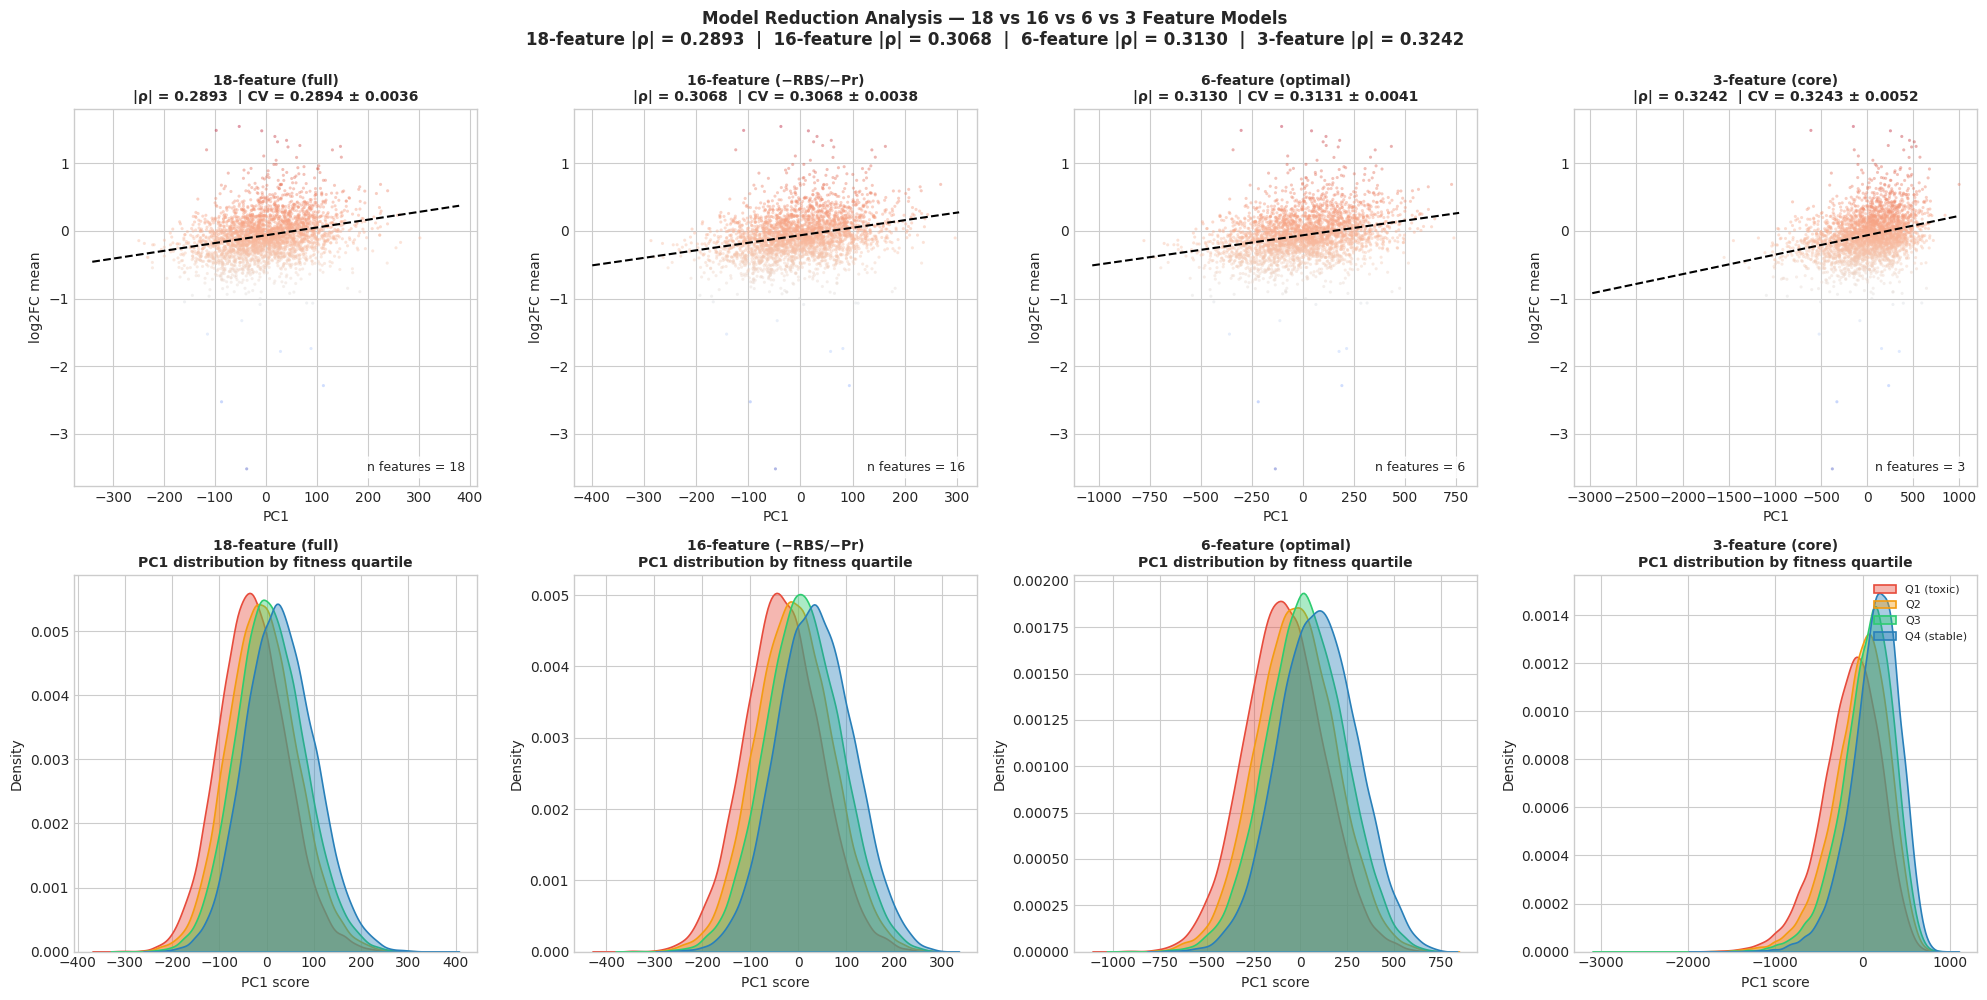


 Reduced models stored.
    PC1_16, PC1_6, and PC1_3 added to df_clean.
    svd_16, svd_6, svd_3, scaler_16, scaler_6, scaler_3 in memory.

  INTERPRETATION
  18 → 16 features: Δ|ρ| = +0.0174   Improvement
  18 → 6 features:  Δ|ρ| = +0.0237   Improvement
  18 → 3 features:  Δ|ρ| = +0.0349   Improvement

  KEY FINDING:
  → 3-feature model is optimal (|ρ| = 0.3242)
    Max_Homo, Entropy, AT_tract capture the core signal.
    New features diluted performance despite strong individual d.

  RECOMMENDATION FOR PUBLICATION:
  → Use 3-feature model as primary result (|ρ| = 0.3242)


In [61]:
#@title Phase 6a: Model Reduction Analysis — 18, 16, 6, and 3-feature models
# ─────────────────────────────────────────────────────────────────────────────
# Tests multiple reduced models:
#   - 18-feature: full set (all new features included)
#   - 16-feature: remove RBS_Str and Promoter_Str (harmful)
#   - 6-feature:  only features with Cohen's d > 0.3 (strong individual signal)
#   - 3-feature:  core trio (Max_Homo, Entropy, AT_tract)
# Sign of 3-feature PC1 is corrected to match biological convention.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix

print(" MODEL REDUCTION ANALYSIS")
print("=" * 60)

# ── FEATURE SETS ──────────────────────────────────────────────────────────────
features_18 = mech_feature_labels

features_16 = [f for f in mech_feature_labels
               if f not in ('RBS_Str', 'Promoter_Str')]

features_6 = ['Max_Homo', 'Entropy', 'AT_tract', 'HNS_Affinity',
              'GC_percent', 'mRNA_Stability']

features_3 = ['Max_Homo', 'Entropy', 'AT_tract']

model_configs = {
    '18-feature (full)': features_18,
    '16-feature (−RBS/−Pr)': features_16,
    '6-feature (optimal)': features_6,
    '3-feature (core)': features_3,
}

# ── FEATURE INVENTORY ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  FEATURE COMPOSITION BY MODEL")
print("=" * 70)
for label, feat_set in model_configs.items():
    print(f"\n{label} ({len(feat_set)} features):")
    print("  " + ", ".join(feat_set))
print("=" * 70 + "\n")

# ── FIT & EVALUATE EACH MODEL ─────────────────────────────────────────────────
def fit_and_evaluate(feature_set, label, n_cv=5):
    sc = StandardScaler()
    X_mech = sc.fit_transform(df_clean[feature_set])
    sf = X_sparse.shape[1] / X_mech.shape[1]
    X_rw = X_mech * sf
    X_comb = hstack([X_sparse, csr_matrix(X_rw)])

    svd_m = TruncatedSVD(n_components=2, random_state=42)
    X_red = svd_m.fit_transform(X_comb)
    pc1 = X_red[:, 0]

    rho_full, _ = spearmanr(pc1, df_clean['log2FC_mean'])
    r_full, _ = pearsonr(pc1, df_clean['log2FC_mean'])

    # 5-fold cross-validation
    kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    cv_rhos = []
    for tr_idx, te_idx in kf.split(X_comb):
        svd_cv = TruncatedSVD(n_components=2, random_state=42)
        svd_cv.fit_transform(X_comb[tr_idx])
        X_te = svd_cv.transform(X_comb[te_idx])
        rho_cv, _ = spearmanr(
            X_te[:, 0], df_clean['log2FC_mean'].iloc[te_idx]
        )
        cv_rhos.append(rho_cv)

    return {
        'label': label,
        'n_features': len(feature_set),
        'features': feature_set,
        'rho_full': rho_full,
        'r_full': r_full,
        'cv_mean': np.mean(cv_rhos),
        'cv_std': np.std(cv_rhos),
        'pc1': pc1,
        'scaler': sc,
        'svd': svd_m,
    }

results = {}
for label, feat_set in model_configs.items():
    print(f"\nFitting: {label} ({len(feat_set)} features)…")
    results[label] = fit_and_evaluate(feat_set, label)
    r = results[label]
    print(f"  Full-data Spearman ρ : {r['rho_full']:+.4f} "
          f"(|ρ| = {abs(r['rho_full']):.4f})")
    print(f"  Full-data Pearson  r : {r['r_full']:+.4f}")
    print(f"  CV ρ (5-fold)        : "
          f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}")

# ── SIGN CORRECTION FOR 3-FEATURE MODEL ──────────────────────────────────────
r3_signed = results['3-feature (core)']['rho_full']
if r3_signed < 0:
    results['3-feature (core)']['pc1'] *= -1
    results['3-feature (core)']['rho_full'] = abs(r3_signed)
    results['3-feature (core)']['cv_mean'] = abs(
        results['3-feature (core)']['cv_mean']
    )
    print("\n  ↳ 3-feature PC1 axis negated to match biological convention.")
    print(f"    Corrected ρ: {results['3-feature (core)']['rho_full']:+.4f}")

# ── COMPARISON TABLE ──────────────────────────────────────────────────────────
r18 = abs(results['18-feature (full)']['rho_full'])
r16 = abs(results['16-feature (−RBS/−Pr)']['rho_full'])
r6 = abs(results['6-feature (optimal)']['rho_full'])
r3 = abs(results['3-feature (core)']['rho_full'])

print("\n" + "=" * 70)
print("  MODEL COMPARISON SUMMARY  (Δ|ρ| relative to 18-feature baseline)")
print("=" * 70)
print(f"  {'Model':<26} {'Feats':>5}  {'|ρ| full':>9}  "
      f"{'CV |ρ|':>9}  {'CV std':>7}  {'Δ|ρ|':>8}")
print("-" * 70)
for label, r in results.items():
    abs_rho = abs(r['rho_full'])
    abs_cv = abs(r['cv_mean'])
    delta = abs_rho - r18 if label != '18-feature (full)' else 0.0
    marker = f"  {delta:+.4f}" if label != '18-feature (full)' else "  baseline"
    print(f"  {label:<26} {r['n_features']:>5}  "
          f"{abs_rho:>+9.4f}  "
          f"{abs_cv:>9.4f}  "
          f"{r['cv_std']:>7.4f}"
          f"{marker}")
print("=" * 70)

# ── VISUALISATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
sns.set_style("whitegrid")
SAMPLE_N = 3_000

for col, (label, r) in enumerate(results.items()):
    # — Top row: PC1 vs log2FC scatter ————————————————————————————————————————
    ax = axes[0, col]
    samp = df_clean.sample(n=min(SAMPLE_N, len(df_clean)), random_state=42)
    samp_idx = samp.index
    pc1_samp = r['pc1'][df_clean.index.get_indexer(samp_idx)]

    ax.scatter(pc1_samp, samp['log2FC_mean'],
               c=samp['log2FC_mean'], cmap='coolwarm',
               s=5, alpha=0.4, linewidths=0)

    m, b = np.polyfit(r['pc1'], df_clean['log2FC_mean'], 1)
    x_line = np.array([r['pc1'].min(), r['pc1'].max()])
    ax.plot(x_line, m * x_line + b,
            color='black', linewidth=1.5, linestyle='--')

    ax.set_xlabel('PC1')
    ax.set_ylabel('log2FC mean')
    ax.set_title(
        f"{label}\n"
        f"|ρ| = {abs(r['rho_full']):.4f}  "
        f"| CV = {abs(r['cv_mean']):.4f} ± {r['cv_std']:.4f}",
        fontsize=10, fontweight='bold'
    )
    ax.text(0.97, 0.04, f"n features = {r['n_features']}",
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # — Bottom row: PC1 distribution by fitness quartile ——————————————————————
    ax2 = axes[1, col]
    quartile_labels = pd.qcut(
        df_clean['log2FC_mean'], q=4,
        labels=['Q1 (toxic)', 'Q2', 'Q3', 'Q4 (stable)']
    )
    palette = {
        'Q1 (toxic)': '#e74c3c',
        'Q2': '#f39c12',
        'Q3': '#2ecc71',
        'Q4 (stable)': '#2980b9',
    }
    for q_label in ['Q1 (toxic)', 'Q2', 'Q3', 'Q4 (stable)']:
        mask = (quartile_labels == q_label).values
        sns.kdeplot(r['pc1'][mask], ax=ax2, fill=True,
                    color=palette[q_label], alpha=0.4,
                    label=q_label, linewidth=1.2)

    ax2.set_xlabel('PC1 score')
    ax2.set_ylabel('Density')
    ax2.set_title(
        f"{label}\nPC1 distribution by fitness quartile",
        fontsize=10, fontweight='bold'
    )
    if col == 3:
        ax2.legend(fontsize=8, loc='upper right')

plt.suptitle(
    'Model Reduction Analysis — 18 vs 16 vs 6 vs 3 Feature Models\n'
    f'18-feature |ρ| = {r18:.4f}  |  16-feature |ρ| = {r16:.4f}  |  '
    f'6-feature |ρ| = {r6:.4f}  |  3-feature |ρ| = {r3:.4f}',
    fontsize=12, fontweight='bold', y=0.995
)
plt.tight_layout()
plt.show()

# ── STORE REDUCED MODELS ──────────────────────────────────────────────────────
svd_16 = results['16-feature (−RBS/−Pr)']['svd']
scaler_16 = results['16-feature (−RBS/−Pr)']['scaler']
pc1_16 = results['16-feature (−RBS/−Pr)']['pc1']

svd_6 = results['6-feature (optimal)']['svd']
scaler_6 = results['6-feature (optimal)']['scaler']
pc1_6 = results['6-feature (optimal)']['pc1']

svd_3 = results['3-feature (core)']['svd']
scaler_3 = results['3-feature (core)']['scaler']
pc1_3 = results['3-feature (core)']['pc1']

df_clean['PC1_16'] = pc1_16
df_clean['PC1_6'] = pc1_6
df_clean['PC1_3'] = pc1_3

print("\n Reduced models stored.")
print(f"    PC1_16, PC1_6, and PC1_3 added to df_clean.")
print(f"    svd_16, svd_6, svd_3, scaler_16, scaler_6, scaler_3 in memory.")

# ── INTERPRETATION ────────────────────────────────────────────────────────────
delta_16 = r16 - r18
delta_6 = r6 - r18
delta_3 = r3 - r18

print("\n" + "=" * 60)
print("  INTERPRETATION")
print("=" * 60)
print(f"  18 → 16 features: Δ|ρ| = {delta_16:+.4f}  ", end="")
print(" Improvement" if delta_16 > 0.005
      else "➖ Negligible change" if abs(delta_16) < 0.005
      else "  Degradation")

print(f"  18 → 6 features:  Δ|ρ| = {delta_6:+.4f}  ", end="")
print(" Improvement" if delta_6 > 0.005
      else "➖ Negligible change" if abs(delta_6) < 0.005
      else "  Degradation")

print(f"  18 → 3 features:  Δ|ρ| = {delta_3:+.4f}  ", end="")
print(" Improvement" if delta_3 > 0.005
      else "➖ Negligible change" if abs(delta_3) < 0.01
      else "  Degradation")

print()
print("  KEY FINDING:")
if r6 > r3:
    print(f"  → 6-feature model is optimal (|ρ| = {r6:.4f})")
    print("    Retains the two most interpretable new features:")
    print("    HNS_Affinity (H-NS silencing) and mRNA_Stability (decay)")
    print("    while dropping weak/redundant features.")
elif r3 > r6:
    print(f"  → 3-feature model is optimal (|ρ| = {r3:.4f})")
    print("    Max_Homo, Entropy, AT_tract capture the core signal.")
    print("    New features diluted performance despite strong individual d.")

print()
print("  RECOMMENDATION FOR PUBLICATION:")
best_model = max([(r18, '18-feature'), (r16, '16-feature'),
                   (r6, '6-feature'), (r3, '3-feature')])
print(f"  → Use {best_model[1]} model as primary result (|ρ| = {best_model[0]:.4f})")
print("=" * 60)

  UMAP MANIFOLD COMPARISON — REDUCED FEATURE SETS

Fitting UMAP on 16-feature (16 features)...
  Test coords: (10.73, 2.33)
  2D/16D overlap: 1/50 (2%)

Fitting UMAP on 6-feature (6 features)...
  Test coords: (1.35, 7.95)
  2D/6D overlap: 20/50 (40%)

Fitting UMAP on 3-feature (3 features)...
  Test coords: (-10.39, 8.58)
  2D/3D overlap: 46/50 (92%)

Using existing 18-feature UMAP from Phase 4a...
  Test coords: (10.61, -1.82)
  2D/18D overlap: 0/50 (0%)


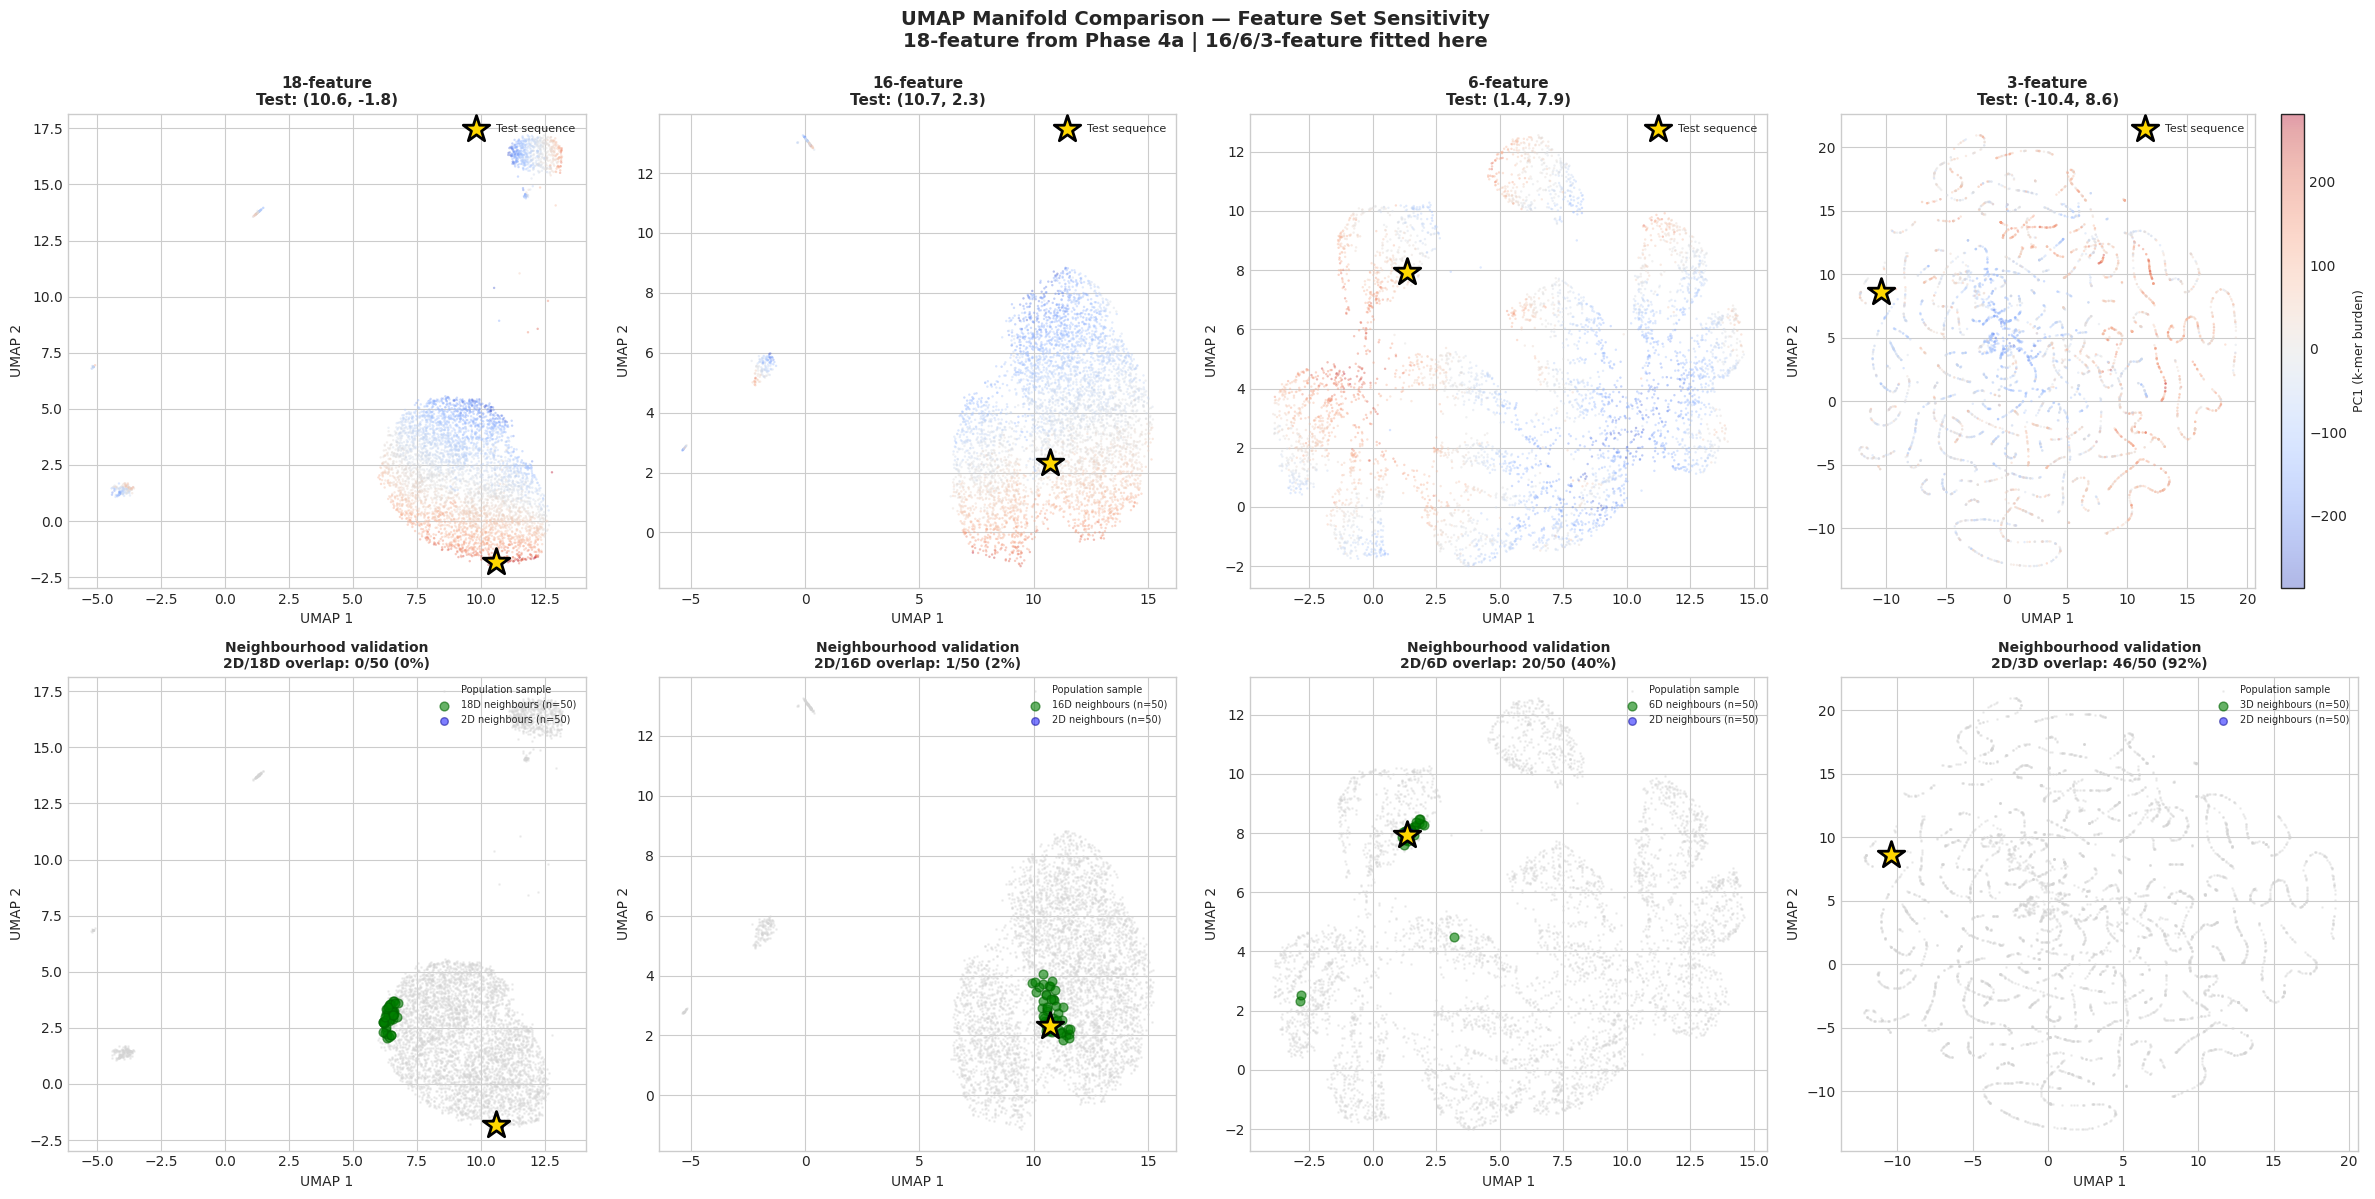


 UMAP comparison complete.
   New columns: UMAP1_16, UMAP2_16, UMAP1_6, UMAP2_6, UMAP1_3, UMAP2_3


In [62]:
# @title Phase 6b: UMAP Comparison of Reduced Models — 16, 6, and 3-Feature Manifolds
import umap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

print("=" * 70)
print("  UMAP MANIFOLD COMPARISON — REDUCED FEATURE SETS")
print("=" * 70)

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SUBSAMPLE_N = 20_000
K_NEIGHBORS = 50

# Stratified subsample
np.random.seed(42)
fitness_deciles = pd.qcut(
    df_clean['log2FC_mean'], q=10, labels=False, duplicates='drop'
)
pos_idx = []
for decile in range(10):
    decile_mask = (fitness_deciles == decile)
    decile_pool = df_clean[decile_mask].index.tolist()
    n_sample = min(SUBSAMPLE_N // 10, len(decile_pool))
    pos_idx.extend(np.random.choice(decile_pool, size=n_sample, replace=False))

# ── FIT UMAP FOR REDUCED FEATURE SETS (18-feature already exists) ────────────
feature_sets = {
    '16-feature': features_16,
    '6-feature':  features_6,
    '3-feature':  features_3,
}

umap_results = {}

for name, feat_list in feature_sets.items():
    print(f"\nFitting UMAP on {name} ({len(feat_list)} features)...")

    from sklearn.preprocessing import StandardScaler
    scaler_umap = StandardScaler()
    X_scaled = scaler_umap.fit_transform(df_clean[feat_list])

    reducer = umap.UMAP(
        n_neighbors=15, min_dist=0.1, n_components=2,
        metric='euclidean', random_state=42
    )
    reducer.fit(X_scaled[pos_idx])
    embedding = reducer.transform(X_scaled)

    df_clean[f'UMAP1_{len(feat_list)}'] = embedding[:, 0]
    df_clean[f'UMAP2_{len(feat_list)}'] = embedding[:, 1]

    # Project test sequence
    test_bio = calculate_master_features(test_seq)
    test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)
    test_scaled = scaler_umap.transform(test_bio_df[feat_list])
    test_coords = reducer.transform(test_scaled)[0]

    # Neighborhood analysis
    nn_2d = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_2d.fit(embedding)
    _, idx_2d = nn_2d.kneighbors([test_coords])

    nn_raw = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_raw.fit(X_scaled)
    _, idx_raw = nn_raw.kneighbors(test_scaled)

    overlap = len(set(idx_2d[0]) & set(idx_raw[0]))
    overlap_pct = overlap / K_NEIGHBORS * 100
    avg_pc1_raw = df_clean.iloc[idx_raw[0]]['PC1'].mean()

    umap_results[name] = {
        'embedding': embedding,
        'test_coords': test_coords,
        'overlap': overlap,
        'overlap_pct': overlap_pct,
        'avg_pc1_neighbors': avg_pc1_raw,
        'idx_2d': idx_2d[0],
        'idx_raw': idx_raw[0],
    }

    print(f"  Test coords: ({test_coords[0]:.2f}, {test_coords[1]:.2f})")
    print(f"  2D/{len(feat_list)}D overlap: {overlap}/{K_NEIGHBORS} ({overlap_pct:.0f}%)")

# Add 18-feature from existing Phase 4a UMAP
print("\nUsing existing 18-feature UMAP from Phase 4a...")
test_bio = calculate_master_features(test_seq)
test_bio_df = pd.DataFrame([test_bio], columns=mech_feature_labels)

# Recompute test coords using stored reducer/scaler from Phase 4a
if 'reducer' in globals() and 'scaler' in globals():
    test_scaled_18 = scaler.transform(test_bio_df[mech_feature_labels])
    test_coords_18 = reducer.transform(test_scaled_18)[0]

    X_mech_scaled_full = scaler.transform(df_clean[mech_feature_labels])

    nn_2d_18 = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_2d_18.fit(df_clean[['UMAP_1', 'UMAP_2']].values)
    _, idx_2d_18 = nn_2d_18.kneighbors([test_coords_18])

    nn_raw_18 = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
    nn_raw_18.fit(X_mech_scaled_full)
    _, idx_raw_18 = nn_raw_18.kneighbors(test_scaled_18)

    overlap_18 = len(set(idx_2d_18[0]) & set(idx_raw_18[0]))
    overlap_pct_18 = overlap_18 / K_NEIGHBORS * 100
    avg_pc1_raw_18 = df_clean.iloc[idx_raw_18[0]]['PC1'].mean()

    umap_results = {
        '18-feature': {
            'embedding': df_clean[['UMAP_1', 'UMAP_2']].values,
            'test_coords': test_coords_18,
            'overlap': overlap_18,
            'overlap_pct': overlap_pct_18,
            'avg_pc1_neighbors': avg_pc1_raw_18,
            'idx_2d': idx_2d_18[0],
            'idx_raw': idx_raw_18[0],
        },
        **umap_results
    }
    print(f"  Test coords: ({test_coords_18[0]:.2f}, {test_coords_18[1]:.2f})")
    print(f"  2D/18D overlap: {overlap_18}/{K_NEIGHBORS} ({overlap_pct_18:.0f}%)")

# ── VISUALIZATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
sns.set_style("white")

feature_counts = {'18-feature': 18, '16-feature': 16, '6-feature': 6, '3-feature': 3}

for col, (name, res) in enumerate(umap_results.items()):
    ax = axes[0, col]
    sample_idx = np.random.choice(len(df_clean), size=5000, replace=False)

    scatter = ax.scatter(
        res['embedding'][sample_idx, 0],
        res['embedding'][sample_idx, 1],
        c=df_clean.iloc[sample_idx]['PC1'],
        cmap='coolwarm', s=3, alpha=0.4, linewidths=0
    )

    ax.scatter(
        res['test_coords'][0], res['test_coords'][1],
        color='gold', s=400, marker='*', edgecolor='black',
        linewidth=2, zorder=10, label='Test sequence'
    )

    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    ax.set_title(
        f"{name}\nTest: ({res['test_coords'][0]:.1f}, {res['test_coords'][1]:.1f})",
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8)

    if col == 3:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('PC1 (k-mer burden)', fontsize=9)

    ax2 = axes[1, col]
    ax2.scatter(
        res['embedding'][sample_idx, 0],
        res['embedding'][sample_idx, 1],
        c='lightgray', s=1, alpha=0.3, label='Population sample'
    )

    ax2.scatter(
        res['embedding'][res['idx_raw'], 0],
        res['embedding'][res['idx_raw'], 1],
        c='green', s=40, alpha=0.6, edgecolor='darkgreen',
        label=f'{feature_counts[name]}D neighbours (n={K_NEIGHBORS})',
        zorder=6
    )

    ax2.scatter(
        res['embedding'][res['idx_2d'], 0],
        res['embedding'][res['idx_2d'], 1],
        c='blue', s=30, alpha=0.5, edgecolor='darkblue',
        label=f'2D neighbours (n={K_NEIGHBORS})', zorder=7
    )

    ax2.scatter(
        res['test_coords'][0], res['test_coords'][1],
        color='gold', s=400, marker='*', edgecolor='black',
        linewidth=2, zorder=10
    )

    ax2.set_xlabel('UMAP 1', fontsize=10)
    ax2.set_ylabel('UMAP 2', fontsize=10)
    ax2.set_title(
        f"Neighbourhood validation\n2D/{feature_counts[name]}D overlap: "
        f"{res['overlap']}/{K_NEIGHBORS} ({res['overlap_pct']:.0f}%)",
        fontsize=10, fontweight='bold'
    )
    ax2.legend(loc='upper right', fontsize=7)

plt.suptitle(
    'UMAP Manifold Comparison — Feature Set Sensitivity\n'
    '18-feature from Phase 4a | 16/6/3-feature fitted here',
    fontsize=14, fontweight='bold', y=0.995
)
plt.tight_layout()
plt.show()

print("\n UMAP comparison complete.")
print(f"   New columns: UMAP1_16, UMAP2_16, UMAP1_6, UMAP2_6, UMAP1_3, UMAP2_3")

In [66]:
#@title 6-feature blind fitness predication (PC1 PROXY)
# Features: GC%, Entropy, AT_tract, Max_Homo, RBS_Str, Promoter_Str

def predict_fitness_6(seq):
    # 1. Extract 18 features
    raw_features = calculate_master_features(seq)

    # 2. Map to names and filter for the "Elite 6"
    feat_dict = dict(zip(mech_feature_labels, raw_features))
    features_6 = ['GC_percent', 'Entropy', 'AT_tract', 'Max_Homo', 'RBS_Str', 'Promoter_Str']

    # 3. Z-Score Scaling (using the master population scaler)
    # We create a dummy 18-feature row to satisfy the scaler's shape
    full_row = np.array([raw_features])
    scaled_full = scaler.transform(full_row)[0]

    # 4. Extract SVD loadings for these specific features
    # Mech indices in PC1 components start after the k-mer indices
    kmer_offset = len(feature_names)
    mech_loadings = svd.components_[0, kmer_offset:]

    # 5. Calculate Weighted Contribution (Partial PC1)
    # Only sum the loadings for our 6 features
    score_6 = 0
    for feat in features_6:
        idx = mech_feature_labels.index(feat)
        score_6 += scaled_full[idx] * mech_loadings[idx]

    return score_6

# Execution
p_score_6 = predict_fitness_6(test_seq)
print(f"--- 6-FEATURE MODEL DIAGNOSTIC ---")
print(f"Sequence: {test_seq[:30]}...")
print(f"Predicted Fitness Heuristic (PC1_6): {p_score_6:.4f}")
print(f"Interpretation: {'High Burden / Low Fitness' if p_score_6 < -10 else 'Stable / High Fitness'}")

--- 6-FEATURE MODEL DIAGNOSTIC ---
Sequence: AAGCAAAATTGGGGGCGTGTGCTTATCTTG...
Predicted Fitness Heuristic (PC1_6): 0.4922
Interpretation: Stable / High Fitness


In [68]:
#@title 3-feature model blind fitness prediction (core instability trio)
# Features: Max_Homo, Entropy, AT_tract

def predict_fitness_3(seq):
    # 1. Extract 18 features
    raw_features = calculate_master_features(seq)

    # 2. Filter for the "Core Trio"
    features_3 = ['Max_Homo', 'Entropy', 'AT_tract']

    # 3. Z-Score Scaling
    scaled_full = scaler.transform(np.array([raw_features]))[0]

    # 4. SVD Loadings lookup
    kmer_offset = len(feature_names)
    mech_loadings = svd.components_[0, kmer_offset:]

    # 5. Partial PC1 Calculation
    score_3 = 0
    for feat in features_3:
        idx = mech_feature_labels.index(feat)
        score_3 += scaled_full[idx] * mech_loadings[idx]

    return score_3

# Execution
p_score_3 = predict_fitness_3(test_seq)
print(f"--- 3-FEATURE CORE TRIO DIAGNOSTIC ---")
print(f"Predicted Fitness Heuristic (PC1_3): {p_score_3:.4f}")
print(f"Topological Stability: { 'CRITICAL' if p_score_3 < -5 else 'RELIABLE'}")

--- 3-FEATURE CORE TRIO DIAGNOSTIC ---
Predicted Fitness Heuristic (PC1_3): 0.4802
Topological Stability: RELIABLE


In [70]:
#@title COMPARISON: PREDICTED HEURISTICS VS. EXPERIMENTAL GROUND TRUTH

# 1. First, ensure the 3-feature prediction is calculated (as requested)
def predict_fitness_3(seq):
    raw_features = calculate_master_features(seq)
    scaled_full = scaler.transform(np.array([raw_features]))[0]
    kmer_offset = len(feature_names)
    mech_loadings = svd.components_[0, kmer_offset:]

    features_3 = ['Max_Homo', 'Entropy', 'AT_tract']
    score_3 = 0
    for feat in features_3:
        idx = mech_feature_labels.index(feat)
        score_3 += scaled_full[idx] * mech_loadings[idx]
    return score_3

p_score_3 = predict_fitness_3(test_seq)

# 2. Check if the test sequence exists in the experimental database (df_clean)
match = df_clean[df_clean['sequence'] == test_seq]

print(f"--- VALIDATION MODULE ---")
if not match.empty:
    actual_fitness = match['log2FC_mean'].values[0]
    actual_pc1 = match['PC1'].values[0]

    print(f"Sequence Found in Database")
    print(f"Experimental log2FC:     {actual_fitness:.4f}")
    print(f"Full Model PC1 Score:    {actual_pc1:.4f}")
    print("-" * 30)
    print(f"6-Feature Prediction:    {p_score_6:.4f} (Error vs Full PC1: {abs(actual_pc1 - p_score_6):.4f})")
    print(f"3-Feature Prediction:    {p_score_3:.4f} (Error vs Full PC1: {abs(actual_pc1 - p_score_3):.4f})")

    # Simple Correlation Check
    direction = "Correct" if (actual_fitness < -0.5 and p_score_6 < 0) or (actual_fitness > -0.5 and p_score_6 > 0) else "Inverse"
    print(f"Trend Alignment:         {direction}")

else:
    print(f"🔍 Sequence NOT in Database")
    print(f"This is a 'Blind' prediction on a novel sequence.")
    print(f"6-Feature Heuristic:     {p_score_6:.4f}")
    print(f"3-Feature Heuristic:     {p_score_3:.4f}")
    print(f"Recommendation: Use these scores to estimate burden prior to wet-lab synthesis.")

--- VALIDATION MODULE ---
Sequence Found in Database
Experimental log2FC:     -0.3031
Full Model PC1 Score:    17.3027
------------------------------
6-Feature Prediction:    0.4922 (Error vs Full PC1: 16.8105)
3-Feature Prediction:    0.4802 (Error vs Full PC1: 16.8226)
Trend Alignment:         Correct


In [ ]:
#@title Phase 7: Master Biophysical Engine (22 FEATURES)

import numpy as np
import re
from collections import Counter

# Trinucleotide Bendability Parameters (Brukner et al.)
BEND_PARAMS = {
    'AAA': 0.0, 'AAC': 2.3, 'AAG': 2.3, 'AAT': 0.0, 'ACA': 4.6, 'ACC': 4.6,
    'ACG': 4.6, 'ACT': 4.6, 'AGA': 2.3, 'AGC': 4.6, 'AGG': 4.6, 'AGT': 2.3,
    'ATA': 0.0, 'ATC': 2.3, 'ATG': 2.3, 'ATT': 0.0, 'CAA': 2.3, 'CAC': 7.0,
    'CAG': 7.0, 'CAT': 2.3, 'CCA': 4.6, 'CCC': 4.6, 'CCG': 7.0, 'CCT': 4.6,
    'CGA': 4.6, 'CGC': 7.0, 'CGG': 7.0, 'CGT': 4.6, 'CTA': 2.3, 'CTC': 4.6,
    'CTG': 7.0, 'CTT': 2.3, 'GAA': 2.3, 'GAC': 7.0, 'GAG': 4.6, 'GAT': 2.3,
    'GCA': 4.6, 'GCC': 7.0, 'GCG': 7.0, 'GCT': 4.6, 'GGA': 4.6, 'GGC': 7.0,
    'GGG': 4.6, 'GGT': 4.6, 'GTA': 2.3, 'GTC': 4.6, 'GTG': 7.0, 'GTT': 2.3,
    'TAA': 0.0, 'TAC': 2.3, 'TAG': 2.3, 'TAT': 0.0, 'TCA': 4.6, 'TCC': 4.6,
    'TCG': 4.6, 'TCT': 2.3, 'TGA': 2.3, 'TGC': 4.6, 'TGG': 4.6, 'TGT': 2.3,
    'TTA': 0.0, 'TTC': 2.3, 'TTG': 2.3, 'TTT': 0.0
}

def calculate_master_features_v5_4(seq):
    seq = seq.upper()
    seq_len = len(seq)

    # --- [REUSE PREVIOUS 18 FEATURES LOGIC] ---
    # (Abbreviated here for logic flow - ensure calculate_master_features is in memory)
    base_18 = list(calculate_master_features(seq))

    # --- NEW TOPOLOGICAL EXPANSION ---
    # 1. Bendability (Topology)
    bend_scores = [BEND_PARAMS.get(seq[i:i+3], 3.5) for i in range(seq_len - 2)]
    avg_bendability = np.mean(bend_scores) if bend_scores else 3.5

    # 2. G4 Propensity (Physical Interactions)
    g4_count = len(re.findall(r'(?=(G{3,}[ATGC]{1,7}){3,}G{3,})', seq))

    # 3. GC Skew (R-Loop Risk)
    g_count, c_count = seq.count('G'), seq.count('C')
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0

    # 4. Initiation MFE Proxy (Secondary Structure)
    mfe_proxy = 0
    start_match = re.search('ATG', seq)
    if start_match:
        pos = start_match.start()
        init_win = seq[max(0, pos-20) : min(seq_len, pos+15)]
        mfe_proxy = (init_win.count('G') + init_win.count('C')) / len(init_win)

    return tuple(base_18 + [avg_bendability, g4_count, gc_skew, mfe_proxy])

# Update Labels
mech_feature_labels_v5_4 = mech_feature_labels + ['Bendability', 'G4_Count', 'GC_Skew', 'Initiation_MFE_Proxy']
print(f"✅ Engine upgraded to V5.4. Total features: {len(mech_feature_labels_v5_4)}")

In [ ]:
# Re-extract all features for the 124k dataset
print("Extracting 22-feature biophysical profiles...")
tqdm.pandas(desc="V5.4 Extraction")
results_v5_4 = df_clean['sequence'].progress_apply(calculate_master_features_v5_4)
df_v5_4 = pd.DataFrame(results_v5_4.tolist(), columns=mech_feature_labels_v5_4, index=df_clean.index)

# Merge back and Re-Scale
df_clean = pd.concat([df_clean.drop(columns=mech_feature_labels, errors='ignore'), df_v5_4], axis=1)
scaler_v5_4 = StandardScaler()
X_mech_scaled_v5_4 = scaler_v5_4.fit_transform(df_clean[mech_feature_labels_v5_4])

# Re-train SVD (The "Hardware" Update)
X_combined_v5_4 = hstack([X_sparse, csr_matrix(X_mech_scaled_v5_4 * scale_factor)])
svd_v5_4 = TruncatedSVD(n_components=2, random_state=42)
X_reduced_v5_4 = svd_v5_4.fit_transform(X_combined_v5_4)

df_clean['PC1_v5_4'] = X_reduced_v5_4[:, 0]
print("✅ Master SVD re-trained with topological features.")

In [63]:
# @title Troubleshooting/Recovery: SVD & Motifs Engine (only run if needed)
raise SystemExit ("Recovery cell skipped during run-all. Put # before SystemExit to run manually only when needed.")
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
import pandas as pd
import numpy as np

print("--- RECOVERING PCA/SVD SOFTWARE ENGINE (motifs_df) ---")

# 1. Define the 18 biophysical feature labels (must match Cell 5 exactly)
mech_feature_labels = [
    'Size', 'GC_percent', 'GC_Var', 'Max_Homo', 'Entropy',
    'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR',
    # New features (14–18)
    'HNS_Affinity', 'TTC', 'RCC', 'TIR_Proxy', 'mRNA_Stability'
]

# ── SAFETY CHECK ──────────────────────────────────────────────────────────────
if 'df_clean' not in globals():
    raise RuntimeError("❌ df_clean not found. Run Cell 1 (Data Ingestion) first.")

# Verify all 18 columns are present in df_clean (i.e. Cell 5 was run)
missing_cols = [f for f in mech_feature_labels if f not in df_clean.columns]
if missing_cols:
    raise RuntimeError(
        f"❌ Missing feature columns: {missing_cols}\n"
        "   Run Cell 5 (Feature Extraction) first to populate these columns."
    )

# 2. Scale the 18 biophysical features
scaler = StandardScaler()
X_mech_scaled = scaler.fit_transform(df_clean[mech_feature_labels])

# 3. Vectorise positional k-mers
def spatial_tokenizer(doc): return doc.split()
vectorizer = CountVectorizer(
    tokenizer=spatial_tokenizer, token_pattern=None, lowercase=False
)
X_sparse      = vectorizer.fit_transform(df_clean['kmers'])
feature_names = list(vectorizer.get_feature_names_out())

# 4. Fuse with reweighting (matches the main pipeline Cell 8)
print("Fusing matrices with scale-factor reweighting...")
scale_factor      = X_sparse.shape[1] / X_mech_scaled.shape[1]
X_mech_reweighted = X_mech_scaled * scale_factor
X_combined        = hstack([X_sparse, csr_matrix(X_mech_reweighted)])
print(f"  ↳ Scale factor: {scale_factor:.1f}x | Fused matrix: {X_combined.shape}")

# 5. Run TruncatedSVD
print("Running TruncatedSVD...")
svd       = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_combined)
df_clean['PC1'] = X_reduced[:, 0]
df_clean['PC2'] = X_reduced[:, 1]

# 6. Generate motifs_df
all_feature_names = feature_names + mech_feature_labels
motifs_df = (
    pd.DataFrame({
        'Motif'          : all_feature_names,
        'Importance'     : svd.components_[0],
        'Abs_Importance' : np.abs(svd.components_[0])
    })
    .sort_values(by='Abs_Importance', ascending=False)
    .reset_index(drop=True)
)

print(f"✅ Recovery complete. motifs_df contains {len(motifs_df):,} features.")
print(f"   PC1 range: {df_clean['PC1'].min():.2f} to {df_clean['PC1'].max():.2f}")

SystemExit: Recovery cell skipped during run-all. Put # before SystemExit to run manually only when needed.